### Imports

In [2]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.utils import k_fold_cross_validation
import ipywidgets as widgets
from IPython.display import display
import pandas as pd
import numpy as np
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sklearn.model_selection import train_test_split
from sksurv.metrics import concordance_index_censored
from sklearn.inspection import permutation_importance


### Read data and pre processing

In [3]:
#Saber quantos pacientes vem dos dados do RHC e FOSP (o rhc tem muitos pacientes a mais?) -- fosp sao dados até 2020
#Filtrar os pacientes até 31/01/2020

# Read the CSV file with Latin-1 encoding and semicolon delimiter
print("\nReading RHC database...")
df_rhc = pd.read_csv('bancorhc.csv', encoding='latin1', sep=';')

# Read the Excel file
print("\nReading FOSP database...")
df_fosp = pd.read_excel('UNIFICADO ATUALIZADA.xlsx', sheet_name='TUMORES GLÓTICOS')
print(len(df_fosp))

# Display information about RHC dataset
print("\n=== RHC Dataset Information ===")
print("\nShape:", df_rhc.shape)
print("\nFirst 5 rows:")
print(df_rhc.head())

# Display information about FOSP dataset
print("\n\n=== FOSP Dataset Information ===")
print("\nShape:", df_fosp.shape)
print("\nFirst 5 rows:")
print(df_fosp.head())

#FOSP PRE PROCESSING
print("Quantidade de pacientes antes de filtrar o AC Camargo: ", len(df_fosp))
fosp_count_before = len(df_fosp)
df_fosp = df_fosp[df_fosp["DSCINST"] != "HOSP AC CAMARGO"]
print("Quantidade de pacientes depois de filtrar o AC Camargo: ", len(df_fosp))
fosp_count_after = len(df_fosp)
print("Quantidade de pacientes filtrados: ", fosp_count_before - fosp_count_after)

#RHC PRE PROCESSING
df_rhc = df_rhc[df_rhc["TOPOGRUP"] == "C32"]
df_rhc = df_rhc[df_rhc["DESCTOPO"] == "GLOTE"]
df_rhc["DSCINST"] = "HOSP AC CAMARGO"
df_rhc["DTDIAG"] = pd.to_datetime(df_rhc["DTDIAG"], format="%d/%m/%Y", errors='coerce')
df_rhc["DTTRAT"] = pd.to_datetime(df_rhc["DTTRAT"], format="%d/%m/%Y", errors='coerce')
df_rhc["DTCONSULT"] = pd.to_datetime(df_rhc["DTCONSULT"], format="%d/%m/%Y", errors='coerce')

df_rhc["TRATCONS"] = (df_rhc['DTTRAT'] - df_rhc['DTDIAG']).dt.days
df_rhc["DIAGTRAT"] = (df_rhc['DTTRAT'] - df_rhc['DTCONSULT']).dt.days

df_rhc["DTULTINFO"] = pd.to_datetime(df_rhc["DTULTINFO"], format="%d/%m/%Y", errors='coerce')
df_rhc = df_rhc[df_rhc["DTDIAG"] < "30/12/2020"]

print("Quantidade de adicionados pelo RHC: ", len(df_rhc) - (fosp_count_before - fosp_count_after))

df_all = pd.concat([df_fosp, df_rhc], ignore_index=True)

df_all = df_all.dropna(subset=["TRATCONS"])

print("Quantidade de pacientes do ACCamargo: ", len(df_all[df_all["DSCINST"] == "HOSP AC CAMARGO"]), "e do FOSP: ", len(df_fosp[df_fosp["DSCINST"] == "HOSP AC CAMARGO"].dropna(subset=["TRATCONS"])))
#468-559= -91



Reading RHC database...


/var/folders/gj/141f8bwn4_g7gbh7d6jngwnm0000gn/T/ipykernel_72018/2060362629.py:6: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rhc = pd.read_csv('bancorhc.csv', encoding='latin1', sep=';')



Reading FOSP database...
4212

=== RHC Dataset Information ===

Shape: (160671, 87)

First 5 rows:
            RHC  PRONTUAR  ESCOLARI  TIPODOC       NUMDOC      DTNASC  IDADE  \
0  00/000001-01      60.0         5        4  87297027804  05/03/1956     43   
1  18/000001-02      60.0         5        4  87297027804  05/03/1956     62   
2  00/000002-01     299.0         2        4  13133577824  22/02/1935     64   
3  00/000003-01     310.0         2        2      4916368  06/03/1966     33   
4  00/000004-01     353.0         4        2      5220171  08/05/1939     60   

   SEXO UFNASC UFRESID  ...  RECNENHUM RECLOCAL  RECREGIO RECDIST  REC01  \
0     2     SP      SP  ...          1        0         0       0    NaN   
1     2     SP      SP  ...          1        0         0       0    NaN   
2     2     SP      SP  ...          1        0         0       0    C22   
3     2     BA      SP  ...          1        0         0       0    NaN   
4     1     MG      SP  ...          1 

In [4]:
tratamentos = ["RADIO", "QUIMIO"]
outros = ["CIRURGIA", "HORMONIO", "TMO", "IMUNO", "OUTROS"] #Porque segue o nccn

# Create new column for RHC database
df_all['OUTROS_TRATAMENTOS'] = df_all[outros].any(axis=1).astype(int)

df_all["ULTINFO_TREAT"] = (df_all["ULTINFO"] == 3).astype(int)

df_all["FOLLOW_DAYS"] = (df_all['DTULTINFO'] - df_all['DTDIAG']).dt.days

#convert tratcons to int
df_all["TRATCONS"] = df_all["TRATCONS"].astype(int)

df_all["DIAGPREV"] = df_all["DIAGPREV"].astype(int)

df_all = df_all[df_all["FOLLOW_DAYS"] >= 0]

### Kaplan Meier de todos os casos no ACCamargo comparado com todos os outros hospitais

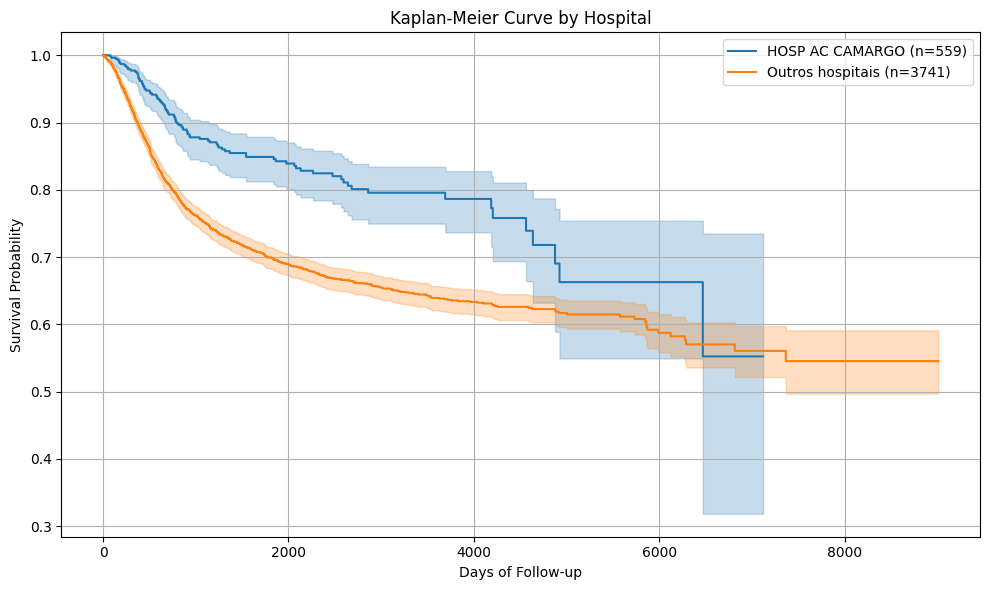

In [8]:
group1 = df_all[df_all["DSCINST"] == "HOSP AC CAMARGO"]
group2 = df_all[df_all["DSCINST"] != "HOSP AC CAMARGO"]

# Counts
n_group1 = len(group1)
n_group2 = len(group2)

# Kaplan-Meier fitter
kmf = KaplanMeierFitter()

# Plot
plt.figure(figsize=(10, 6))

# Group 1
label1 = f"HOSP AC CAMARGO (n={n_group1})"
kmf.fit(group1["FOLLOW_DAYS"], event_observed=group1["ULTINFO_TREAT"], label=label1)
kmf.plot(ci_show=True)

# Group 2
label2 = f"Outros hospitais (n={n_group2})"
kmf.fit(group2["FOLLOW_DAYS"], event_observed=group2["ULTINFO_TREAT"], label=label2)
kmf.plot(ci_show=True)

# Plot settings
plt.title("Kaplan-Meier Curve by Hospital")
plt.xlabel("Days of Follow-up")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### Kaplan Meier de todos os casos no ACCamargo comparado com todos os outros hospitais em estadiamento 1

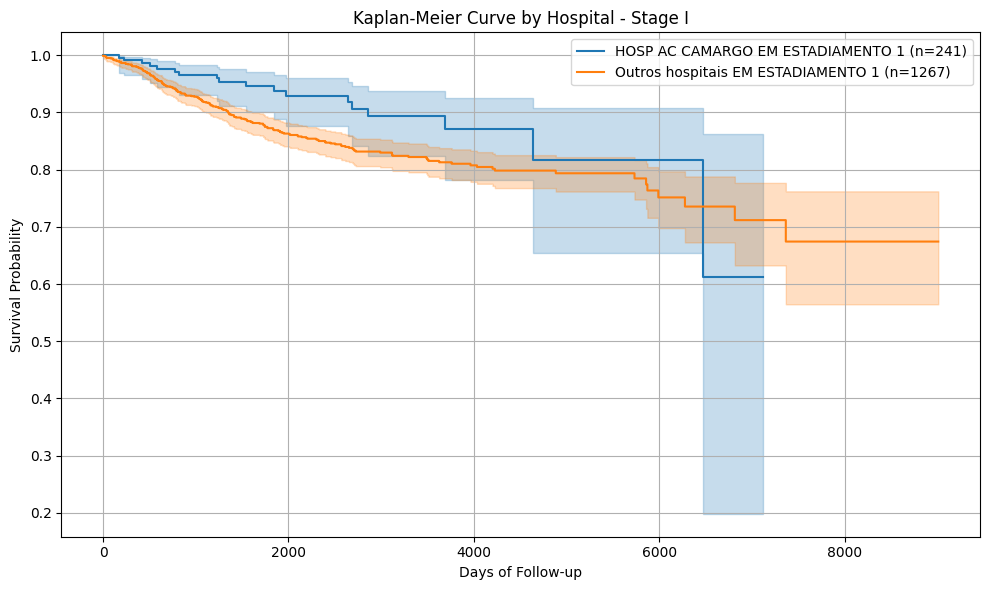

In [9]:
group1 = df_all[(df_all["DSCINST"] == "HOSP AC CAMARGO") & (df_all["ECGRUP"] == "I")]
group2 = df_all[(df_all["DSCINST"] != "HOSP AC CAMARGO") & (df_all["ECGRUP"] == "I")]

# Counts
n_group1 = len(group1)
n_group2 = len(group2)

# Kaplan-Meier fitter
kmf = KaplanMeierFitter()

# Plot
plt.figure(figsize=(10, 6))

# Group 1
label1 = f"HOSP AC CAMARGO EM ESTADIAMENTO 1 (n={n_group1})"
kmf.fit(group1["FOLLOW_DAYS"], event_observed=group1["ULTINFO_TREAT"], label=label1)
kmf.plot(ci_show=True)

# Group 2
label2 = f"Outros hospitais EM ESTADIAMENTO 1 (n={n_group2})"
kmf.fit(group2["FOLLOW_DAYS"], event_observed=group2["ULTINFO_TREAT"], label=label2)
kmf.plot(ci_show=True)

# Plot settings
plt.title("Kaplan-Meier Curve by Hospital - Stage I")
plt.xlabel("Days of Follow-up")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



### Analysis: DIAGTRAT comparison by treatment groups


In [12]:
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu
import seaborn as sns

# Prepare data for DIAGTRAT analysis
# DIAGTRAT is only available for RHC data (HOSP AC CAMARGO)
df_diagtrat_analysis = df_all[df_all["DSCINST"] == "HOSP AC CAMARGO"].copy()

# Ensure DIAGTRAT is numeric
df_diagtrat_analysis["DIAGTRAT"] = pd.to_numeric(df_diagtrat_analysis["DIAGTRAT"], errors='coerce')

# Remove missing DIAGTRAT values
df_diagtrat_analysis = df_diagtrat_analysis.dropna(subset=["DIAGTRAT"])

# Remove negative or zero DIAGTRAT (data quality issues)
df_diagtrat_analysis = df_diagtrat_analysis[df_diagtrat_analysis["DIAGTRAT"] > 0]

print("=== DIAGTRAT Analysis by Treatment Groups ===\n")
print(f"Total patients with DIAGTRAT data: {len(df_diagtrat_analysis)}")
print(f"DIAGTRAT range: {df_diagtrat_analysis['DIAGTRAT'].min():.0f} to {df_diagtrat_analysis['DIAGTRAT'].max():.0f} days")
print(f"DIAGTRAT median: {df_diagtrat_analysis['DIAGTRAT'].median():.0f} days")
print(f"DIAGTRAT mean: {df_diagtrat_analysis['DIAGTRAT'].mean():.1f} days\n")

# Create treatment groups
# Only RADIO and CIRURGIA are separate groups; QUIMIO goes to "Other"
df_diagtrat_analysis["TREATMENT_GROUP"] = "Other"
df_diagtrat_analysis.loc[df_diagtrat_analysis["RADIO"] == 1, "TREATMENT_GROUP"] = "RADIO"
df_diagtrat_analysis.loc[df_diagtrat_analysis["CIRURGIA"] == 1, "TREATMENT_GROUP"] = "CIRURGIA"
# Note: QUIMIO and other treatments remain in "Other" group

# Create flags for combination analysis
df_diagtrat_analysis["HAS_RADIO"] = (df_diagtrat_analysis["RADIO"] == 1).astype(int)
df_diagtrat_analysis["HAS_CIRURGIA"] = (df_diagtrat_analysis["CIRURGIA"] == 1).astype(int)

# Create combination groups
df_diagtrat_analysis["TREATMENT_COMBO"] = df_diagtrat_analysis.apply(
    lambda x: f"R:{x['HAS_RADIO']}_C:{x['HAS_CIRURGIA']}", axis=1
)

# Summary statistics by treatment group
print("=== Summary Statistics by Treatment Group ===\n")
treatment_stats = df_diagtrat_analysis.groupby("TREATMENT_GROUP")["DIAGTRAT"].agg([
    ('count', 'count'),
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std'),
    ('min', 'min'),
    ('max', 'max')
]).round(1)

print(treatment_stats)
print()

# Statistical tests
print("=== Statistical Tests ===\n")

# Get data for each group
groups_data = {}
for group in df_diagtrat_analysis["TREATMENT_GROUP"].unique():
    groups_data[group] = df_diagtrat_analysis[df_diagtrat_analysis["TREATMENT_GROUP"] == group]["DIAGTRAT"].values

# Kruskal-Wallis test (non-parametric ANOVA for multiple groups)
if len(groups_data) > 2:
    groups_list = [groups_data[g] for g in groups_data.keys() if len(groups_data[g]) > 0]
    if len(groups_list) > 2:
        h_stat, p_value = kruskal(*groups_list)
        print(f"Kruskal-Wallis test (all groups):")
        print(f"  H-statistic: {h_stat:.4f}")
        print(f"  p-value: {p_value:.4f}")
        print(f"  Significant difference: {'Yes' if p_value < 0.05 else 'No'}\n")

# Pairwise comparisons (Mann-Whitney U test)
print("Pairwise comparisons (Mann-Whitney U test):")
group_names = sorted([g for g in groups_data.keys() if len(groups_data[g]) > 0])
for i in range(len(group_names)):
    for j in range(i+1, len(group_names)):
        group1_name = group_names[i]
        group2_name = group_names[j]
        group1_data = groups_data[group1_name]
        group2_data = groups_data[group2_name]
        
        if len(group1_data) > 0 and len(group2_data) > 0:
            
            u_stat, p_val = mannwhitneyu(group1_data, group2_data, alternative='two-sided')
            mean_diff = np.mean(group1_data) - np.mean(group2_data)
            print(f"  {group1_name} vs {group2_name}:")
            print(f"    Mean difference: {mean_diff:.1f} days ({group1_name} - {group2_name})")
            print(f"    p-value: {p_val:.4f}")
            print(f"    Significant: {'Yes' if p_val < 0.05 else 'No'}")

print("\n" + "="*60 + "\n")


=== DIAGTRAT Analysis by Treatment Groups ===

Total patients with DIAGTRAT data: 558
DIAGTRAT range: 1 to 3261 days
DIAGTRAT median: 39 days
DIAGTRAT mean: 78.2 days

=== Summary Statistics by Treatment Group ===

                 count  mean  median    std  min     max
TREATMENT_GROUP                                         
CIRURGIA           259  88.7    34.0  264.0  1.0  3261.0
Other               20  55.6    47.0   37.4  8.0   146.0
RADIO              279  70.2    43.0  148.5  1.0  1701.0

=== Statistical Tests ===

Kruskal-Wallis test (all groups):
  H-statistic: 7.4686
  p-value: 0.0239
  Significant difference: Yes

Pairwise comparisons (Mann-Whitney U test):
  CIRURGIA vs Other:
    Mean difference: 33.0 days (CIRURGIA - Other)
    p-value: 0.1608
    Significant: No
  CIRURGIA vs RADIO:
    Mean difference: 18.5 days (CIRURGIA - RADIO)
    p-value: 0.0107
    Significant: Yes
  Other vs RADIO:
    Mean difference: -14.5 days (Other - RADIO)
    p-value: 0.5389
    Significan

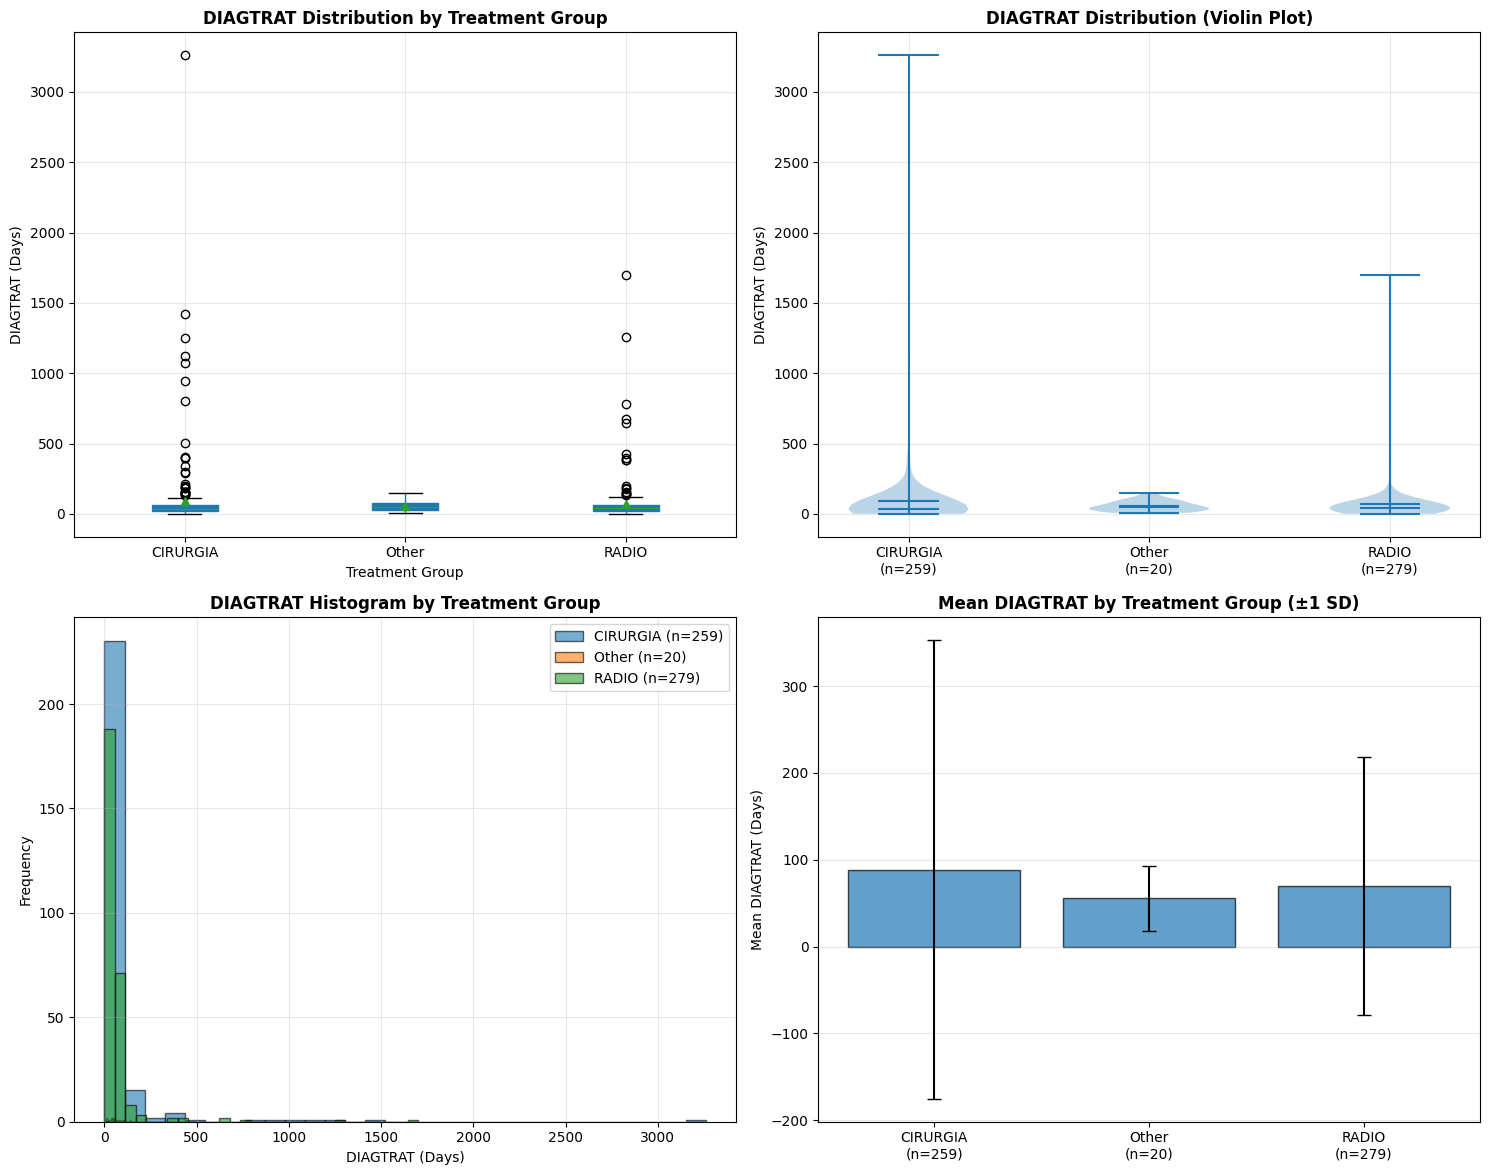


=== Visualization Summary ===
Top plot: Box plots show median, quartiles, and outliers
Second plot: Violin plots show distribution shape
Third plot: Histograms show frequency distribution
Bottom plot: Bar chart with error bars (mean ± 1 SD)


In [13]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Box plot by treatment group
ax1 = axes[0, 0]
treatment_order = sorted(df_diagtrat_analysis["TREATMENT_GROUP"].unique())
df_diagtrat_analysis.boxplot(column="DIAGTRAT", by="TREATMENT_GROUP", ax=ax1, 
                             patch_artist=True, showmeans=True)
ax1.set_title("DIAGTRAT Distribution by Treatment Group", fontsize=12, fontweight='bold')
ax1.set_xlabel("Treatment Group")
ax1.set_ylabel("DIAGTRAT (Days)")
ax1.grid(True, alpha=0.3)
plt.suptitle('')  # Remove default title

# 2. Violin plot
ax2 = axes[0, 1]
treatment_data_list = []
treatment_labels = []
for group in treatment_order:
    data = df_diagtrat_analysis[df_diagtrat_analysis["TREATMENT_GROUP"] == group]["DIAGTRAT"]
    if len(data) > 0:
        treatment_data_list.append(data.values)
        treatment_labels.append(f"{group}\n(n={len(data)})")

if treatment_data_list:
    parts = ax2.violinplot(treatment_data_list, positions=range(len(treatment_data_list)), 
                           showmeans=True, showmedians=True)
    ax2.set_xticks(range(len(treatment_labels)))
    ax2.set_xticklabels(treatment_labels)
    ax2.set_title("DIAGTRAT Distribution (Violin Plot)", fontsize=12, fontweight='bold')
    ax2.set_ylabel("DIAGTRAT (Days)")
    ax2.grid(True, alpha=0.3)

# 3. Histogram by treatment group
ax3 = axes[1, 0]
for group in treatment_order:
    data = df_diagtrat_analysis[df_diagtrat_analysis["TREATMENT_GROUP"] == group]["DIAGTRAT"]
    if len(data) > 0:
        ax3.hist(data, alpha=0.6, label=f"{group} (n={len(data)})", bins=30, edgecolor='black')
ax3.set_title("DIAGTRAT Histogram by Treatment Group", fontsize=12, fontweight='bold')
ax3.set_xlabel("DIAGTRAT (Days)")
ax3.set_ylabel("Frequency")
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Mean DIAGTRAT with confidence intervals
ax4 = axes[1, 1]
group_means = []
group_stds = []
group_counts = []
group_names_plot = []
for group in treatment_order:
    data = df_diagtrat_analysis[df_diagtrat_analysis["TREATMENT_GROUP"] == group]["DIAGTRAT"]
    if len(data) > 0:
        group_means.append(data.mean())
        group_stds.append(data.std())
        group_counts.append(len(data))
        group_names_plot.append(f"{group}\n(n={len(data)})")

if group_means:
    x_pos = range(len(group_names_plot))
    ax4.bar(x_pos, group_means, yerr=group_stds, capsize=5, alpha=0.7, edgecolor='black')
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(group_names_plot)
    ax4.set_title("Mean DIAGTRAT by Treatment Group (±1 SD)", fontsize=12, fontweight='bold')
    ax4.set_ylabel("Mean DIAGTRAT (Days)")
    ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n=== Visualization Summary ===")
print("Top plot: Box plots show median, quartiles, and outliers")
print("Second plot: Violin plots show distribution shape")
print("Third plot: Histograms show frequency distribution")
print("Bottom plot: Bar chart with error bars (mean ± 1 SD)")


In [14]:
# Additional analysis: DIAGTRAT by treatment combinations
print("=== DIAGTRAT Analysis by Treatment Combinations ===\n")

# Count combinations
combo_counts = df_diagtrat_analysis["TREATMENT_COMBO"].value_counts()
print("Treatment combinations (R=Radio, C=Cirurgia, Q=Quimio):")
for combo, count in combo_counts.head(10).items():
    mean_diagtrat = df_diagtrat_analysis[df_diagtrat_analysis["TREATMENT_COMBO"] == combo]["DIAGTRAT"].mean()
    print(f"  {combo}: {count} patients, mean DIAGTRAT: {mean_diagtrat:.1f} days")

# Focus on main single treatments vs combinations
print("\n=== Main Treatment Groups (with sufficient sample size) ===\n")
main_groups = df_diagtrat_analysis["TREATMENT_GROUP"].value_counts()
for group, count in main_groups.items():
    if count >= 10:  # Only show groups with at least 10 patients
        group_data = df_diagtrat_analysis[df_diagtrat_analysis["TREATMENT_GROUP"] == group]["DIAGTRAT"]
        print(f"{group} (n={count}):")
        print(f"  Mean: {group_data.mean():.1f} days")
        print(f"  Median: {group_data.median():.1f} days")
        print(f"  IQR: {group_data.quantile(0.25):.1f} - {group_data.quantile(0.75):.1f} days")
        print(f"  Range: {group_data.min():.0f} - {group_data.max():.0f} days")
        print()


=== DIAGTRAT Analysis by Treatment Combinations ===

Treatment combinations (R=Radio, C=Cirurgia, Q=Quimio):
  R:1_C:0: 279 patients, mean DIAGTRAT: 70.2 days
  R:0_C:1: 161 patients, mean DIAGTRAT: 98.4 days
  R:1_C:1: 98 patients, mean DIAGTRAT: 72.7 days
  R:0_C:0: 20 patients, mean DIAGTRAT: 55.6 days

=== Main Treatment Groups (with sufficient sample size) ===

RADIO (n=279):
  Mean: 70.2 days
  Median: 43.0 days
  IQR: 23.0 - 65.5 days
  Range: 1 - 1701 days

CIRURGIA (n=259):
  Mean: 88.7 days
  Median: 34.0 days
  IQR: 18.0 - 60.0 days
  Range: 1 - 3261 days

Other (n=20):
  Mean: 55.6 days
  Median: 47.0 days
  IQR: 27.5 - 78.5 days
  Range: 8 - 146 days



### Kaplan-Meier Survival Analysis by Treatment Groups


=== Kaplan-Meier Survival Analysis by Treatment Groups ===

Total patients: 1267

Patients by treatment group:
  CIRURGIA: 734 patients (115 events)
  Other: 64 patients (9 events)
  RADIO: 469 patients (68 events)


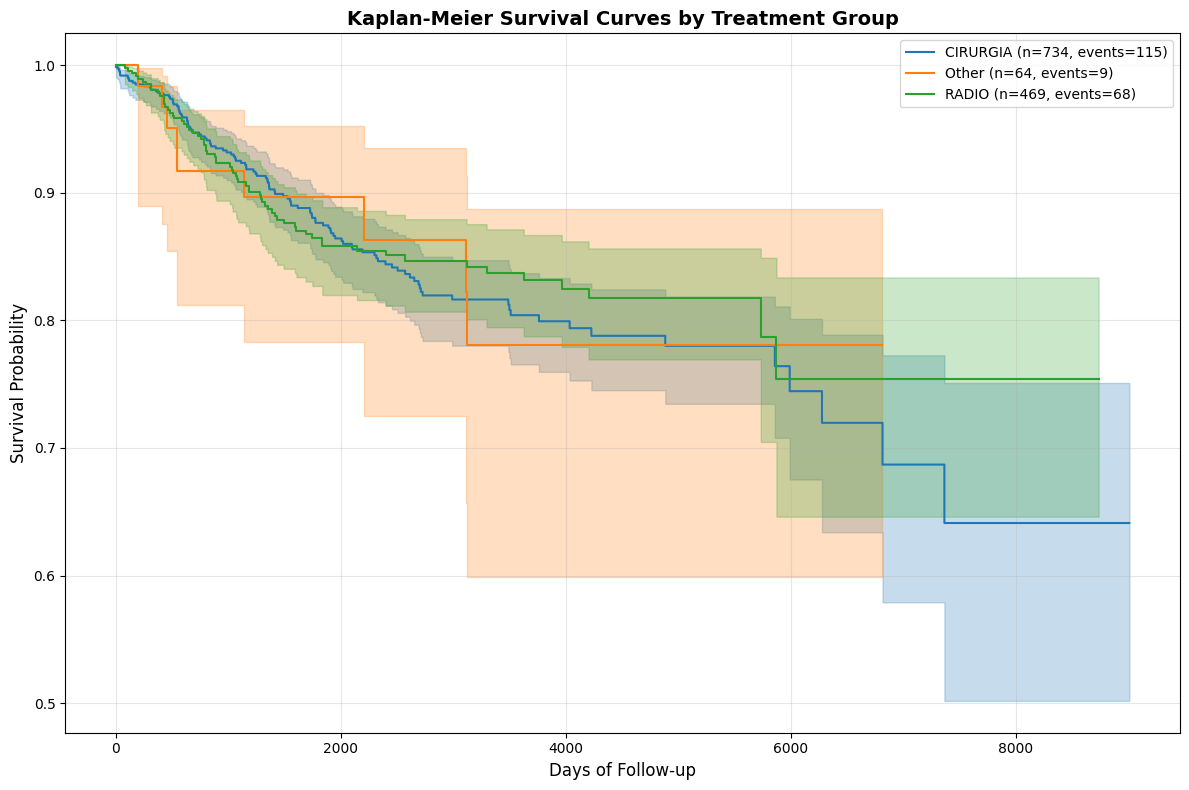

In [48]:
# Create treatment groups in main dataframe for survival analysis
# Only RADIO and CIRURGIA are separate groups; QUIMIO goes to "Other"
df_survival = df_all.copy()
df_survival = df_survival[df_survival['ECGRUP'].isin(['I'])]
df_survival = df_survival[df_survival['DSCINST'] != 'HOSP AC CAMARGO']
df_survival["TREATMENT_GROUP"] = "Other"
df_survival.loc[df_survival["RADIO"] == 1, "TREATMENT_GROUP"] = "RADIO"
df_survival.loc[df_survival["CIRURGIA"] == 1, "TREATMENT_GROUP"] = "CIRURGIA"
# Note: QUIMIO and other treatments remain in "Other" group

# Filter to patients with valid survival data
df_survival = df_survival.dropna(subset=["FOLLOW_DAYS", "ULTINFO_TREAT"])
df_survival = df_survival[df_survival["FOLLOW_DAYS"] >= 0]

# Get treatment groups
treatment_groups = sorted(df_survival["TREATMENT_GROUP"].unique())

print("=== Kaplan-Meier Survival Analysis by Treatment Groups ===\n")
print(f"Total patients: {len(df_survival)}")
print("\nPatients by treatment group:")
for group in treatment_groups:
    n = len(df_survival[df_survival["TREATMENT_GROUP"] == group])
    events = df_survival[df_survival["TREATMENT_GROUP"] == group]["ULTINFO_TREAT"].sum()
    print(f"  {group}: {n} patients ({events} events)")

# Create Kaplan-Meier plot
kmf = KaplanMeierFitter()

plt.figure(figsize=(12, 8))

# Plot survival curves for each treatment group
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i, group in enumerate(treatment_groups):
    group_data = df_survival[df_survival["TREATMENT_GROUP"] == group]
    n = len(group_data)
    events = group_data["ULTINFO_TREAT"].sum()
    
    if n > 0:
        kmf.fit(
            group_data["FOLLOW_DAYS"], 
            event_observed=group_data["ULTINFO_TREAT"], 
            label=f"{group} (n={n}, events={events})"
        )
        kmf.plot(ci_show=True, color=colors[i % len(colors)])

plt.title("Kaplan-Meier Survival Curves by Treatment Group", fontsize=14, fontweight='bold')
plt.xlabel("Days of Follow-up", fontsize=12)
plt.ylabel("Survival Probability", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

print("\n" + "="*60 + "\n")


In [49]:
# Statistical comparison between treatment groups using log-rank test
from lifelines.statistics import logrank_test, multivariate_logrank_test

print("=== Statistical Tests for Survival Differences ===\n")

# Pairwise log-rank tests
group_names = sorted([g for g in treatment_groups if len(df_survival[df_survival["TREATMENT_GROUP"] == g]) > 0])

print("Pairwise Log-Rank Tests:")
for i in range(len(group_names)):
    for j in range(i+1, len(group_names)):
        group1_name = group_names[i]
        group2_name = group_names[j]
        
        group1_data = df_survival[df_survival["TREATMENT_GROUP"] == group1_name]
        group2_data = df_survival[df_survival["TREATMENT_GROUP"] == group2_name]
        
        if len(group1_data) > 0 and len(group2_data) > 0:
            results = logrank_test(
                group1_data["FOLLOW_DAYS"],
                group2_data["FOLLOW_DAYS"],
                event_observed_A=group1_data["ULTINFO_TREAT"],
                event_observed_B=group2_data["ULTINFO_TREAT"]
            )
            
            print(f"\n  {group1_name} vs {group2_name}:")
            print(f"    Test statistic: {results.test_statistic:.4f}")
            print(f"    p-value: {results.p_value:.4f}")
            print(f"    Significant difference: {'Yes' if results.p_value < 0.05 else 'No'}")

# Overall multivariate log-rank test
if len(group_names) > 2:
    print(f"\n=== Overall Multivariate Log-Rank Test (all {len(group_names)} groups) ===")
    groups_data = []
    events_data = []
    times_data = []
    
    for group in group_names:
        group_data = df_survival[df_survival["TREATMENT_GROUP"] == group]
        if len(group_data) > 0:
            times_data.append(group_data["FOLLOW_DAYS"].values)
            events_data.append(group_data["ULTINFO_TREAT"].values)
    
    if len(times_data) > 2:
        results_multi = multivariate_logrank_test(
            df_survival["FOLLOW_DAYS"],
            df_survival["TREATMENT_GROUP"],
            df_survival["ULTINFO_TREAT"]
        )
        print(f"  Test statistic: {results_multi.test_statistic:.4f}")
        print(f"  p-value: {results_multi.p_value:.4f}")
        print(f"  Significant difference: {'Yes' if results_multi.p_value < 0.05 else 'No'}")

print("\n" + "="*60 + "\n")


=== Statistical Tests for Survival Differences ===

Pairwise Log-Rank Tests:

  CIRURGIA vs Other:
    Test statistic: 0.0020
    p-value: 0.9640
    Significant difference: No

  CIRURGIA vs RADIO:
    Test statistic: 0.3087
    p-value: 0.5785
    Significant difference: No

  Other vs RADIO:
    Test statistic: 0.0480
    p-value: 0.8265
    Significant difference: No

=== Overall Multivariate Log-Rank Test (all 3 groups) ===
  Test statistic: 0.3295
  p-value: 0.8481
  Significant difference: No




In [50]:
# Summary statistics: Median survival times and survival rates at specific time points
print("=== Survival Summary Statistics by Treatment Group ===\n")

time_points = [365, 730, 1095, 1825]  # 1, 2, 3, and 5 years in days
time_labels = ["1 year", "2 years", "3 years", "5 years"]

kmf = KaplanMeierFitter()

summary_data = []
for group in treatment_groups:
    group_data = df_survival[df_survival["TREATMENT_GROUP"] == group]
    
    if len(group_data) > 0:
        kmf.fit(
            group_data["FOLLOW_DAYS"], 
            event_observed=group_data["ULTINFO_TREAT"]
        )
        
        # Median survival time
        try:
            median_survival = kmf.median_survival_time_
        except:
            median_survival = None
        
        # Survival rates at specific time points
        survival_rates = []
        for time_point in time_points:
            try:
                rate = kmf.predict(time_point)
                survival_rates.append(rate)
            except:
                survival_rates.append(None)
        
        summary_data.append({
            'Treatment': group,
            'N': len(group_data),
            'Events': group_data["ULTINFO_TREAT"].sum(),
            'Median Survival (days)': f"{median_survival:.0f}" if median_survival is not None else "Not reached",
            **{f"Survival at {label}": f"{rate:.3f}" if rate is not None else "N/A" 
               for label, rate in zip(time_labels, survival_rates)}
        })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print()


=== Survival Summary Statistics by Treatment Group ===

Treatment   N  Events Median Survival (days) Survival at 1 year Survival at 2 years Survival at 3 years Survival at 5 years
 CIRURGIA 734     115                    inf              0.979               0.947               0.925               0.876
    Other  64       9                    inf              0.984               0.917               0.917               0.896
    RADIO 469      68                    inf              0.980               0.944               0.908               0.864



### Cox Regression Analysis: DIAGTRAT effect on survival by treatment group


In [58]:
# Prepare data for Cox analysis with DIAGTRAT
# DIAGTRAT is only available for RHC data (HOSP AC CAMARGO)



variables = ["IDADE", "SEXO", "CIRURGIA", "RADIO", "OUTROS_TRATAMENTOS", "RECNENHUM", "TRATCONS", "DIAGTRAT"]
others_treatments = ["QUIMIO", "HORMONIO", "TMO", "IMUNO", "OUTROS"]
attend_categories = ["SUS", "PARTICULAR"]
diag_prev_categories = []

df_model_dummy = df_all.copy()

# Create other treatments variable
df_model_dummy["OUTROS_TRATAMENTOS"] = df_model_dummy[others_treatments].any(axis=1).astype(int)

df_model_dummy = df_model_dummy[df_model_dummy['ECGRUP'].isin(['I'])]
df_model_dummy = df_model_dummy[df_model_dummy['DSCINST'] == "HOSP AC CAMARGO"]
#df_model_dummy = df_model_dummy[df_model_dummy['DIAGTRAT'] > 30]


df_model_dummy["DIAGPREV_EXAME"] = df_model_dummy["DIAGPREV"].map(lambda x: 1 if x == 1 else 0)
df_model_dummy["DIAGPREV_RECURSOS"] = df_model_dummy["DIAGPREV"].map(lambda x: 1 if x == 2 else 0)
df_model_dummy["DIAGPREV_CONFIRMACAO"] = df_model_dummy["DIAGPREV"].map(lambda x: 1 if x == 3 else 0)
df_model_dummy["DIAGPREV_SEM_INF"] = df_model_dummy["DIAGPREV"].map(lambda x: 1 if x == 4 else 0)

# Map the attend_categories to the values in the dataframe
df_model_dummy["CONVENIO"] = df_model_dummy["CATEATEND"].map(lambda x: 1 if x == 1 else 0)
df_model_dummy["SUS"] = df_model_dummy["CATEATEND"].map(lambda x: 1 if x == 2 else 0)
df_model_dummy["PARTICULAR"] = df_model_dummy["CATEATEND"].map(lambda x: 1 if x == 3 else 0)
df_model_dummy["SEM_INF"] = df_model_dummy["CATEATEND"].map(lambda x: 1 if x == 9 else 0)

all_variables_dummy = variables + attend_categories + diag_prev_categories

# ============================================================================
# HANDLE IMMORTAL TIME BIAS FOR DIAGTRAT
# DIAGTRAT = days from consultation to treatment
# Immortal time bias: Patients with longer DIAGTRAT have a period where they cannot die
# Solution: Create adjusted follow-up time that excludes the immortal period
# ============================================================================

# Ensure DIAGTRAT is numeric
df_model_dummy["DIAGTRAT"] = pd.to_numeric(df_model_dummy["DIAGTRAT"], errors='coerce')

# Create adjusted follow-up time: subtract DIAGTRAT (immortal time) from FOLLOW_DAYS
# This accounts for the fact that patients can't die during the wait period
df_model_dummy["FOLLOW_DAYS_ADJUSTED"] = df_model_dummy["FOLLOW_DAYS"] - df_model_dummy["DIAGTRAT"]

# Only keep patients where adjusted follow-up is positive (they survived past treatment)
df_model_dummy = df_model_dummy[df_model_dummy["FOLLOW_DAYS_ADJUSTED"] > 0]

# Keep original columns for comparison (biased model)
df_model_dummy = df_model_dummy[["FOLLOW_DAYS", "FOLLOW_DAYS_ADJUSTED", "ULTINFO_TREAT"] + all_variables_dummy]
df_model_dummy = df_model_dummy.dropna()
# Handle immortal time bias: adjust follow-up time
# DIAGTRAT represents time from consultation to treatment (immortal time)
# We need to adjust the follow-up time to start from treatment, not diagnosis
df_cox_diagtrat["FOLLOW_DAYS_FROM_TREATMENT"] = df_cox_diagtrat["FOLLOW_DAYS"] - df_cox_diagtrat["DIAGTRAT"]
# Remove negative values (events that occurred before treatment)
df_cox_diagtrat = df_cox_diagtrat[df_cox_diagtrat["FOLLOW_DAYS_FROM_TREATMENT"] >= 0]

print("=== Cox Regression Analysis: DIAGTRAT effect on survival by treatment ===\n")
print(f"Total patients with DIAGTRAT data: {len(df_cox_diagtrat)}")
print(f"Total events: {df_cox_diagtrat['ULTINFO_TREAT'].sum()}\n")

# Summary by treatment group
print("Patients by treatment group:")
for group in sorted(df_cox_diagtrat["TREATMENT_GROUP"].unique()):
    group_data = df_cox_diagtrat[df_cox_diagtrat["TREATMENT_GROUP"] == group]
    events = group_data["ULTINFO_TREAT"].sum()
    print(f"  {group}: {len(group_data)} patients ({events} events)")
    print(f"    DIAGTRAT: median={group_data['DIAGTRAT'].median():.0f} days, "
          f"mean={group_data['DIAGTRAT'].mean():.1f} days, "
          f"range={group_data['DIAGTRAT'].min():.0f}-{group_data['DIAGTRAT'].max():.0f} days")

print("\n" + "="*60 + "\n")


=== Cox Regression Analysis: DIAGTRAT effect on survival by treatment ===

Total patients with DIAGTRAT data: 3114
Total events: 980

Patients by treatment group:
  CIRURGIA: 1477 patients (411 events)
    DIAGTRAT: median=63 days, mean=81.2 days, range=1-2514 days
  Other: 215 patients (92 events)
    DIAGTRAT: median=59 days, mean=77.8 days, range=1-729 days
  RADIO: 1422 patients (477 events)
    DIAGTRAT: median=81 days, mean=95.1 days, range=1-1264 days




In [59]:
# Fit Cox models for each treatment group
from lifelines import CoxPHFitter

treatment_groups_cox = sorted([g for g in df_cox_diagtrat["TREATMENT_GROUP"].unique() 
                                if len(df_cox_diagtrat[df_cox_diagtrat["TREATMENT_GROUP"] == g]) >= 20])

cox_results = {}

print("=== Cox Regression Results: DIAGTRAT as continuous variable ===\n")

for group in treatment_groups_cox:
    group_data = df_cox_diagtrat[df_cox_diagtrat["TREATMENT_GROUP"] == group].copy()
    
    # Prepare data for Cox model
    # Use follow-up time from treatment (adjusted for immortal time bias)
    cox_data = group_data[["FOLLOW_DAYS_FROM_TREATMENT", "ULTINFO_TREAT", "DIAGTRAT"]].copy()
    cox_data = cox_data.rename(columns={"FOLLOW_DAYS_FROM_TREATMENT": "duration", "ULTINFO_TREAT": "event"})
    cox_data = cox_data.dropna()
    
    if len(cox_data) >= 20 and cox_data["event"].sum() >= 5:
        # Fit Cox model
        cph = CoxPHFitter()
        cph.fit(cox_data, duration_col='duration', event_col='event')
        
        cox_results[group] = {
            'model': cph,
            'data': cox_data,
            'n': len(cox_data),
            'events': cox_data['event'].sum()
        }
        
        print(f"\n{group} (n={len(cox_data)}, events={cox_data['event'].sum()}):")
        print(cph.summary)

        
        # Extract DIAGTRAT coefficient
        if 'DIAGTRAT' in cph.summary.index:
            diagtrat_coef = cph.summary.loc['DIAGTRAT', 'coef']
            diagtrat_hr = np.exp(diagtrat_coef)
            diagtrat_p = cph.summary.loc['DIAGTRAT', 'p']
            diagtrat_ci_lower = np.exp(cph.summary.loc['DIAGTRAT']['coef lower 95%'])
            diagtrat_ci_upper = np.exp(cph.summary.loc['DIAGTRAT']['coef upper 95%'])
            
            print(f"\n  DIAGTRAT Hazard Ratio: {diagtrat_hr:.4f} (95% CI: {diagtrat_ci_lower:.4f}-{diagtrat_ci_upper:.4f})")
            print(f"  p-value: {diagtrat_p:.4f}")
            print(f"  Interpretation: Each additional day of DIAGTRAT {'increases' if diagtrat_hr > 1 else 'decreases'} "
                  f"hazard by {abs(diagtrat_hr - 1) * 100:.2f}%")
            
            if diagtrat_p < 0.05:
                print(f"  ✓ Statistically significant (p < 0.05)")
            else:
                print(f"  ✗ Not statistically significant (p >= 0.05)")

print("\n" + "="*60 + "\n")


=== Cox Regression Results: DIAGTRAT as continuous variable ===


CIRURGIA (n=1477, events=411):
               coef  exp(coef)  se(coef)  coef lower 95%  coef upper 95%  \
covariate                                                                  
DIAGTRAT  -0.000615   0.999385  0.000657       -0.001903        0.000673   

           exp(coef) lower 95%  exp(coef) upper 95%  cmp to         z  \
covariate                                                               
DIAGTRAT              0.998099             1.000674     0.0 -0.935593   

                  p  -log2(p)  
covariate                      
DIAGTRAT   0.349483  1.516708  

  DIAGTRAT Hazard Ratio: 0.9994 (95% CI: 0.9981-1.0007)
  p-value: 0.3495
  Interpretation: Each additional day of DIAGTRAT decreases hazard by 0.06%
  ✗ Not statistically significant (p >= 0.05)

Other (n=215, events=92):
               coef  exp(coef)  se(coef)  coef lower 95%  coef upper 95%  \
covariate                                                 

In [60]:
# Find optimal cutoff points for DIAGTRAT using different thresholds
# We'll test multiple cutoffs and see where the hazard ratio becomes significant

print("=== Finding DIAGTRAT thresholds that increase death risk ===\n")

threshold_results = {}

for group in treatment_groups_cox:
    group_data = df_cox_diagtrat[df_cox_diagtrat["TREATMENT_GROUP"] == group].copy()
    
    if len(group_data) < 20:
        continue
    
    # Test different thresholds (in days)
    thresholds = [30, 45, 60, 90, 120, 180]
    
    print(f"\n{group}:")
    print(f"  Testing thresholds: {thresholds} days")
    
    group_thresholds = []
    
    for threshold in thresholds:
        # Create binary variable: 1 if DIAGTRAT > threshold, 0 otherwise
        group_data_test = group_data.copy()
        group_data_test["DIAGTRAT_HIGH"] = (group_data_test["DIAGTRAT"] > threshold).astype(int)
        
        # Check if we have enough patients in each group
        n_high = group_data_test["DIAGTRAT_HIGH"].sum()
        n_low = len(group_data_test) - n_high
        
        if n_high >= 10 and n_low >= 10:
            # Prepare Cox data
            cox_data = group_data_test[["FOLLOW_DAYS_FROM_TREATMENT", "ULTINFO_TREAT", "DIAGTRAT_HIGH"]].copy()
            cox_data = cox_data.rename(columns={"FOLLOW_DAYS_FROM_TREATMENT": "duration", "ULTINFO_TREAT": "event"})
            cox_data = cox_data.dropna()
            
            if len(cox_data) >= 20 and cox_data["event"].sum() >= 5:
                try:
                    cph = CoxPHFitter()
                    cph.fit(cox_data, duration_col='duration', event_col='event')
                    
                    if 'DIAGTRAT_HIGH' in cph.summary.index:
                        hr = np.exp(cph.summary.loc['DIAGTRAT_HIGH', 'coef'])
                        p_val = cph.summary.loc['DIAGTRAT_HIGH', 'p']
                        ci_lower = np.exp(cph.summary.loc['DIAGTRAT_HIGH', 'lower 0.95'])
                        ci_upper = np.exp(cph.summary.loc['DIAGTRAT_HIGH', 'upper 0.95'])
                        
                        group_thresholds.append({
                            'threshold': threshold,
                            'hr': hr,
                            'p': p_val,
                            'ci_lower': ci_lower,
                            'ci_upper': ci_upper,
                            'n_high': n_high,
                            'n_low': n_low
                        })
                        
                        significance = "✓" if p_val < 0.05 and hr > 1 else "✗"
                        print(f"    {threshold} days: HR={hr:.3f} (95% CI: {ci_lower:.3f}-{ci_upper:.3f}), "
                              f"p={p_val:.4f} {significance}")
                except:
                    pass
    
    threshold_results[group] = group_thresholds
    
    # Find the lowest threshold where HR > 1 and p < 0.05
    significant_thresholds = [t for t in group_thresholds if t['p'] < 0.05 and t['hr'] > 1]
    if significant_thresholds:
        min_sig_threshold = min(significant_thresholds, key=lambda x: x['threshold'])
        print(f"\n  → SAFE WAITING TIME: < {min_sig_threshold['threshold']} days")
        print(f"     Waiting > {min_sig_threshold['threshold']} days increases death risk "
              f"(HR={min_sig_threshold['hr']:.3f}, p={min_sig_threshold['p']:.4f})")
    else:
        print(f"\n  → No significant threshold found in tested range")
        # Find threshold with highest HR even if not significant
        if group_thresholds:
            max_hr_threshold = max(group_thresholds, key=lambda x: x['hr'])
            print(f"     Highest HR at {max_hr_threshold['threshold']} days "
                  f"(HR={max_hr_threshold['hr']:.3f}, p={max_hr_threshold['p']:.4f})")

print("\n" + "="*60 + "\n")


=== Finding DIAGTRAT thresholds that increase death risk ===


CIRURGIA:
  Testing thresholds: [30, 45, 60, 90, 120, 180] days

  → No significant threshold found in tested range

Other:
  Testing thresholds: [30, 45, 60, 90, 120, 180] days

  → No significant threshold found in tested range

RADIO:
  Testing thresholds: [30, 45, 60, 90, 120, 180] days

  → No significant threshold found in tested range




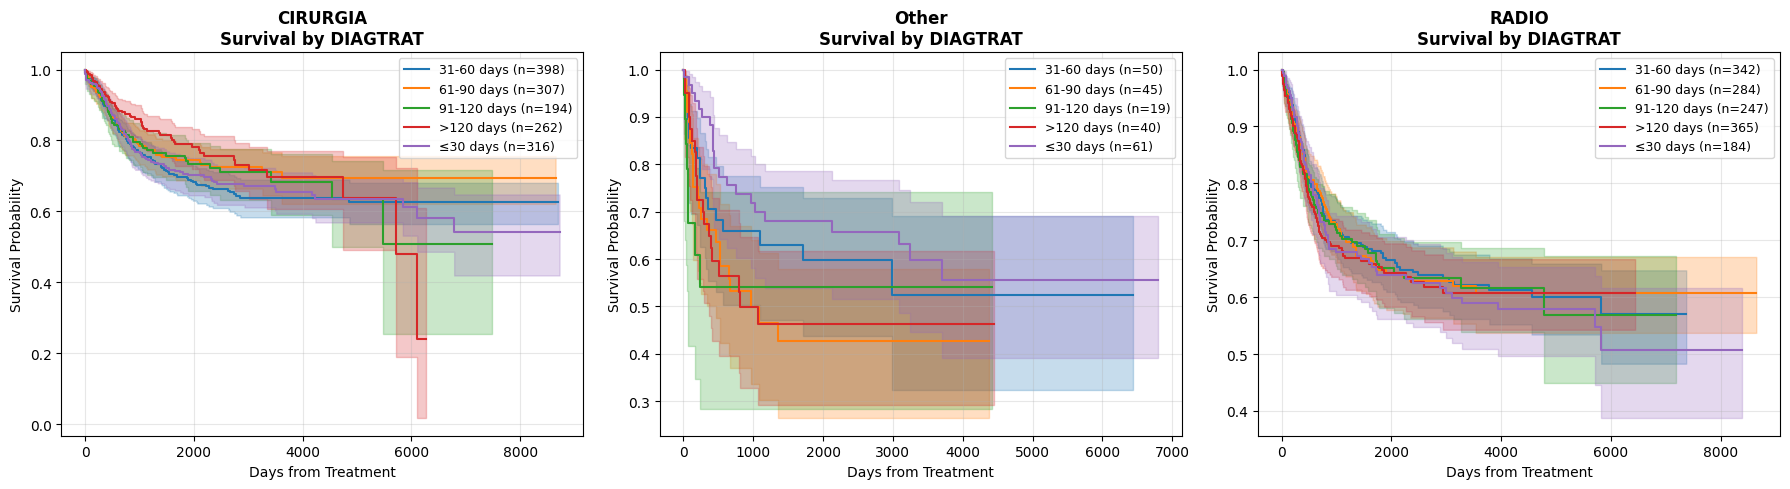


=== Summary: Safe Waiting Times (DIAGTRAT) by Treatment ===

Treatment    N  Events Median DIAGTRAT (days) Safe Waiting Time Threshold HR Continuous HR (per day)
 CIRURGIA 1477     411                     63 Insufficient data          N/A    HR=0.9994 (p=0.3495)
    Other  215      92                     59 Insufficient data          N/A    HR=1.0019 (p=0.0775)
    RADIO 1422     477                     81 Insufficient data          N/A    HR=1.0003 (p=0.5284)



In [61]:
# Visualize DIAGTRAT effect on survival by treatment group
fig, axes = plt.subplots(1, len(treatment_groups_cox), figsize=(6*len(treatment_groups_cox), 5))

if len(treatment_groups_cox) == 1:
    axes = [axes]

for idx, group in enumerate(treatment_groups_cox):
    if group in cox_results:
        ax = axes[idx]
        
        # Get data
        group_data = df_cox_diagtrat[df_cox_diagtrat["TREATMENT_GROUP"] == group].copy()
        
        # Create DIAGTRAT categories for visualization
        group_data["DIAGTRAT_CAT"] = pd.cut(
            group_data["DIAGTRAT"],
            bins=[0, 30, 60, 90, 120, group_data["DIAGTRAT"].max()],
            labels=["≤30", "31-60", "61-90", "91-120", ">120"]
        )
        
        # Plot Kaplan-Meier curves by DIAGTRAT category
        kmf = KaplanMeierFitter()
        colors_km = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
        
        categories = sorted(group_data["DIAGTRAT_CAT"].dropna().unique())
        for i, cat in enumerate(categories):
            cat_data = group_data[group_data["DIAGTRAT_CAT"] == cat]
            if len(cat_data) > 0:
                kmf.fit(
                    cat_data["FOLLOW_DAYS_FROM_TREATMENT"],
                    event_observed=cat_data["ULTINFO_TREAT"],
                    label=f"{cat} days (n={len(cat_data)})"
                )
                kmf.plot(ax=ax, ci_show=True, color=colors_km[i % len(colors_km)])
        
        ax.set_title(f"{group}\nSurvival by DIAGTRAT", fontsize=12, fontweight='bold')
        ax.set_xlabel("Days from Treatment", fontsize=10)
        ax.set_ylabel("Survival Probability", fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

# Summary table of safe waiting times
print("\n=== Summary: Safe Waiting Times (DIAGTRAT) by Treatment ===\n")
summary_data = []

for group in treatment_groups_cox:
    group_data = df_cox_diagtrat[df_cox_diagtrat["TREATMENT_GROUP"] == group]
    
    # Find significant threshold
    if group in threshold_results and threshold_results[group]:
        sig_thresholds = [t for t in threshold_results[group] if t['p'] < 0.05 and t['hr'] > 1]
        if sig_thresholds:
            min_threshold = min(sig_thresholds, key=lambda x: x['threshold'])
            safe_days = f"< {min_threshold['threshold']} days"
            hr_info = f"HR={min_threshold['hr']:.3f} (p={min_threshold['p']:.4f})"
        else:
            safe_days = "No significant threshold found"
            hr_info = "Not significant"
    else:
        safe_days = "Insufficient data"
        hr_info = "N/A"
    
    # Continuous model results
    if group in cox_results:
        cph = cox_results[group]['model']
        if 'DIAGTRAT' in cph.summary.index:
            hr_cont = np.exp(cph.summary.loc['DIAGTRAT', 'coef'])
            p_cont = cph.summary.loc['DIAGTRAT', 'p']
            hr_cont_info = f"HR={hr_cont:.4f} (p={p_cont:.4f})"
        else:
            hr_cont_info = "N/A"
    else:
        hr_cont_info = "N/A"
    
    summary_data.append({
        'Treatment': group,
        'N': len(group_data),
        'Events': group_data['ULTINFO_TREAT'].sum(),
        'Median DIAGTRAT (days)': f"{group_data['DIAGTRAT'].median():.0f}",
        'Safe Waiting Time': safe_days,
        'Threshold HR': hr_info,
        'Continuous HR (per day)': hr_cont_info
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print()


### Visualization: Predicted Death Risk by DIAGTRAT (Waiting Time) for Each Treatment


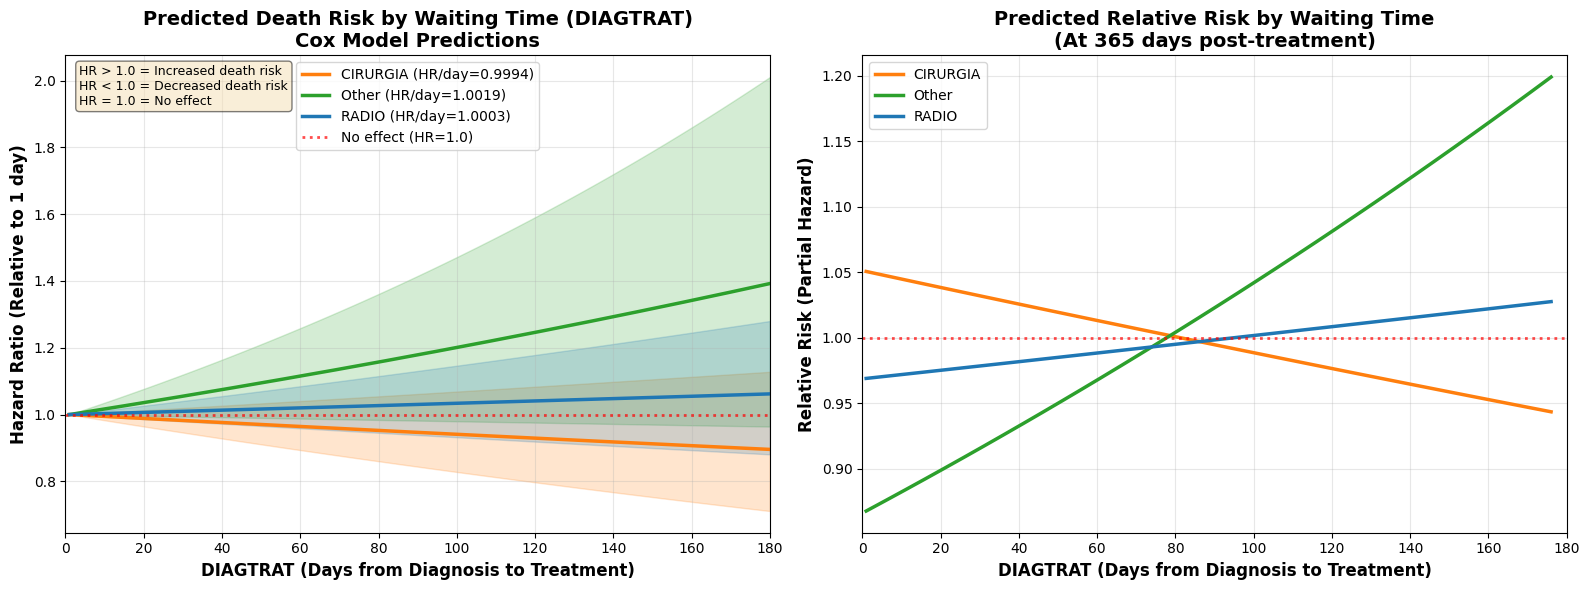


=== SAFE WAITING TIMES SUMMARY ===

CIRURGIA:
  → Insufficient data for threshold analysis
  Continuous model: No significant effect per day (HR=0.9994, p=0.3495)

Other:
  → Insufficient data for threshold analysis
  Continuous model: No significant effect per day (HR=1.0019, p=0.0775)

RADIO:
  → Insufficient data for threshold analysis
  Continuous model: No significant effect per day (HR=1.0003, p=0.5284)



In [62]:
# Create visualization showing predicted hazard ratio/risk as function of DIAGTRAT
# This shows how many days a patient can wait before death risk increases

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Hazard Ratio as function of DIAGTRAT
ax1 = axes[0]

colors = {'RADIO': '#1f77b4', 'CIRURGIA': '#ff7f0e', 'Other': '#2ca02c'}

# Create range of DIAGTRAT values to predict
diagtrat_range = np.arange(1, 181, 1)  # 1 to 180 days

for group in treatment_groups_cox:
    if group in cox_results:
        cph = cox_results[group]['model']
        
        # Get DIAGTRAT coefficient
        if 'DIAGTRAT' in cph.summary.index:
            coef = cph.summary.loc['DIAGTRAT', 'coef']
            hr_per_day = np.exp(coef)
            
            # Calculate HR for each DIAGTRAT value (relative to baseline of 1 day)
            # HR at DIAGTRAT = x is exp(coef * (x - baseline))
            baseline = 1  # Reference: 1 day
            hr_values = np.exp(coef * (diagtrat_range - baseline))
            
            # Get confidence intervals
            ci_lower_coef = cph.summary.loc['DIAGTRAT', 'coef lower 95%']
            ci_upper_coef = cph.summary.loc['DIAGTRAT', 'coef upper 95%']
            hr_ci_lower = np.exp(ci_lower_coef * (diagtrat_range - baseline))
            hr_ci_upper = np.exp(ci_upper_coef * (diagtrat_range - baseline))
            
            # Plot
            ax1.plot(diagtrat_range, hr_values, 
                     label=f"{group} (HR/day={hr_per_day:.4f})", 
                     linewidth=2.5, color=colors.get(group, '#000000'))
            ax1.fill_between(diagtrat_range, hr_ci_lower, hr_ci_upper, 
                            alpha=0.2, color=colors.get(group, '#000000'))
            
            # Mark safe threshold if found
            if group in threshold_results and threshold_results[group]:
                sig_thresholds = [t for t in threshold_results[group] 
                                 if t['p'] < 0.05 and t['hr'] > 1]
                if sig_thresholds:
                    min_threshold = min(sig_thresholds, key=lambda x: x['threshold'])
                    threshold_days = min_threshold['threshold']
                    threshold_hr = min_threshold['hr']
                    
                    # Mark threshold with vertical line
                    ax1.axvline(x=threshold_days, color=colors.get(group, '#000000'), 
                               linestyle='--', linewidth=2, alpha=0.7)
                    ax1.plot(threshold_days, threshold_hr, 'o', 
                            markersize=10, color=colors.get(group, '#000000'))
                    ax1.annotate(f'{group}\nSafe: <{threshold_days}d', 
                               xy=(threshold_days, threshold_hr),
                               xytext=(threshold_days + 20, threshold_hr + 0.1),
                               fontsize=9, fontweight='bold',
                               arrowprops=dict(arrowstyle='->', color=colors.get(group, '#000000')))

# Add reference line at HR = 1 (no effect)
ax1.axhline(y=1.0, color='red', linestyle=':', linewidth=2, alpha=0.7, label='No effect (HR=1.0)')

ax1.set_xlabel('DIAGTRAT (Days from Diagnosis to Treatment)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Hazard Ratio (Relative to 1 day)', fontsize=12, fontweight='bold')
ax1.set_title('Predicted Death Risk by Waiting Time (DIAGTRAT)\nCox Model Predictions', 
              fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best', fontsize=10)
ax1.set_xlim(0, 180)

# Add text box with interpretation
textstr = 'HR > 1.0 = Increased death risk\nHR < 1.0 = Decreased death risk\nHR = 1.0 = No effect'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax1.text(0.02, 0.98, textstr, transform=ax1.transAxes, fontsize=9,
        verticalalignment='top', bbox=props)

# Plot 2: Predicted cumulative hazard or risk at specific time points
ax2 = axes[1]

# Predict risk at a fixed time point (e.g., 1 year after treatment)
time_point = 365  # 1 year in days

for group in treatment_groups_cox:
    if group in cox_results:
        cph = cox_results[group]['model']
        group_data = df_cox_diagtrat[df_cox_diagtrat["TREATMENT_GROUP"] == group]
        
        if 'DIAGTRAT' in cph.summary.index:
            # Get baseline survival at time_point (using median DIAGTRAT as reference)
            median_diagtrat = group_data['DIAGTRAT'].median()
            
            # Create predictions for different DIAGTRAT values
            predicted_risks = []
            diagtrat_test = np.arange(1, 181, 5)  # Every 5 days
            
            for diagtrat_val in diagtrat_test:
                # Create a sample row with this DIAGTRAT value
                sample_data = pd.DataFrame({'DIAGTRAT': [diagtrat_val]})
                
                # Predict partial hazard (relative risk)
                try:
                    partial_hazard = cph.predict_partial_hazard(sample_data).values[0]
                    predicted_risks.append(partial_hazard)
                except:
                    # Fallback: use coefficient directly
                    coef = cph.summary.loc['DIAGTRAT', 'coef']
                    partial_hazard = np.exp(coef * (diagtrat_val - median_diagtrat))
                    predicted_risks.append(partial_hazard)
            
            # Plot relative risk
            ax2.plot(diagtrat_test, predicted_risks, 
                    label=f"{group}", linewidth=2.5, 
                    color=colors.get(group, '#000000'))
            
            # Mark safe threshold
            if group in threshold_results and threshold_results[group]:
                sig_thresholds = [t for t in threshold_results[group] 
                                 if t['p'] < 0.05 and t['hr'] > 1]
                if sig_thresholds:
                    min_threshold = min(sig_thresholds, key=lambda x: x['threshold'])
                    threshold_days = min_threshold['threshold']
                    ax2.axvline(x=threshold_days, color=colors.get(group, '#000000'), 
                               linestyle='--', linewidth=2, alpha=0.7)

ax2.axhline(y=1.0, color='red', linestyle=':', linewidth=2, alpha=0.7)
ax2.set_xlabel('DIAGTRAT (Days from Diagnosis to Treatment)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Relative Risk (Partial Hazard)', fontsize=12, fontweight='bold')
ax2.set_title(f'Predicted Relative Risk by Waiting Time\n(At {time_point} days post-treatment)', 
              fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best', fontsize=10)
ax2.set_xlim(0, 180)

plt.tight_layout()
plt.show()

# Print summary of safe waiting times
print("\n" + "="*70)
print("=== SAFE WAITING TIMES SUMMARY ===")
print("="*70 + "\n")

for group in treatment_groups_cox:
    if group in threshold_results and threshold_results[group]:
        sig_thresholds = [t for t in threshold_results[group] 
                         if t['p'] < 0.05 and t['hr'] > 1]
        if sig_thresholds:
            min_threshold = min(sig_thresholds, key=lambda x: x['threshold'])
            print(f"{group}:")
            print(f"  ✓ SAFE WAITING TIME: < {min_threshold['threshold']} days")
            print(f"  ⚠ RISK INCREASES: ≥ {min_threshold['threshold']} days")
            print(f"  Hazard Ratio at {min_threshold['threshold']} days: {min_threshold['hr']:.3f}")
            print(f"  (95% CI: {min_threshold['ci_lower']:.3f} - {min_threshold['ci_upper']:.3f}, p={min_threshold['p']:.4f})")
        else:
            print(f"{group}:")
            print(f"  → No significant threshold found in tested range (30-180 days)")
            if threshold_results[group]:
                max_hr = max(threshold_results[group], key=lambda x: x['hr'])
                print(f"  Highest HR observed at {max_hr['threshold']} days: {max_hr['hr']:.3f} (p={max_hr['p']:.4f})")
    else:
        print(f"{group}:")
        print(f"  → Insufficient data for threshold analysis")
    
    # Show continuous model result
    if group in cox_results:
        cph = cox_results[group]['model']
        if 'DIAGTRAT' in cph.summary.index:
            hr_per_day = np.exp(cph.summary.loc['DIAGTRAT', 'coef'])
            p_val = cph.summary.loc['DIAGTRAT', 'p']
            if p_val < 0.05:
                direction = "increases" if hr_per_day > 1 else "decreases"
                print(f"  Continuous model: Each day {'increases' if hr_per_day > 1 else 'decreases'} risk by {abs(hr_per_day - 1) * 100:.3f}% (HR={hr_per_day:.4f}, p={p_val:.4f})")
            else:
                print(f"  Continuous model: No significant effect per day (HR={hr_per_day:.4f}, p={p_val:.4f})")
    print()

print("="*70)


### Kaplan Meier de todos os casos no ACCamargo comparado com todos os outros hospitais em estadiamento 2

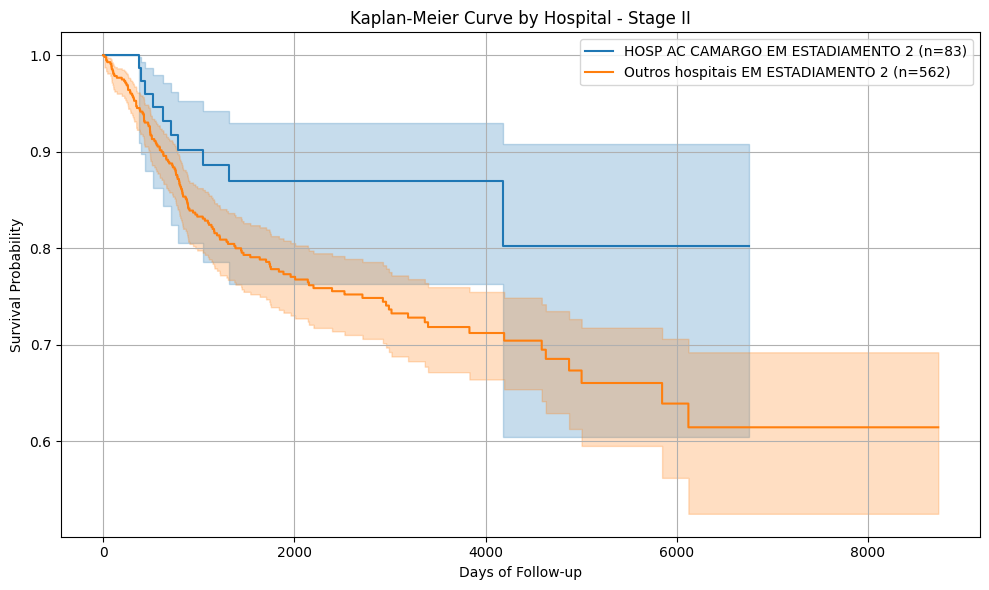

In [10]:
group1 = df_all[(df_all["DSCINST"] == "HOSP AC CAMARGO") & (df_all["ECGRUP"] == "II")]
group2 = df_all[(df_all["DSCINST"] != "HOSP AC CAMARGO") & (df_all["ECGRUP"] == "II")]

# Counts
n_group1 = len(group1)
n_group2 = len(group2)

# Kaplan-Meier fitter
kmf = KaplanMeierFitter()

# Plot
plt.figure(figsize=(10, 6))

# Group 1
label1 = f"HOSP AC CAMARGO EM ESTADIAMENTO 2 (n={n_group1})"
kmf.fit(group1["FOLLOW_DAYS"], event_observed=group1["ULTINFO_TREAT"], label=label1)
kmf.plot(ci_show=True)

# Group 2
label2 = f"Outros hospitais EM ESTADIAMENTO 2 (n={n_group2})"
kmf.fit(group2["FOLLOW_DAYS"], event_observed=group2["ULTINFO_TREAT"], label=label2)
kmf.plot(ci_show=True)

# Plot settings
plt.title("Kaplan-Meier Curve by Hospital - Stage II")
plt.xlabel("Days of Follow-up")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



### Kaplan Meier de todos os casos no ACCamargo comparado com todos os outros hospitais em estadiamento 3

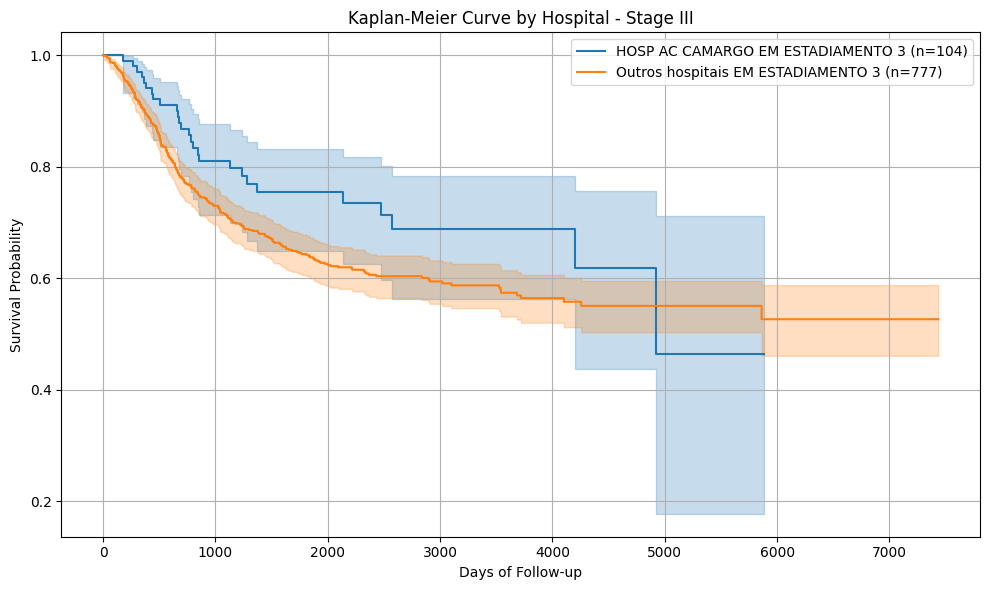

In [11]:
group1 = df_all[(df_all["DSCINST"] == "HOSP AC CAMARGO") & (df_all["ECGRUP"] == "III")]
group2 = df_all[(df_all["DSCINST"] != "HOSP AC CAMARGO") & (df_all["ECGRUP"] == "III")]

# Counts
n_group1 = len(group1)
n_group2 = len(group2)

# Kaplan-Meier fitter
kmf = KaplanMeierFitter()

# Plot
plt.figure(figsize=(10, 6))

# Group 1
label1 = f"HOSP AC CAMARGO EM ESTADIAMENTO 3 (n={n_group1})"
kmf.fit(group1["FOLLOW_DAYS"], event_observed=group1["ULTINFO_TREAT"], label=label1)
kmf.plot(ci_show=True)

# Group 2
label2 = f"Outros hospitais EM ESTADIAMENTO 3 (n={n_group2})"
kmf.fit(group2["FOLLOW_DAYS"], event_observed=group2["ULTINFO_TREAT"], label=label2)
kmf.plot(ci_show=True)

# Plot settings
plt.title("Kaplan-Meier Curve by Hospital - Stage III")
plt.xlabel("Days of Follow-up")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



### Kaplan Meier de todos os casos no ACCamargo comparado com todos os outros hospitais em estadiamento 4

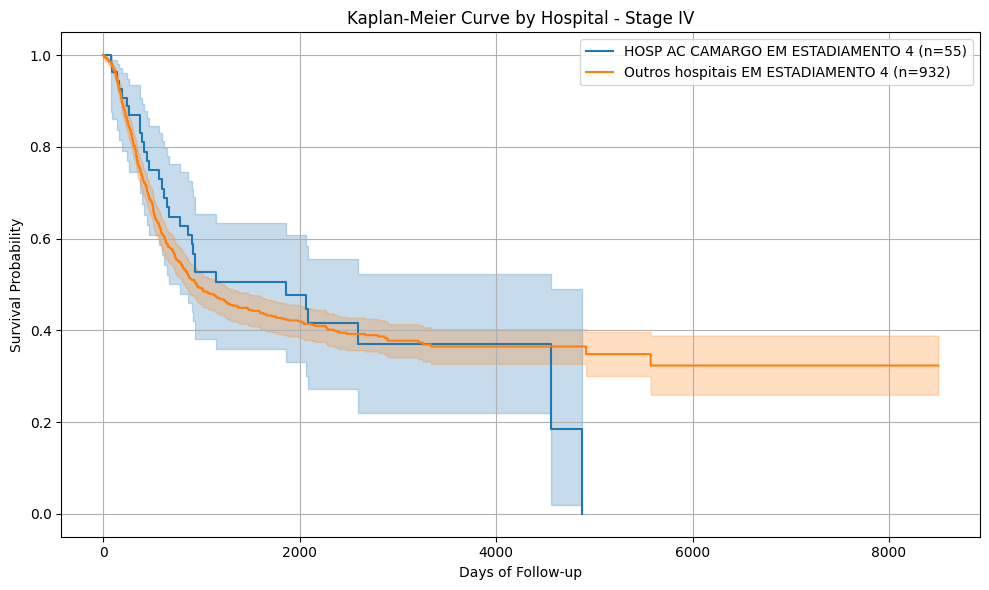

In [12]:
group1 = df_all[(df_all["DSCINST"] == "HOSP AC CAMARGO") & (df_all["ECGRUP"] == "IV")]
group2 = df_all[(df_all["DSCINST"] != "HOSP AC CAMARGO") & (df_all["ECGRUP"] == "IV")]

# Counts
n_group1 = len(group1)
n_group2 = len(group2)

# Kaplan-Meier fitter
kmf = KaplanMeierFitter()

# Plot
plt.figure(figsize=(10, 6))

# Group 1
label1 = f"HOSP AC CAMARGO EM ESTADIAMENTO 4 (n={n_group1})"
kmf.fit(group1["FOLLOW_DAYS"], event_observed=group1["ULTINFO_TREAT"], label=label1)
kmf.plot(ci_show=True)

# Group 2
label2 = f"Outros hospitais EM ESTADIAMENTO 4 (n={n_group2})"
kmf.fit(group2["FOLLOW_DAYS"], event_observed=group2["ULTINFO_TREAT"], label=label2)
kmf.plot(ci_show=True)

# Plot settings
plt.title("Kaplan-Meier Curve by Hospital - Stage IV")
plt.xlabel("Days of Follow-up")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



### Cox Model geral

<lifelines.CoxPHFitter: fitted with 4300 total observations, 3051 right-censored observations>
             duration col = 'FOLLOW_DAYS'
                event col = 'ULTINFO_TREAT'
      baseline estimation = breslow
   number of observations = 4300
number of events observed = 1249
   partial log-likelihood = -9927.84
         time fit was run = 2025-12-03 16:47:22 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
SEXO      -0.30      0.74      0.11           -0.52           -0.09                0.60                0.91
IDADE      0.01      1.01      0.00            0.00            0.02                1.00                1.02

           cmp to     z      p  -log2(p)
covariate                               
SEXO         0.00 -2.84 <0.005      7.79
IDADE        0.00  3.54 <0.005     11.28
---
Concordance = 0.53
Partial AIC = 19859.68
log-likelihood ratio test = 22.49 on 2 df
-log2(p) of ll-ratio test = 16.22

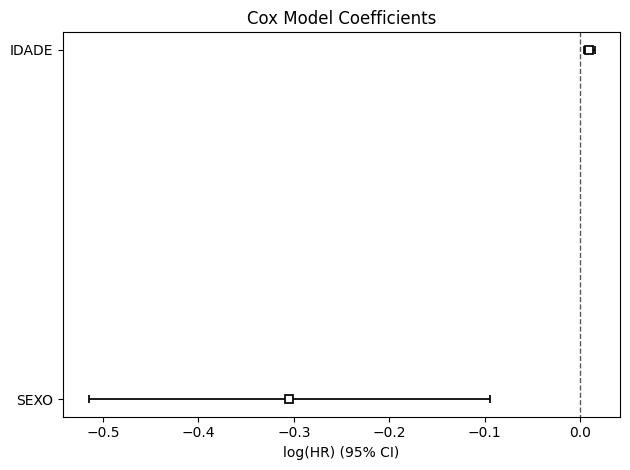

In [13]:
variables = ["SEXO", "IDADE"]


df_model = df_all[["FOLLOW_DAYS", "ULTINFO_TREAT"] + variables].copy()
# Drop missing data
df_model = df_model.dropna()

cph = CoxPHFitter()
cph.fit(df_model, duration_col="FOLLOW_DAYS", event_col="ULTINFO_TREAT")

# --- Step 3: Show results ---
cph.print_summary()  # Print table of HR, CI, p-values

# --- Step 4: Plot coefficients ---
cph.plot()
plt.title("Cox Model Coefficients")
plt.tight_layout()
plt.show()


### 📋 VARIÁVEIS INCLUÍDAS NO MODELO DE COX

### 👤 VARIÁVEIS DEMOGRÁFICAS

### IDADE
- **Tipo:** Variável contínua
- **Definição:** Idade do paciente no momento do diagnóstico
- **Unidade:** Anos
- **Relevância clínica:** Fator prognóstico conhecido em oncologia - pacientes mais idosos geralmente têm pior prognóstico

### SEXO
- **Tipo:** Variável categórica binária
- **Categorias:** 
  - Masculino
  - Feminino
- **Relevância clínica:** Diferenças hormonais e biológicas podem influenciar o prognóstico em alguns tipos de câncer

---

### 💊 VARIÁVEIS DE TRATAMENTO

### RADIO
- **Tipo:** Variável categórica binária
- **Categorias:**
  - 0 = Não recebeu Radio
  - 1 = Recebeu Radio
- **Definição:** Indica se o paciente foi submetido a tratamento Radio
- **Relevância clínica:** Tratamento sistêmico usado em casos mais avançados ou de maior risco

### CIRURGIA
- **Tipo:** Variável categórica binária
- **Categorias:**
  - 0 = Não realizou cirurgia
  - 1 = Realizou cirurgia
- **Definição:** Indica se o paciente foi submetido a procedimento cirúrgico
- **Relevância clínica:** Principal modalidade de tratamento curativo em oncologia

### OUTROS_TRATAMENTOS
- **Tipo:** Variável categórica binária
- **Categorias:**
  - 0 = Não recebeu outros tratamentos
  - 1 = Recebeu outros tratamentos
- **Definição:** Variável composta que inclui:
  - Quimioterapia
  - Hormônioterapia
  - Transplante de medula óssea (TMO)
  - Imunoterapia
  - Outros tratamentos específicos
- **Relevância clínica:** Tratamentos adjuvantes ou alternativos que podem impactar o prognóstico

---

### 🔄 VARIÁVEIS DE RECIDIVA

### RECNENHUM
- **Tipo:** Variável categórica binária
- **Categorias:**
  - 0 = Paciente apresentou algum tipo de recidiva
  - 1 = Paciente não apresentou recidiva
- **Definição:** Indica ausência de recidiva durante o seguimento
- **Relevância clínica:** Ausência de recidiva é indicador de bom prognóstico

---

### 🏥 VARIÁVEIS DE SISTEMA DE SAÚDE

### CONVENIO
- **Tipo:** Variável categórica binária
- **Categorias:**
  - 0 = Não possui convênio médico
  - 1 = Possui convênio médico
- **Definição:** Indica se o paciente tem acesso a plano de saúde privado
- **Relevância clínica:** Proxy para acesso a cuidados médicos e status socioeconômico

### SUS
- **Tipo:** Variável categórica binária
- **Categorias:**
  - 0 = Não atendido pelo SUS
  - 1 = Atendido pelo SUS
- **Definição:** Indica se o paciente foi atendido pelo Sistema Único de Saúde
- **Relevância clínica:** Representa acesso universal aos cuidados de saúde no Brasil

### PARTICULAR
- **Tipo:** Variável categórica binária
- **Categorias:**
  - 0 = Não utilizou sistema particular
  - 1 = Utilizou sistema particular
- **Definição:** Indica se o paciente pagou diretamente pelos cuidados médicos
- **Relevância clínica:** Indica maior poder aquisitivo e acesso facilitado a tratamentos

---

### 📊 RESUMO DAS CATEGORIAS DE VARIÁVEIS

| Categoria | Variáveis | Tipo |
|-----------|-----------|------|
| **Demográficas** | IDADE, SEXO | Contínua, Binária |
| **Tratamento** | RADIO, CIRURGIA, OUTROS_TRATAMENTOS | Binárias |
| **Recidiva** | RECNENHUM, RECLOCAL, RECREGIO | Binárias |
| **Sistema de Saúde** | CONVENIO, SUS, PARTICULAR | Binárias |




                       IDADE      SEXO  CIRURGIA     RADIO  \
IDADE               1.000000 -0.155217  0.052689 -0.138618   
SEXO               -0.155217  1.000000  0.141250 -0.060832   
CIRURGIA            0.052689  0.141250  1.000000 -0.727955   
RADIO              -0.138618 -0.060832 -0.727955  1.000000   
OUTROS_TRATAMENTOS  0.045934  0.022756  0.022088  0.057313   
RECNENHUM           0.046368  0.100828 -0.052123 -0.002208   
TRATCONS            0.012303 -0.044136 -0.115387  0.066803   
DIAGTRAT            0.091785  0.012105  0.072816 -0.048457   
SUS                 0.086885  0.047362  0.017994 -0.056722   
PARTICULAR         -0.090000 -0.101890  0.087158 -0.147045   

                    OUTROS_TRATAMENTOS  RECNENHUM  TRATCONS  DIAGTRAT  \
IDADE                         0.045934   0.046368  0.012303  0.091785   
SEXO                          0.022756   0.100828 -0.044136  0.012105   
CIRURGIA                      0.022088  -0.052123 -0.115387  0.072816   
RADIO                    

<lifelines.CoxPHFitter: fitted with 241 total observations, 223 right-censored observations>
             duration col = 'FOLLOW_DAYS'
                event col = 'ULTINFO_TREAT'
      baseline estimation = breslow
   number of observations = 241
number of events observed = 18
   partial log-likelihood = -64.72
         time fit was run = 2025-12-16 12:39:29 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
IDADE               0.07      1.07      0.03            0.02            0.12                1.02                1.13
SEXO                0.72      2.06      1.13           -1.50            2.94                0.22               18.88
CIRURGIA           -2.66      0.07      0.83           -4.28           -1.04                0.01                0.35
RADIO              -2.47      0.08      0.76           -3.97           -0.98                0.02                0.38
OUTROS_TRATAMENTOS  2.26      9.62      0.90            0.50            4.03                1.65               56.14
RECNENHUM          -2.43      0.09      0.60           -3.60           -1.27                0.03                0.28
TRATCONS            0.00      1.00      0.00           -0.00            0.01                1.00                1.01
DIAGTRAT           -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
SUS                -1.16      0.31      1.32           -3.75            1.43                0.02                4.16
PARTICULAR          0.97      2.63      1.16           -1.30            3.23                0.27               25.31

                    cmp to     z      p  -log2(p)
covariate                                        
IDADE                 0.00  2.66   0.01      7.02
SEXO                  0.00  0.64   0.52      0.93
CIRURGIA              0.00 -3.21 <0.005      9.57
RADIO                 0.00 -3.24 <0.005      9.70
OUTROS_TRATAMENTOS    0.00  2.51   0.01      6.39
RECNENHUM             0.00 -4.08 <0.005     14.47
TRATCONS              0.00  1.05   0.30      1.76
DIAGTRAT              0.00 -0.85   0.40      1.33
SUS                   0.00 -0.88   0.38      1.40
PARTICULAR            0.00  0.84   0.40      1.31
---
Concordance = 0.84
Partial AIC = 149.43
log-likelihood ratio test = 35.52 on 10 df
-log2(p) of ll-ratio test = 13.26

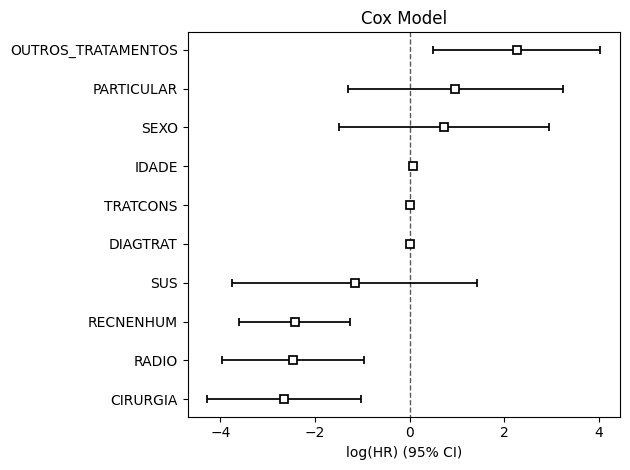


=== APPROACH 1: Remove Non-Significant Variables ===
Variables with p < 0.05: ['IDADE', 'CIRURGIA', 'RADIO', 'OUTROS_TRATAMENTOS', 'RECNENHUM']

Reduced Model (only p < 0.05):


<lifelines.CoxPHFitter: fitted with 241 total observations, 223 right-censored observations>
             duration col = 'FOLLOW_DAYS'
                event col = 'ULTINFO_TREAT'
      baseline estimation = breslow
   number of observations = 241
number of events observed = 18
   partial log-likelihood = -65.99
         time fit was run = 2025-12-16 12:39:29 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
IDADE               0.06      1.06      0.02            0.01            0.11                1.01                1.11
CIRURGIA           -2.46      0.09      0.79           -4.01           -0.91                0.02                0.40
RADIO              -2.32      0.10      0.72           -3.74           -0.91                0.02                0.40
OUTROS_TRATAMENTOS  2.37     10.71      0.80            0.80            3.94                2.23               51.53
RECNENHUM          -2.37      0.09      0.57           -3.48           -1.25                0.03                0.29

                    cmp to     z      p  -log2(p)
covariate                                        
IDADE                 0.00  2.57   0.01      6.61
CIRURGIA              0.00 -3.11 <0.005      9.05
RADIO                 0.00 -3.23 <0.005      9.64
OUTROS_TRATAMENTOS    0.00  2.96 <0.005      8.34
RECNENHUM             0.00 -4.17 <0.005     14.99
---
Concordance = 0.84
Partial AIC = 141.99
log-likelihood ratio test = 32.97 on 5 df
-log2(p) of ll-ratio test = 18.00


=== APPROACH 2: Ridge Regression (L2) ===

Best Ridge penalizer: 0.0005, score: 0.8450168918918919


<lifelines.CoxPHFitter: fitted with 241 total observations, 223 right-censored observations>
             duration col = 'FOLLOW_DAYS'
                event col = 'ULTINFO_TREAT'
                penalizer = 0.0005
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 241
number of events observed = 18
   partial log-likelihood = -65.00
         time fit was run = 2025-12-16 12:39:30 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
IDADE               0.07      1.07      0.03            0.02            0.12                1.02                1.13
SEXO                0.68      1.97      1.12           -1.52            2.88                0.22               17.78
CIRURGIA           -2.57      0.08      0.81           -4.16           -0.98                0.02                0.38
RADIO              -2.40      0.09      0.76           -3.88           -0.92                0.02                0.40
OUTROS_TRATAMENTOS  2.24      9.40      0.89            0.49            3.99                1.63               54.26
RECNENHUM          -2.39      0.09      0.59           -3.55           -1.24                0.03                0.29
TRATCONS            0.00      1.00      0.00           -0.00            0.01                1.00                1.01
DIAGTRAT           -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
SUS                -1.10      0.33      1.28           -3.61            1.41                0.03                4.08
PARTICULAR          0.95      2.58      1.15           -1.31            3.20                0.27               24.48

                    cmp to     z      p  -log2(p)
covariate                                        
IDADE                 0.00  2.66   0.01      6.99
SEXO                  0.00  0.60   0.55      0.87
CIRURGIA              0.00 -3.17 <0.005      9.34
RADIO                 0.00 -3.17 <0.005      9.36
OUTROS_TRATAMENTOS    0.00  2.50   0.01      6.35
RECNENHUM             0.00 -4.06 <0.005     14.31
TRATCONS              0.00  1.03   0.30      1.73
DIAGTRAT              0.00 -0.83   0.40      1.31
SUS                   0.00 -0.86   0.39      1.36
PARTICULAR            0.00  0.82   0.41      1.29
---
Concordance = 0.85
Partial AIC = 149.99
log-likelihood ratio test = 34.96 on 10 df
-log2(p) of ll-ratio test = 12.95


=== APPROACH 3: Elastic Net (L1+L2) with Small Penalizer ===

Best Elastic Net params: {'l1_ratio': 0.7, 'penalizer': 0.0005}


<lifelines.CoxPHFitter: fitted with 241 total observations, 223 right-censored observations>
             duration col = 'FOLLOW_DAYS'
                event col = 'ULTINFO_TREAT'
                penalizer = 0.0005
                 l1 ratio = 0.7
      baseline estimation = breslow
   number of observations = 241
number of events observed = 18
   partial log-likelihood = -65.27
         time fit was run = 2025-12-16 12:39:30 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
IDADE               0.07      1.07      0.03            0.02            0.12                1.02                1.13
SEXO                0.64      1.90      1.14           -1.59            2.88                0.20               17.73
CIRURGIA           -2.57      0.08      0.82           -4.17           -0.96                0.02                0.38
RADIO              -2.40      0.09      0.76           -3.89           -0.90                0.02                0.40
OUTROS_TRATAMENTOS  2.24      9.37      0.90            0.48            4.00                1.61               54.40
RECNENHUM          -2.39      0.09      0.59           -3.55           -1.23                0.03                0.29
TRATCONS            0.00      1.00      0.00           -0.00            0.01                1.00                1.01
DIAGTRAT           -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
SUS                -1.07      0.34      1.28           -3.57            1.43                0.03                4.19
PARTICULAR          0.93      2.53      1.16           -1.35            3.20                0.26               24.59

                    cmp to     z      p  -log2(p)
covariate                                        
IDADE                 0.00  2.63   0.01      6.86
SEXO                  0.00  0.56   0.57      0.80
CIRURGIA              0.00 -3.14 <0.005      9.19
RADIO                 0.00 -3.15 <0.005      9.24
OUTROS_TRATAMENTOS    0.00  2.49   0.01      6.30
RECNENHUM             0.00 -4.04 <0.005     14.19
TRATCONS              0.00  0.99   0.32      1.64
DIAGTRAT              0.00 -0.80   0.42      1.25
SUS                   0.00 -0.84   0.40      1.32
PARTICULAR            0.00  0.80   0.42      1.24
---
Concordance = 0.85
Partial AIC = 150.54
log-likelihood ratio test = 34.42 on 10 df
-log2(p) of ll-ratio test = 12.64


=== P-VALUE COMPARISON (All Models) ===

Total variables in comparison: 10
Expected variables: 10
                              Variable  Standard_P  Standard_Coef  Ridge_P  \
RECNENHUM                    RECNENHUM      0.0000        -2.4338   0.0000   
RADIO                            RADIO      0.0012        -2.4731   0.0015   
CIRURGIA                      CIRURGIA      0.0013        -2.6574   0.0015   
IDADE                            IDADE      0.0077         0.0693   0.0079   
OUTROS_TRATAMENTOS  OUTROS_TRATAMENTOS      0.0119         2.2634   0.0123   
TRATCONS                      TRATCONS      0.2954         0.0029   0.3021   
SUS                                SUS      0.3793        -1.1606   0.3887   
DIAGTRAT                      DIAGTRAT      0.3965        -0.0007   0.4040   
PARTICULAR                  PARTICULAR      0.4034         0.9659   0.4101   
SEXO                              SEXO      0.5242         0.7206   0.5465   

                    Ridge_Coef  ElasticNet

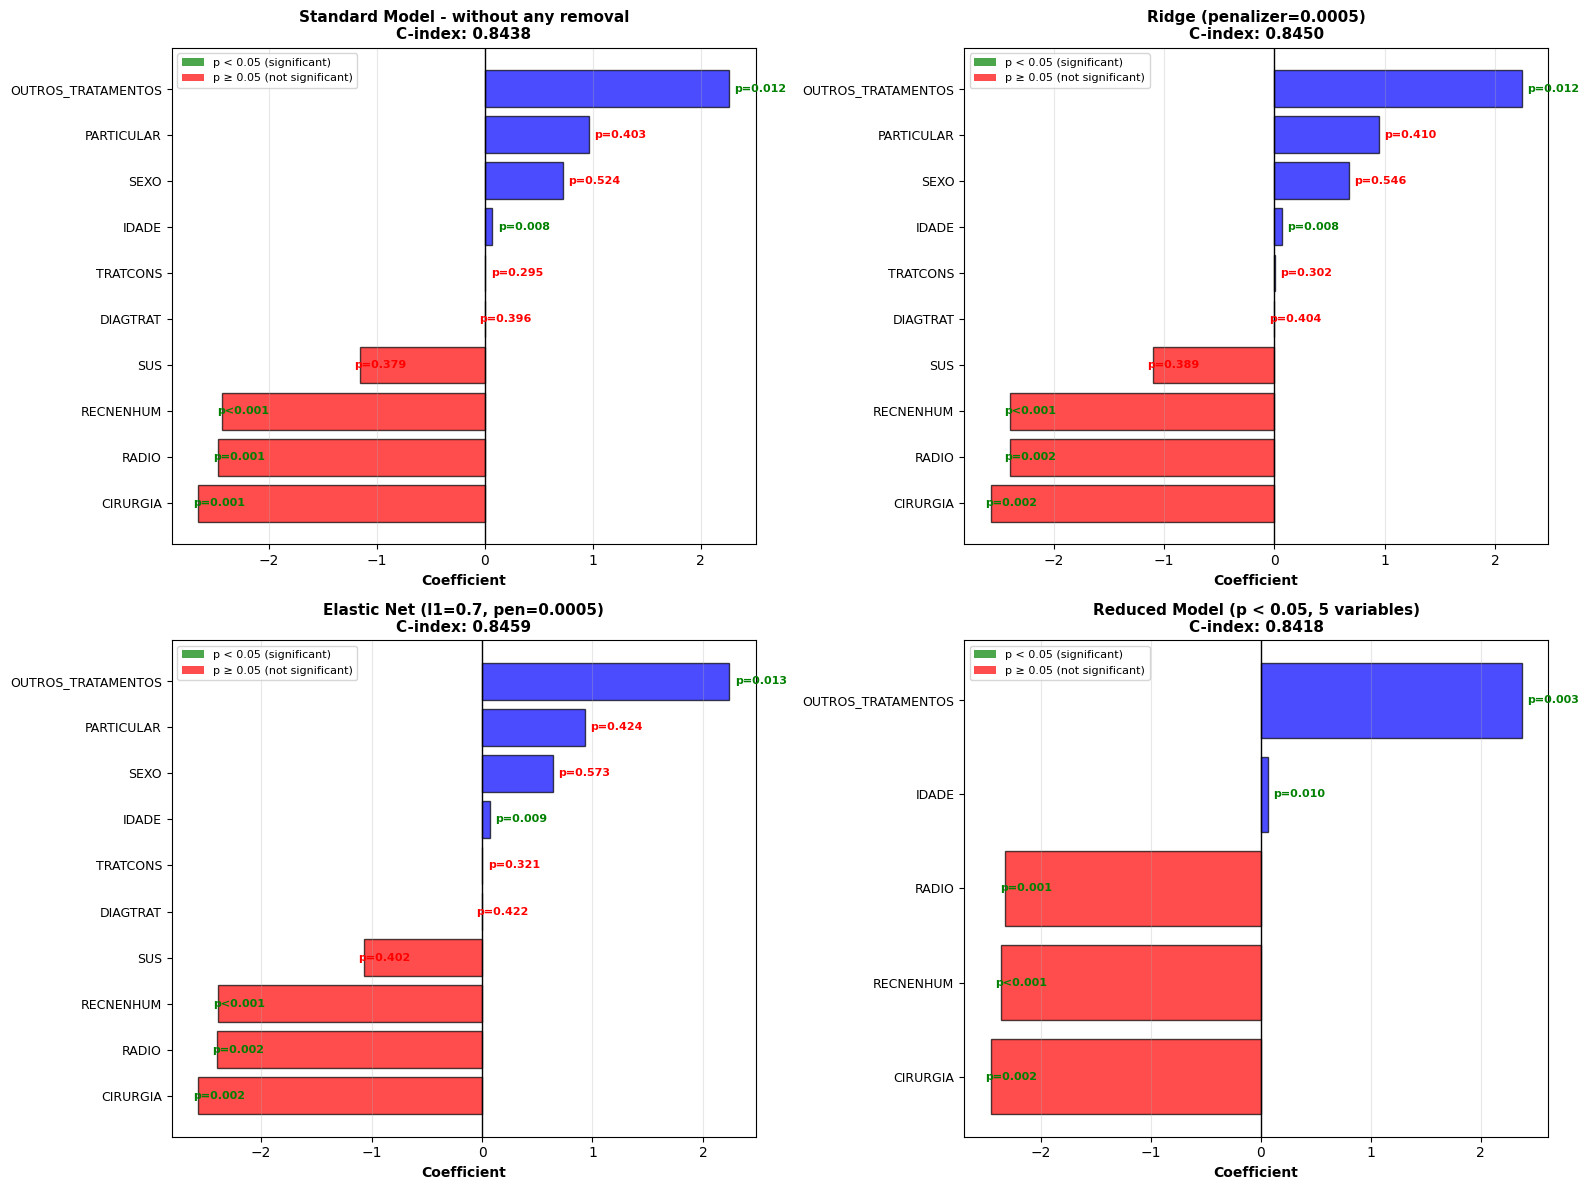

In [5]:
variables = ["IDADE", "SEXO", "CIRURGIA", "RADIO", "OUTROS_TRATAMENTOS", "RECNENHUM", "TRATCONS", "DIAGTRAT"]
others_treatments = ["QUIMIO", "HORMONIO", "TMO", "IMUNO", "OUTROS"]
attend_categories = ["SUS", "PARTICULAR"]
diag_prev_categories = []

df_model_dummy = df_all.copy()

# Create other treatments variable
df_model_dummy["OUTROS_TRATAMENTOS"] = df_model_dummy[others_treatments].any(axis=1).astype(int)

df_model_dummy = df_model_dummy[df_model_dummy['ECGRUP'].isin(['I'])]
df_model_dummy = df_model_dummy[df_model_dummy['DSCINST'] == "HOSP AC CAMARGO"]
#df_model_dummy = df_model_dummy[df_model_dummy['DIAGTRAT'] > 30]


df_model_dummy["DIAGPREV_EXAME"] = df_model_dummy["DIAGPREV"].map(lambda x: 1 if x == 1 else 0)
df_model_dummy["DIAGPREV_RECURSOS"] = df_model_dummy["DIAGPREV"].map(lambda x: 1 if x == 2 else 0)
df_model_dummy["DIAGPREV_CONFIRMACAO"] = df_model_dummy["DIAGPREV"].map(lambda x: 1 if x == 3 else 0)
df_model_dummy["DIAGPREV_SEM_INF"] = df_model_dummy["DIAGPREV"].map(lambda x: 1 if x == 4 else 0)

# Map the attend_categories to the values in the dataframe
df_model_dummy["CONVENIO"] = df_model_dummy["CATEATEND"].map(lambda x: 1 if x == 1 else 0)
df_model_dummy["SUS"] = df_model_dummy["CATEATEND"].map(lambda x: 1 if x == 2 else 0)
df_model_dummy["PARTICULAR"] = df_model_dummy["CATEATEND"].map(lambda x: 1 if x == 3 else 0)
df_model_dummy["SEM_INF"] = df_model_dummy["CATEATEND"].map(lambda x: 1 if x == 9 else 0)

all_variables_dummy = variables + attend_categories + diag_prev_categories

# ============================================================================
# HANDLE IMMORTAL TIME BIAS FOR DIAGTRAT
# DIAGTRAT = days from consultation to treatment
# Immortal time bias: Patients with longer DIAGTRAT have a period where they cannot die
# Solution: Create adjusted follow-up time that excludes the immortal period
# ============================================================================

# Ensure DIAGTRAT is numeric
df_model_dummy["DIAGTRAT"] = pd.to_numeric(df_model_dummy["DIAGTRAT"], errors='coerce')

# Create adjusted follow-up time: subtract DIAGTRAT (immortal time) from FOLLOW_DAYS
# This accounts for the fact that patients can't die during the wait period
df_model_dummy["FOLLOW_DAYS_ADJUSTED"] = df_model_dummy["FOLLOW_DAYS"] - df_model_dummy["DIAGTRAT"]

# Only keep patients where adjusted follow-up is positive (they survived past treatment)
df_model_dummy = df_model_dummy[df_model_dummy["FOLLOW_DAYS_ADJUSTED"] > 0]

# Keep original columns for comparison (biased model)
df_model_dummy = df_model_dummy[["FOLLOW_DAYS", "FOLLOW_DAYS_ADJUSTED", "ULTINFO_TREAT"] + all_variables_dummy]
df_model_dummy = df_model_dummy.dropna()

print(f"Total patients after immortal time adjustment: {len(df_model_dummy)}")
print(f"\nDIAGTRAT statistics:")
print(df_model_dummy["DIAGTRAT"].describe())
print(f"\nOriginal FOLLOW_DAYS mean: {df_model_dummy['FOLLOW_DAYS'].mean():.1f} days")
print(f"Adjusted FOLLOW_DAYS mean: {df_model_dummy['FOLLOW_DAYS_ADJUSTED'].mean():.1f} days")
print(f"Difference (immortal time): {(df_model_dummy['FOLLOW_DAYS'].mean() - df_model_dummy['FOLLOW_DAYS_ADJUSTED'].mean()):.1f} days")

print("\n" + "="*80)
print("CORRELATION MATRIX")
print("="*80)
print(df_model_dummy[all_variables_dummy].corr())

# STANDARD MODEL: All variables (no removal)
# Compare biased (original) vs adjusted (unbiased) models
print("\n" + "="*80)
print("STANDARD COX MODEL - COMPARISON: BIASED vs ADJUSTED (IMMORTAL TIME HANDLED)")
print("="*80)

# Model 1: WITH immortal time bias (original FOLLOW_DAYS)
print("\n--- MODEL 1: WITH IMMORTAL TIME BIAS (Original FOLLOW_DAYS) ---")
cph_dummy_biased = CoxPHFitter()
cph_dummy_biased.fit(df_model_dummy, duration_col="FOLLOW_DAYS", event_col="ULTINFO_TREAT")
print(f"C-index: {cph_dummy_biased.concordance_index_:.4f}")
if "DIAGTRAT" in cph_dummy_biased.summary.index:
    print(f"DIAGTRAT coefficient (biased): {cph_dummy_biased.summary.loc['DIAGTRAT', 'coef']:.4f}")
    print(f"DIAGTRAT p-value (biased): {cph_dummy_biased.summary.loc['DIAGTRAT', 'p']:.4f}")
cph_dummy_biased.print_summary()

# Model 2: WITHOUT immortal time bias (adjusted FOLLOW_DAYS)
print("\n--- MODEL 2: WITHOUT IMMORTAL TIME BIAS (Adjusted FOLLOW_DAYS_ADJUSTED) ---")
cph_dummy = CoxPHFitter()
cph_dummy.fit(df_model_dummy, duration_col="FOLLOW_DAYS_ADJUSTED", event_col="ULTINFO_TREAT")
print(f"C-index: {cph_dummy.concordance_index_:.4f}")
if "DIAGTRAT" in cph_dummy.summary.index:
    print(f"DIAGTRAT coefficient (adjusted): {cph_dummy.summary.loc['DIAGTRAT', 'coef']:.4f}")
    print(f"DIAGTRAT p-value (adjusted): {cph_dummy.summary.loc['DIAGTRAT', 'p']:.4f}")
cph_dummy.print_summary()

# Comparison plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot biased model
cph_dummy_biased.plot(ax=axes[0])
axes[0].set_title("Cox Model - WITH Immortal Time Bias\n(Original FOLLOW_DAYS)", fontweight='bold')
axes[0].set_xlabel("Coefficient", fontweight='bold')

# Plot adjusted model
cph_dummy.plot(ax=axes[1])
axes[1].set_title("Cox Model - WITHOUT Immortal Time Bias\n(Adjusted FOLLOW_DAYS_ADJUSTED)", fontweight='bold')
axes[1].set_xlabel("Coefficient", fontweight='bold')

plt.tight_layout()
plt.show()

# Approach 1: Remove non-significant variables (p < 0.05)
print("\n=== APPROACH 1: Remove Non-Significant Variables (Using Adjusted Time) ===")
sig_vars = cph_dummy.summary[cph_dummy.summary['p'] < 0.05].index.tolist()
print(f"Variables with p < 0.05: {sig_vars}")

if len(sig_vars) > 0:
    df_model_reduced = df_model_dummy[["FOLLOW_DAYS_ADJUSTED", "ULTINFO_TREAT"] + sig_vars].copy()
    df_model_reduced = df_model_reduced.dropna()
    
    cph_reduced = CoxPHFitter()
    cph_reduced.fit(df_model_reduced, duration_col="FOLLOW_DAYS_ADJUSTED", event_col="ULTINFO_TREAT")
    print("\nReduced Model (only p < 0.05, using adjusted time):")
    cph_reduced.print_summary()

# Approach 2: Ridge Regression (L2 regularization) - gentler than LASSO
print("\n=== APPROACH 2: Ridge Regression (L2) - Using Adjusted Time ===")
# Try smaller penalizers for Ridge
penalizers_ridge = [0.0005, 0.001, 0.01, 0.05, 0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
best_score_ridge = -np.inf
best_penalizer_ridge = 0.0005
best_cph_ridge = None

for penalizer in penalizers_ridge:
    try:
        cph_ridge = CoxPHFitter(l1_ratio=0.0, penalizer=penalizer)  # l1_ratio=0.0 is pure Ridge
        cph_ridge.fit(df_model_dummy, duration_col="FOLLOW_DAYS_ADJUSTED", event_col="ULTINFO_TREAT")
        score = cph_ridge.concordance_index_
        if score > best_score_ridge:
            best_score_ridge = score
            best_penalizer_ridge = penalizer
            best_cph_ridge = cph_ridge
    except:
        continue

# Fit final Ridge model
cph_ridge = CoxPHFitter(l1_ratio=0.0, penalizer=best_penalizer_ridge)
cph_ridge.fit(df_model_dummy, duration_col="FOLLOW_DAYS_ADJUSTED", event_col="ULTINFO_TREAT")

print(f"\nBest Ridge penalizer: {best_penalizer_ridge}, score: {best_score_ridge}")
cph_ridge.print_summary()

# Approach 3: Elastic Net (mix of L1 and L2) with very small penalizer
print("\n=== APPROACH 3: Elastic Net (L1+L2) with Small Penalizer - Using Adjusted Time ===")
penalizers_elastic = [0.0005,0.001, 0.01, 0.05]
best_score_elastic = -np.inf
best_params_elastic = {'l1_ratio': 0.5, 'penalizer': 0.01}

for l1_ratio in [0.3, 0.5, 0.7]:
    for penalizer in penalizers_elastic:
        try:
            cph_elastic = CoxPHFitter(l1_ratio=l1_ratio, penalizer=penalizer)
            cph_elastic.fit(df_model_dummy, duration_col="FOLLOW_DAYS_ADJUSTED", event_col="ULTINFO_TREAT")
            score = cph_elastic.concordance_index_
            if score > best_score_elastic:
                best_score_elastic = score
                best_params_elastic = {'l1_ratio': l1_ratio, 'penalizer': penalizer}
        except:
            continue

cph_elastic = CoxPHFitter(l1_ratio=best_params_elastic['l1_ratio'], 
                         penalizer=best_params_elastic['penalizer'])
cph_elastic.fit(df_model_dummy, duration_col="FOLLOW_DAYS_ADJUSTED", event_col="ULTINFO_TREAT")

print(f"\nBest Elastic Net params: {best_params_elastic}")
cph_elastic.print_summary()


# Compare all models
print("\n=== P-VALUE COMPARISON (All Models) ===")
# Ensure we get all variables, even if some were dropped during fitting
comparison = pd.DataFrame(index=all_variables_dummy)
comparison['Variable'] = all_variables_dummy

# Get values from summaries, handling missing variables
for var in all_variables_dummy:
    if var in cph_dummy.summary.index:
        comparison.loc[var, 'Standard_P'] = cph_dummy.summary.loc[var, 'p']
        comparison.loc[var, 'Standard_Coef'] = cph_dummy.summary.loc[var, 'coef']
    else:
        comparison.loc[var, 'Standard_P'] = np.nan
        comparison.loc[var, 'Standard_Coef'] = np.nan
    
    if var in cph_ridge.summary.index:
        comparison.loc[var, 'Ridge_P'] = cph_ridge.summary.loc[var, 'p']
        comparison.loc[var, 'Ridge_Coef'] = cph_ridge.summary.loc[var, 'coef']
    else:
        comparison.loc[var, 'Ridge_P'] = np.nan
        comparison.loc[var, 'Ridge_Coef'] = np.nan
    
    if var in cph_elastic.summary.index:
        comparison.loc[var, 'ElasticNet_P'] = cph_elastic.summary.loc[var, 'p']
        comparison.loc[var, 'ElasticNet_Coef'] = cph_elastic.summary.loc[var, 'coef']
    else:
        comparison.loc[var, 'ElasticNet_P'] = np.nan
        comparison.loc[var, 'ElasticNet_Coef'] = np.nan
if len(sig_vars) > 0:
    comparison['Reduced_P'] = np.nan
    comparison['Reduced_Coef'] = np.nan
    for var in sig_vars:
        if var in cph_reduced.summary.index:
            comparison.loc[var, 'Reduced_P'] = cph_reduced.summary.loc[var, 'p']
            comparison.loc[var, 'Reduced_Coef'] = cph_reduced.summary.loc[var, 'coef']

comparison = comparison.sort_values('Standard_P')
print(f"\nTotal variables in comparison: {len(comparison)}")
print(f"Expected variables: {len(all_variables_dummy)}")

# Ensure comparison has all variables - if not, add missing ones
if len(comparison) < len(all_variables_dummy):
    missing_vars = set(all_variables_dummy) - set(comparison.index)
    print(f"WARNING: Missing variables in comparison: {missing_vars}")
    for var in missing_vars:
        comparison.loc[var] = {
            'Variable': var,
            'Standard_P': np.nan,
            'Ridge_P': np.nan,
            'ElasticNet_P': np.nan,
            'Standard_Coef': np.nan,
            'Ridge_Coef': np.nan,
            'ElasticNet_Coef': np.nan
        }
    comparison = comparison.sort_values('Standard_P')
    print(f"Fixed: Now has {len(comparison)} variables")

print(comparison.round(4))

# Count significant variables
print(f"\nSignificant variables (p < 0.05):")
print(f"Standard model: {(comparison['Standard_P'] < 0.05).sum()}/{len(all_variables_dummy)}")
print(f"Ridge model: {(comparison['Ridge_P'] < 0.05).sum()}/{len(all_variables_dummy)}")
print(f"Elastic Net model: {(comparison['ElasticNet_P'] < 0.05).sum()}/{len(all_variables_dummy)}")
if len(sig_vars) > 0:
    print(f"Reduced model: {(comparison['Reduced_P'] < 0.05).sum()}/{len(sig_vars)}")

# Plot comparison with coefficients and p-values
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Helper function to plot coefficients and p-values
def plot_coefs_and_pvals(model, ax, title, cv_result=None):
    """Plot coefficients as bars with p-values as text annotations"""
    if model is None or len(model.summary) == 0:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        return
    
    summary = model.summary.sort_values('coef', ascending=True)
    y_pos = np.arange(len(summary))
    
    # Get concordance index
    try:
        concordance = model.concordance_index_
        ci_text = f"C-index: {concordance:.4f}"
    except:
        ci_text = "C-index: N/A"
    
    # Add CV results if available
    if cv_result is not None:
        ci_text += f"\nCV C-index: {cv_result['mean']:.4f} ± {cv_result['std']:.4f}"
    

    # Plot coefficients as bars
    colors = ['red' if coef < 0 else 'blue' for coef in summary['coef']]
    bars = ax.barh(y_pos, summary['coef'], color=colors, alpha=0.7, edgecolor='black')
    
    # Add p-value annotations
    for i, (idx, row) in enumerate(summary.iterrows()):
        p_val = row['p']
        coef = row['coef']
        # Position text at the end of the bar
        x_pos = coef + (0.05 if coef >= 0 else -0.05)
        # Format p-value
        if p_val < 0.001:
            p_text = 'p<0.001'
        elif p_val < 0.01:

            p_text = f'p={p_val:.3f}'
        else:
            p_text = f'p={p_val:.3f}'
        
        # Color code p-values: green if significant, red if not
        color = 'green' if p_val < 0.05 else 'red'
        ax.text(x_pos, i, p_text, va='center', fontsize=8, color=color, fontweight='bold')
    
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(summary.index, fontsize=9)
    ax.set_xlabel('Coefficient', fontsize=10, fontweight='bold')
    ax.set_title(f"{title}\n{ci_text}", fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Add legend for p-values
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='green', alpha=0.7, label='p < 0.05 (significant)'),
        Patch(facecolor='red', alpha=0.7, label='p ≥ 0.05 (not significant)')
    ]
    ax.legend(handles=legend_elements, loc='best', fontsize=8)

# Standard Model
plot_coefs_and_pvals(cph_dummy, axes[0,0], f"Standard Model - without any removal")

# Ridge Model
plot_coefs_and_pvals(cph_ridge, axes[0,1], f"Ridge (penalizer={best_penalizer_ridge})")

# Elastic Net Model
plot_coefs_and_pvals(cph_elastic, axes[1,0], f"Elastic Net (l1={best_params_elastic['l1_ratio']}, pen={best_params_elastic['penalizer']})")

# Reduced Model
if len(sig_vars) > 0:
    plot_coefs_and_pvals(cph_reduced, axes[1,1], f"Reduced Model (p < 0.05, {len(sig_vars)} variables)")
else:
    axes[1,1].text(0.5, 0.5, 'No reduced model available', ha='center', va='center', transform=axes[1,1].transAxes)
    axes[1,1].set_title("Reduced Model")

plt.tight_layout()
plt.show()




### DIAGTRAT Analysis with Immortal Time Bias Handling


=== DIAGTRAT ANALYSIS WITH IMMORTAL TIME BIAS HANDLING ===

Total patients: 241
DIAGTRAT statistics:
count     241.000000
mean       69.788382
std       239.808450
min         1.000000
25%        20.000000
50%        31.000000
75%        55.000000
max      3261.000000
Name: DIAGTRAT, dtype: float64

DIAGTRAT range: 1 to 3261 days

=== APPROACH 1: LANDMARK ANALYSIS ===

--- Landmark at 30 days ---
Patients included: 238
DIAGTRAT coefficient: -0.0005
DIAGTRAT p-value: 0.5562
DIAGTRAT Hazard Ratio: 0.9995
Model C-index: 0.8416

--- Landmark at 60 days ---
Patients included: 236
DIAGTRAT coefficient: -0.0005
DIAGTRAT p-value: 0.5562
DIAGTRAT Hazard Ratio: 0.9995
Model C-index: 0.8416

--- Landmark at 90 days ---
Patients included: 233
DIAGTRAT coefficient: -0.0005
DIAGTRAT p-value: 0.5562
DIAGTRAT Hazard Ratio: 0.9995
Model C-index: 0.8416

=== APPROACH 2: STRATIFIED ANALYSIS BY DIAGTRAT CATEGORIES ===


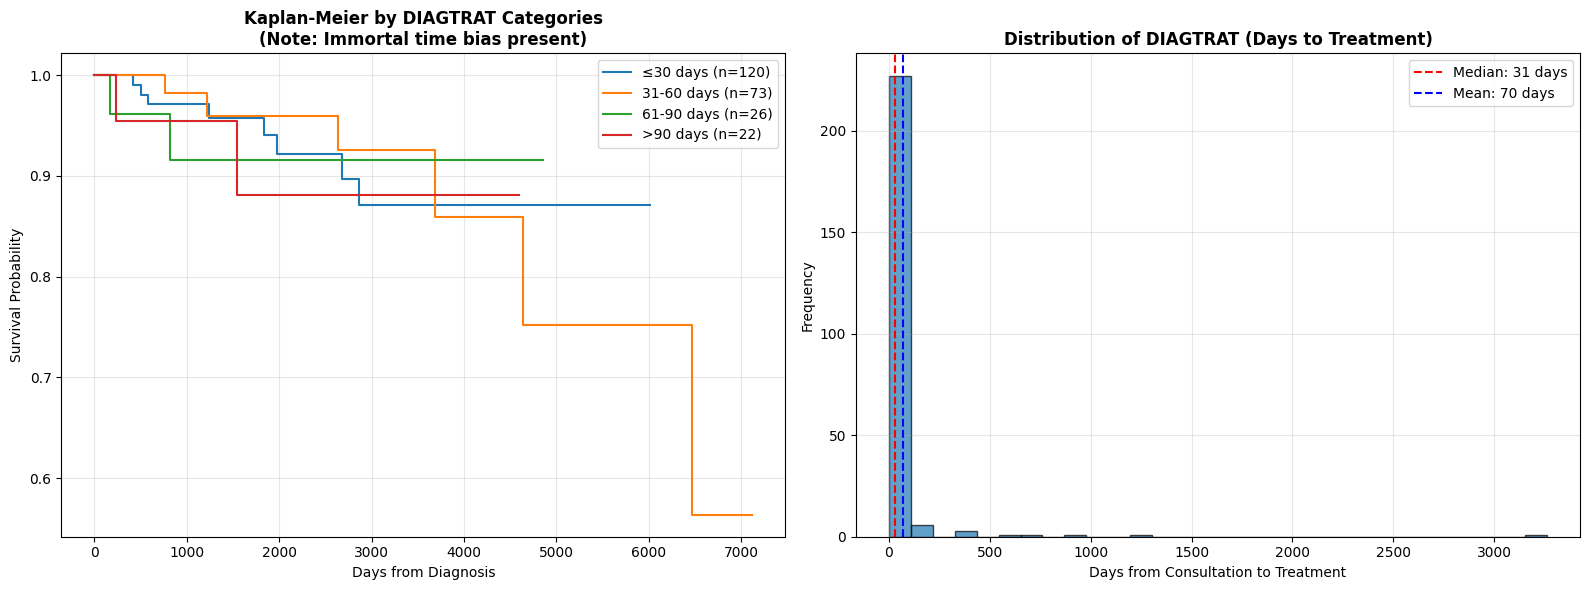


=== APPROACH 3: ADJUSTED MODEL (Excluding Immortal Time) ===
Patients in adjusted model: 236

Adjusted Model Summary (excluding immortal time):
DIAGTRAT coefficient: 0.0022
DIAGTRAT p-value: 0.4571
DIAGTRAT Hazard Ratio: 1.0022
Model C-index: 0.8900


<lifelines.CoxPHFitter: fitted with 236 total observations, 219 right-censored observations>
             duration col = 'FOLLOW_DAYS_ADJUSTED'
                event col = 'ULTINFO_TREAT'
      baseline estimation = breslow
   number of observations = 236
number of events observed = 17
   partial log-likelihood = -57.78
         time fit was run = 2025-12-05 17:29:07 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
IDADE               0.08      1.08      0.03            0.02            0.13                1.02                1.14
SEXO                0.98      2.66      1.15           -1.27            3.23                0.28               25.35
CIRURGIA           -2.85      0.06      0.84           -4.49           -1.21                0.01                0.30
RADIO              -2.46      0.09      0.78           -3.98           -0.94                0.02                0.39
OUTROS_TRATAMENTOS  2.00      7.39      1.03           -0.01            4.01                0.99               55.20
RECNENHUM          -2.75      0.06      0.61           -3.94           -1.55                0.02                0.21
TRATCONS            0.00      1.00      0.00           -0.00            0.01                1.00                1.01
DIAGTRAT            0.00      1.00      0.00           -0.00            0.01                1.00                1.01

                    cmp to     z      p  -log2(p)
covariate                                        
IDADE                 0.00  2.80   0.01      7.62
SEXO                  0.00  0.85   0.39      1.34
CIRURGIA              0.00 -3.41 <0.005     10.57
RADIO                 0.00 -3.18 <0.005      9.40
OUTROS_TRATAMENTOS    0.00  1.95   0.05      4.29
RECNENHUM             0.00 -4.52 <0.005     17.27
TRATCONS              0.00  1.53   0.13      2.97
DIAGTRAT              0.00  0.74   0.46      1.13
---
Concordance = 0.89
Partial AIC = 131.56
log-likelihood ratio test = 38.63 on 8 df
-log2(p) of ll-ratio test = 17.41


=== COMPARISON: Standard vs Landmark Models ===

Standard Model (with immortal time bias):
Patients: 241
DIAGTRAT coefficient: -0.0005
DIAGTRAT p-value: 0.5562
DIAGTRAT Hazard Ratio: 0.9995
Model C-index: 0.8416

=== COMPARISON TABLE ===
                            Model    N  DIAGTRAT_Coef  DIAGTRAT_P  \
0               Standard (biased)  241        -0.0005      0.5562   
1  Adjusted (excl. immortal time)  236         0.0022      0.4571   
2                    Landmark 30d  238        -0.0005      0.5562   
3                    Landmark 60d  236        -0.0005      0.5562   
4                    Landmark 90d  233        -0.0005      0.5562   

   DIAGTRAT_HR  C_index  
0       0.9995   0.8416  
1       1.0022   0.8900  
2       0.9995   0.8416  
3       0.9995   0.8416  
4       0.9995   0.8416  


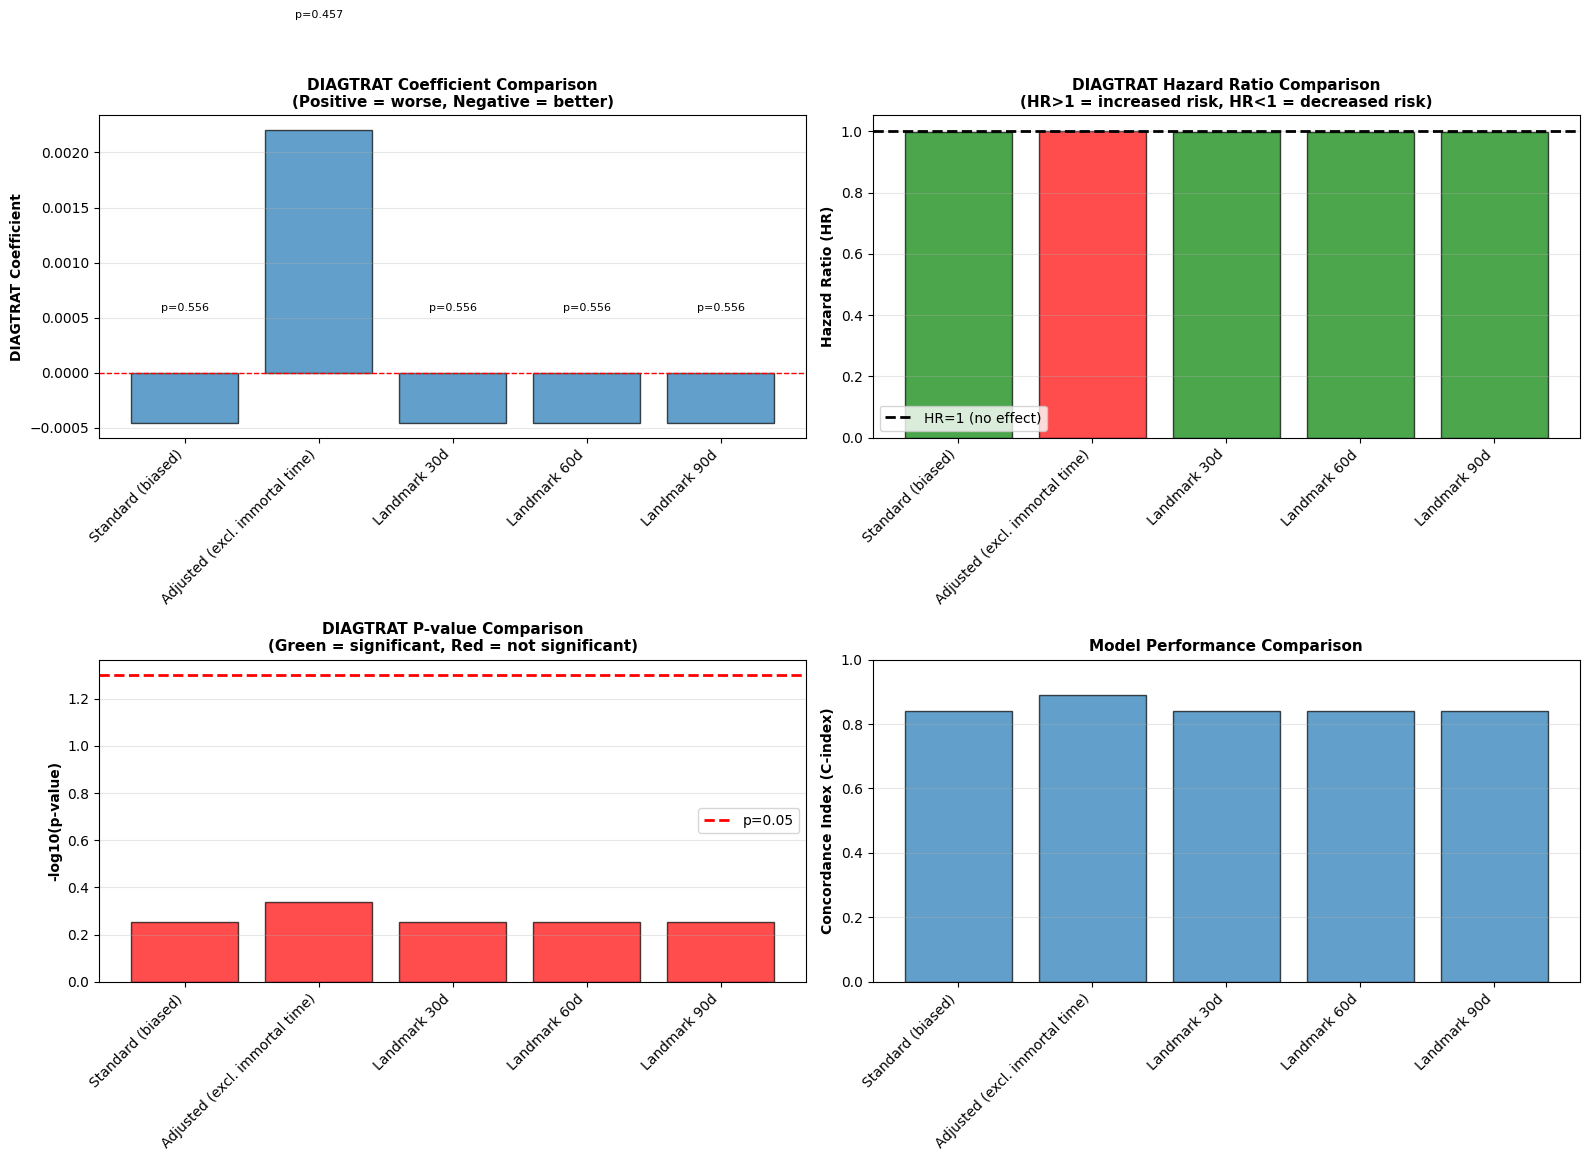


=== INTERPRETATION ===

IMMORTAL TIME BIAS EXPLANATION:
- DIAGTRAT = days from consultation to treatment
- Patients with longer DIAGTRAT have a period where they cannot die (immortal time)
- This creates bias: longer wait times appear protective when they're not

APPROACHES TO HANDLE IT:
1. Landmark Analysis: Start follow-up at fixed time points (30, 60, 90 days)
   - Removes immortal time period
   - Only includes patients who survived to landmark

2. Adjusted Model: Subtract DIAGTRAT from follow-up time
   - Accounts for immortal time in follow-up calculation

3. Standard Model: Includes immortal time (BIASED)
   - Shows the effect of immortal time bias
   - Compare with adjusted models to see the difference

INTERPRETATION:
- Positive coefficient/HR>1: Longer wait time (DIAGTRAT) increases risk (worse)
- Negative coefficient/HR<1: Longer wait time decreases risk (better) - may indicate bias
- Compare standard vs landmark models to assess bias magnitude



In [50]:
# DIAGTRAT Analysis with Immortal Time Bias Handling
# DIAGTRAT = days from consultation (DTCONSULT) to treatment (DTTRAT)
# Immortal time bias: Patients with longer DIAGTRAT have a period where they cannot die
# (they are "immortal" until they receive treatment)

print("=== DIAGTRAT ANALYSIS WITH IMMORTAL TIME BIAS HANDLING ===\n")

# Prepare data similar to previous analysis
df_diagtrat = df_all.copy()

# Create other treatments variable
others_treatments = ["QUIMIO", "HORMONIO", "TMO", "IMUNO", "OUTROS"]
df_diagtrat["OUTROS_TRATAMENTOS"] = df_diagtrat[others_treatments].any(axis=1).astype(int)

# Filter same as previous analysis
df_diagtrat = df_diagtrat[df_diagtrat['ECGRUP'].isin(['I'])]
df_diagtrat = df_diagtrat[df_diagtrat['DSCINST'] == "HOSP AC CAMARGO"]

# Create dummy variables for attend categories
df_diagtrat["CONVENIO"] = df_diagtrat["CATEATEND"].map(lambda x: 1 if x == 1 else 0)
df_diagtrat["SUS"] = df_diagtrat["CATEATEND"].map(lambda x: 1 if x == 2 else 0)
df_diagtrat["PARTICULAR"] = df_diagtrat["CATEATEND"].map(lambda x: 1 if x == 3 else 0)

# Ensure DIAGTRAT is available and numeric
df_diagtrat["DIAGTRAT"] = pd.to_numeric(df_diagtrat["DIAGTRAT"], errors='coerce')

# Remove missing DIAGTRAT
df_diagtrat = df_diagtrat.dropna(subset=["DIAGTRAT", "FOLLOW_DAYS", "ULTINFO_TREAT"])

print(f"Total patients: {len(df_diagtrat)}")
print(f"DIAGTRAT statistics:")
print(df_diagtrat["DIAGTRAT"].describe())
print(f"\nDIAGTRAT range: {df_diagtrat['DIAGTRAT'].min():.0f} to {df_diagtrat['DIAGTRAT'].max():.0f} days")

# Create DIAGTRAT categories for visualization
df_diagtrat["DIAGTRAT_CAT"] = pd.cut(df_diagtrat["DIAGTRAT"], 
                                      bins=[-np.inf, 30, 60, 90, np.inf],
                                      labels=["≤30 days", "31-60 days", "61-90 days", ">90 days"])

# ============================================================================
# APPROACH 1: LANDMARK ANALYSIS
# Start follow-up at a fixed landmark time (e.g., 30, 60, 90 days after consultation)
# This removes the immortal time period
# ============================================================================

print("\n=== APPROACH 1: LANDMARK ANALYSIS ===")

landmark_times = [30, 60, 90]
landmark_results = []

for landmark in landmark_times:
    print(f"\n--- Landmark at {landmark} days ---")
    
    # Create landmark dataset: only include patients who survived to landmark time
    # Adjust follow-up time to start from landmark
    df_landmark = df_diagtrat.copy()
    df_landmark["FOLLOW_DAYS_LANDMARK"] = df_landmark["FOLLOW_DAYS"] - landmark
    
    # Only include patients who survived to landmark (or had event after landmark)
    df_landmark = df_landmark[df_landmark["FOLLOW_DAYS"] >= landmark]
    df_landmark = df_landmark[df_landmark["FOLLOW_DAYS_LANDMARK"] > 0]
    
    # Adjust event indicator: if event happened before landmark, set to censored
    df_landmark["ULTINFO_TREAT_LANDMARK"] = df_landmark.apply(
        lambda row: 0 if (row["FOLLOW_DAYS"] < landmark and row["ULTINFO_TREAT"] == 1) 
        else row["ULTINFO_TREAT"], axis=1
    )
    
    print(f"Patients included: {len(df_landmark)}")
    
    if len(df_landmark) < 10:
        print("Too few patients for analysis")
        continue
    
    # Variables for Cox model
    variables_landmark = ["IDADE", "SEXO", "CIRURGIA", "RADIO", "OUTROS_TRATAMENTOS", 
                         "RECNENHUM", "TRATCONS", "DIAGTRAT"]
    
    df_model_landmark = df_landmark[["FOLLOW_DAYS_LANDMARK", "ULTINFO_TREAT_LANDMARK"] + variables_landmark].copy()
    df_model_landmark = df_model_landmark.dropna()
    
    if len(df_model_landmark) < 10:
        print("Too few patients after removing missing values")
        continue
    
    # Fit Cox model
    try:
        cph_landmark = CoxPHFitter()
        cph_landmark.fit(df_model_landmark, duration_col="FOLLOW_DAYS_LANDMARK", 
                        event_col="ULTINFO_TREAT_LANDMARK")
        
        # Get DIAGTRAT coefficient
        if "DIAGTRAT" in cph_landmark.summary.index:
            diagtrat_coef = cph_landmark.summary.loc["DIAGTRAT", "coef"]
            diagtrat_p = cph_landmark.summary.loc["DIAGTRAT", "p"]
            diagtrat_hr = np.exp(diagtrat_coef)
            ci = cph_landmark.concordance_index_
            
            print(f"DIAGTRAT coefficient: {diagtrat_coef:.4f}")
            print(f"DIAGTRAT p-value: {diagtrat_p:.4f}")
            print(f"DIAGTRAT Hazard Ratio: {diagtrat_hr:.4f}")
            print(f"Model C-index: {ci:.4f}")
            
            landmark_results.append({
                'landmark': landmark,
                'n': len(df_model_landmark),
                'coef': diagtrat_coef,
                'p': diagtrat_p,
                'hr': diagtrat_hr,
                'ci': ci,
                'model': cph_landmark
            })
        else:
            print("DIAGTRAT not in model summary")
    except Exception as e:
        print(f"Error fitting model: {e}")

# ============================================================================
# APPROACH 2: STRATIFIED ANALYSIS BY DIAGTRAT CATEGORIES
# Compare survival between groups with different wait times
# ============================================================================

print("\n=== APPROACH 2: STRATIFIED ANALYSIS BY DIAGTRAT CATEGORIES ===")

# Kaplan-Meier by DIAGTRAT categories
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

kmf = KaplanMeierFitter()

# Plot 1: KM curves by DIAGTRAT categories
ax1 = axes[0]
for category in df_diagtrat["DIAGTRAT_CAT"].cat.categories:
    mask = df_diagtrat["DIAGTRAT_CAT"] == category
    n = mask.sum()
    if n > 0:
        kmf.fit(df_diagtrat[mask]["FOLLOW_DAYS"], 
               event_observed=df_diagtrat[mask]["ULTINFO_TREAT"],
               label=f"{category} (n={n})")
        kmf.plot(ax=ax1, ci_show=False)

ax1.set_title("Kaplan-Meier by DIAGTRAT Categories\n(Note: Immortal time bias present)", 
              fontsize=12, fontweight='bold')
ax1.set_xlabel("Days from Diagnosis", fontsize=10)
ax1.set_ylabel("Survival Probability", fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: DIAGTRAT distribution
ax2 = axes[1]
df_diagtrat["DIAGTRAT"].hist(bins=30, ax=ax2, edgecolor='black', alpha=0.7)
ax2.axvline(df_diagtrat["DIAGTRAT"].median(), color='red', linestyle='--', 
           label=f'Median: {df_diagtrat["DIAGTRAT"].median():.0f} days')
ax2.axvline(df_diagtrat["DIAGTRAT"].mean(), color='blue', linestyle='--', 
           label=f'Mean: {df_diagtrat["DIAGTRAT"].mean():.0f} days')
ax2.set_title("Distribution of DIAGTRAT (Days to Treatment)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Days from Consultation to Treatment", fontsize=10)
ax2.set_ylabel("Frequency", fontsize=10)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# APPROACH 3: TIME-DEPENDENT COVARIATE (Simplified)
# Treat DIAGTRAT as a baseline covariate but adjust for immortal time
# ============================================================================

print("\n=== APPROACH 3: ADJUSTED MODEL (Excluding Immortal Time) ===")

# Create adjusted follow-up: subtract DIAGTRAT from follow-up time
# This accounts for the fact that patients can't die during the wait period
df_adjusted = df_diagtrat.copy()
df_adjusted["FOLLOW_DAYS_ADJUSTED"] = df_adjusted["FOLLOW_DAYS"] - df_adjusted["DIAGTRAT"]
df_adjusted = df_adjusted[df_adjusted["FOLLOW_DAYS_ADJUSTED"] > 0]

# If event happened before treatment, it's impossible (set to censored at treatment time)
# Actually, if FOLLOW_DAYS < DIAGTRAT, the event happened during wait time (shouldn't happen)
# But we'll keep it as is and let the model handle it

variables_adj = ["IDADE", "SEXO", "CIRURGIA", "RADIO", "OUTROS_TRATAMENTOS", 
                "RECNENHUM", "TRATCONS", "DIAGTRAT"]

df_model_adj = df_adjusted[["FOLLOW_DAYS_ADJUSTED", "ULTINFO_TREAT"] + variables_adj].copy()
df_model_adj = df_model_adj.dropna()

print(f"Patients in adjusted model: {len(df_model_adj)}")

if len(df_model_adj) >= 10:
    try:
        cph_adjusted = CoxPHFitter()
        cph_adjusted.fit(df_model_adj, duration_col="FOLLOW_DAYS_ADJUSTED", 
                        event_col="ULTINFO_TREAT")
        
        print("\nAdjusted Model Summary (excluding immortal time):")
        if "DIAGTRAT" in cph_adjusted.summary.index:
            diagtrat_coef_adj = cph_adjusted.summary.loc["DIAGTRAT", "coef"]
            diagtrat_p_adj = cph_adjusted.summary.loc["DIAGTRAT", "p"]
            diagtrat_hr_adj = np.exp(diagtrat_coef_adj)
            
            print(f"DIAGTRAT coefficient: {diagtrat_coef_adj:.4f}")
            print(f"DIAGTRAT p-value: {diagtrat_p_adj:.4f}")
            print(f"DIAGTRAT Hazard Ratio: {diagtrat_hr_adj:.4f}")
            print(f"Model C-index: {cph_adjusted.concordance_index_:.4f}")
            
            cph_adjusted.print_summary()
        else:
            print("DIAGTRAT not in model")
    except Exception as e:
        print(f"Error: {e}")

# ============================================================================
# COMPARISON: Standard model vs Landmark models
# ============================================================================

print("\n=== COMPARISON: Standard vs Landmark Models ===")

# Fit standard model (with immortal time bias)
variables_std = ["IDADE", "SEXO", "CIRURGIA", "RADIO", "OUTROS_TRATAMENTOS", 
                "RECNENHUM", "TRATCONS", "DIAGTRAT"]

df_model_std = df_diagtrat[["FOLLOW_DAYS", "ULTINFO_TREAT"] + variables_std].copy()
df_model_std = df_model_std.dropna()

print(f"\nStandard Model (with immortal time bias):")
print(f"Patients: {len(df_model_std)}")

if len(df_model_std) >= 10:
    try:
        cph_standard = CoxPHFitter()
        cph_standard.fit(df_model_std, duration_col="FOLLOW_DAYS", event_col="ULTINFO_TREAT")
        
        if "DIAGTRAT" in cph_standard.summary.index:
            std_coef = cph_standard.summary.loc["DIAGTRAT", "coef"]
            std_p = cph_standard.summary.loc["DIAGTRAT", "p"]
            std_hr = np.exp(std_coef)
            std_ci = cph_standard.concordance_index_
            
            print(f"DIAGTRAT coefficient: {std_coef:.4f}")
            print(f"DIAGTRAT p-value: {std_p:.4f}")
            print(f"DIAGTRAT Hazard Ratio: {std_hr:.4f}")
            print(f"Model C-index: {std_ci:.4f}")
            
            # Create comparison table
            comparison_df = pd.DataFrame({
                'Model': ['Standard (biased)', 'Adjusted (excl. immortal time)'] + 
                        [f'Landmark {r["landmark"]}d' for r in landmark_results],
                'N': [len(df_model_std), len(df_model_adj)] + [r['n'] for r in landmark_results],
                'DIAGTRAT_Coef': [std_coef, diagtrat_coef_adj if 'diagtrat_coef_adj' in locals() else np.nan] + 
                                [r['coef'] for r in landmark_results],
                'DIAGTRAT_P': [std_p, diagtrat_p_adj if 'diagtrat_p_adj' in locals() else np.nan] + 
                             [r['p'] for r in landmark_results],
                'DIAGTRAT_HR': [std_hr, diagtrat_hr_adj if 'diagtrat_hr_adj' in locals() else np.nan] + 
                              [r['hr'] for r in landmark_results],
                'C_index': [std_ci, cph_adjusted.concordance_index_ if 'cph_adjusted' in locals() else np.nan] + 
                          [r['ci'] for r in landmark_results]
            })
            
            print("\n=== COMPARISON TABLE ===")
            print(comparison_df.round(4))
            
            # Visualization
            fig, axes = plt.subplots(2, 2, figsize=(16, 12))
            
            # Plot 1: Coefficient comparison
            ax1 = axes[0, 0]
            x_pos = np.arange(len(comparison_df))
            bars = ax1.bar(x_pos, comparison_df['DIAGTRAT_Coef'], alpha=0.7, edgecolor='black')
            ax1.axhline(y=0, color='red', linestyle='--', linewidth=1)
            ax1.set_xticks(x_pos)
            ax1.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
            ax1.set_ylabel('DIAGTRAT Coefficient', fontsize=10, fontweight='bold')
            ax1.set_title('DIAGTRAT Coefficient Comparison\n(Positive = worse, Negative = better)', 
                         fontsize=11, fontweight='bold')
            ax1.grid(True, alpha=0.3, axis='y')
            
            # Add p-value annotations
            for i, (idx, row) in enumerate(comparison_df.iterrows()):
                if not pd.isna(row['DIAGTRAT_P']):
                    sig = '*' if row['DIAGTRAT_P'] < 0.05 else ''
                    ax1.text(i, row['DIAGTRAT_Coef'] + 0.001, f'p={row["DIAGTRAT_P"]:.3f}{sig}', 
                            ha='center', va='bottom', fontsize=8)
            
            # Plot 2: Hazard Ratio comparison
            ax2 = axes[0, 1]
            bars = ax2.bar(x_pos, comparison_df['DIAGTRAT_HR'], alpha=0.7, edgecolor='black', 
                          color=['red' if hr > 1 else 'green' for hr in comparison_df['DIAGTRAT_HR']])
            ax2.axhline(y=1, color='black', linestyle='--', linewidth=2, label='HR=1 (no effect)')
            ax2.set_xticks(x_pos)
            ax2.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
            ax2.set_ylabel('Hazard Ratio (HR)', fontsize=10, fontweight='bold')
            ax2.set_title('DIAGTRAT Hazard Ratio Comparison\n(HR>1 = increased risk, HR<1 = decreased risk)', 
                         fontsize=11, fontweight='bold')
            ax2.legend()
            ax2.grid(True, alpha=0.3, axis='y')
            
            # Plot 3: P-value comparison
            ax3 = axes[1, 0]
            bars = ax3.bar(x_pos, -np.log10(comparison_df['DIAGTRAT_P']), alpha=0.7, edgecolor='black',
                          color=['green' if p < 0.05 else 'red' for p in comparison_df['DIAGTRAT_P']])
            ax3.axhline(y=-np.log10(0.05), color='red', linestyle='--', linewidth=2, label='p=0.05')
            ax3.set_xticks(x_pos)
            ax3.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
            ax3.set_ylabel('-log10(p-value)', fontsize=10, fontweight='bold')
            ax3.set_title('DIAGTRAT P-value Comparison\n(Green = significant, Red = not significant)', 
                         fontsize=11, fontweight='bold')
            ax3.legend()
            ax3.grid(True, alpha=0.3, axis='y')
            
            # Plot 4: C-index comparison
            ax4 = axes[1, 1]
            bars = ax4.bar(x_pos, comparison_df['C_index'], alpha=0.7, edgecolor='black')
            ax4.set_xticks(x_pos)
            ax4.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
            ax4.set_ylabel('Concordance Index (C-index)', fontsize=10, fontweight='bold')
            ax4.set_title('Model Performance Comparison', fontsize=11, fontweight='bold')
            ax4.set_ylim([0, 1])
            ax4.grid(True, alpha=0.3, axis='y')
            
            plt.tight_layout()
            plt.show()
            
        else:
            print("DIAGTRAT not in standard model")
    except Exception as e:
        print(f"Error fitting standard model: {e}")

print("\n=== INTERPRETATION ===")
print("""
IMMORTAL TIME BIAS EXPLANATION:
- DIAGTRAT = days from consultation to treatment
- Patients with longer DIAGTRAT have a period where they cannot die (immortal time)
- This creates bias: longer wait times appear protective when they're not

APPROACHES TO HANDLE IT:
1. Landmark Analysis: Start follow-up at fixed time points (30, 60, 90 days)
   - Removes immortal time period
   - Only includes patients who survived to landmark
   
2. Adjusted Model: Subtract DIAGTRAT from follow-up time
   - Accounts for immortal time in follow-up calculation
   
3. Standard Model: Includes immortal time (BIASED)
   - Shows the effect of immortal time bias
   - Compare with adjusted models to see the difference

INTERPRETATION:
- Positive coefficient/HR>1: Longer wait time (DIAGTRAT) increases risk (worse)
- Negative coefficient/HR<1: Longer wait time decreases risk (better) - may indicate bias
- Compare standard vs landmark models to assess bias magnitude
""")



=== DETAILED VISUALIZATION ===


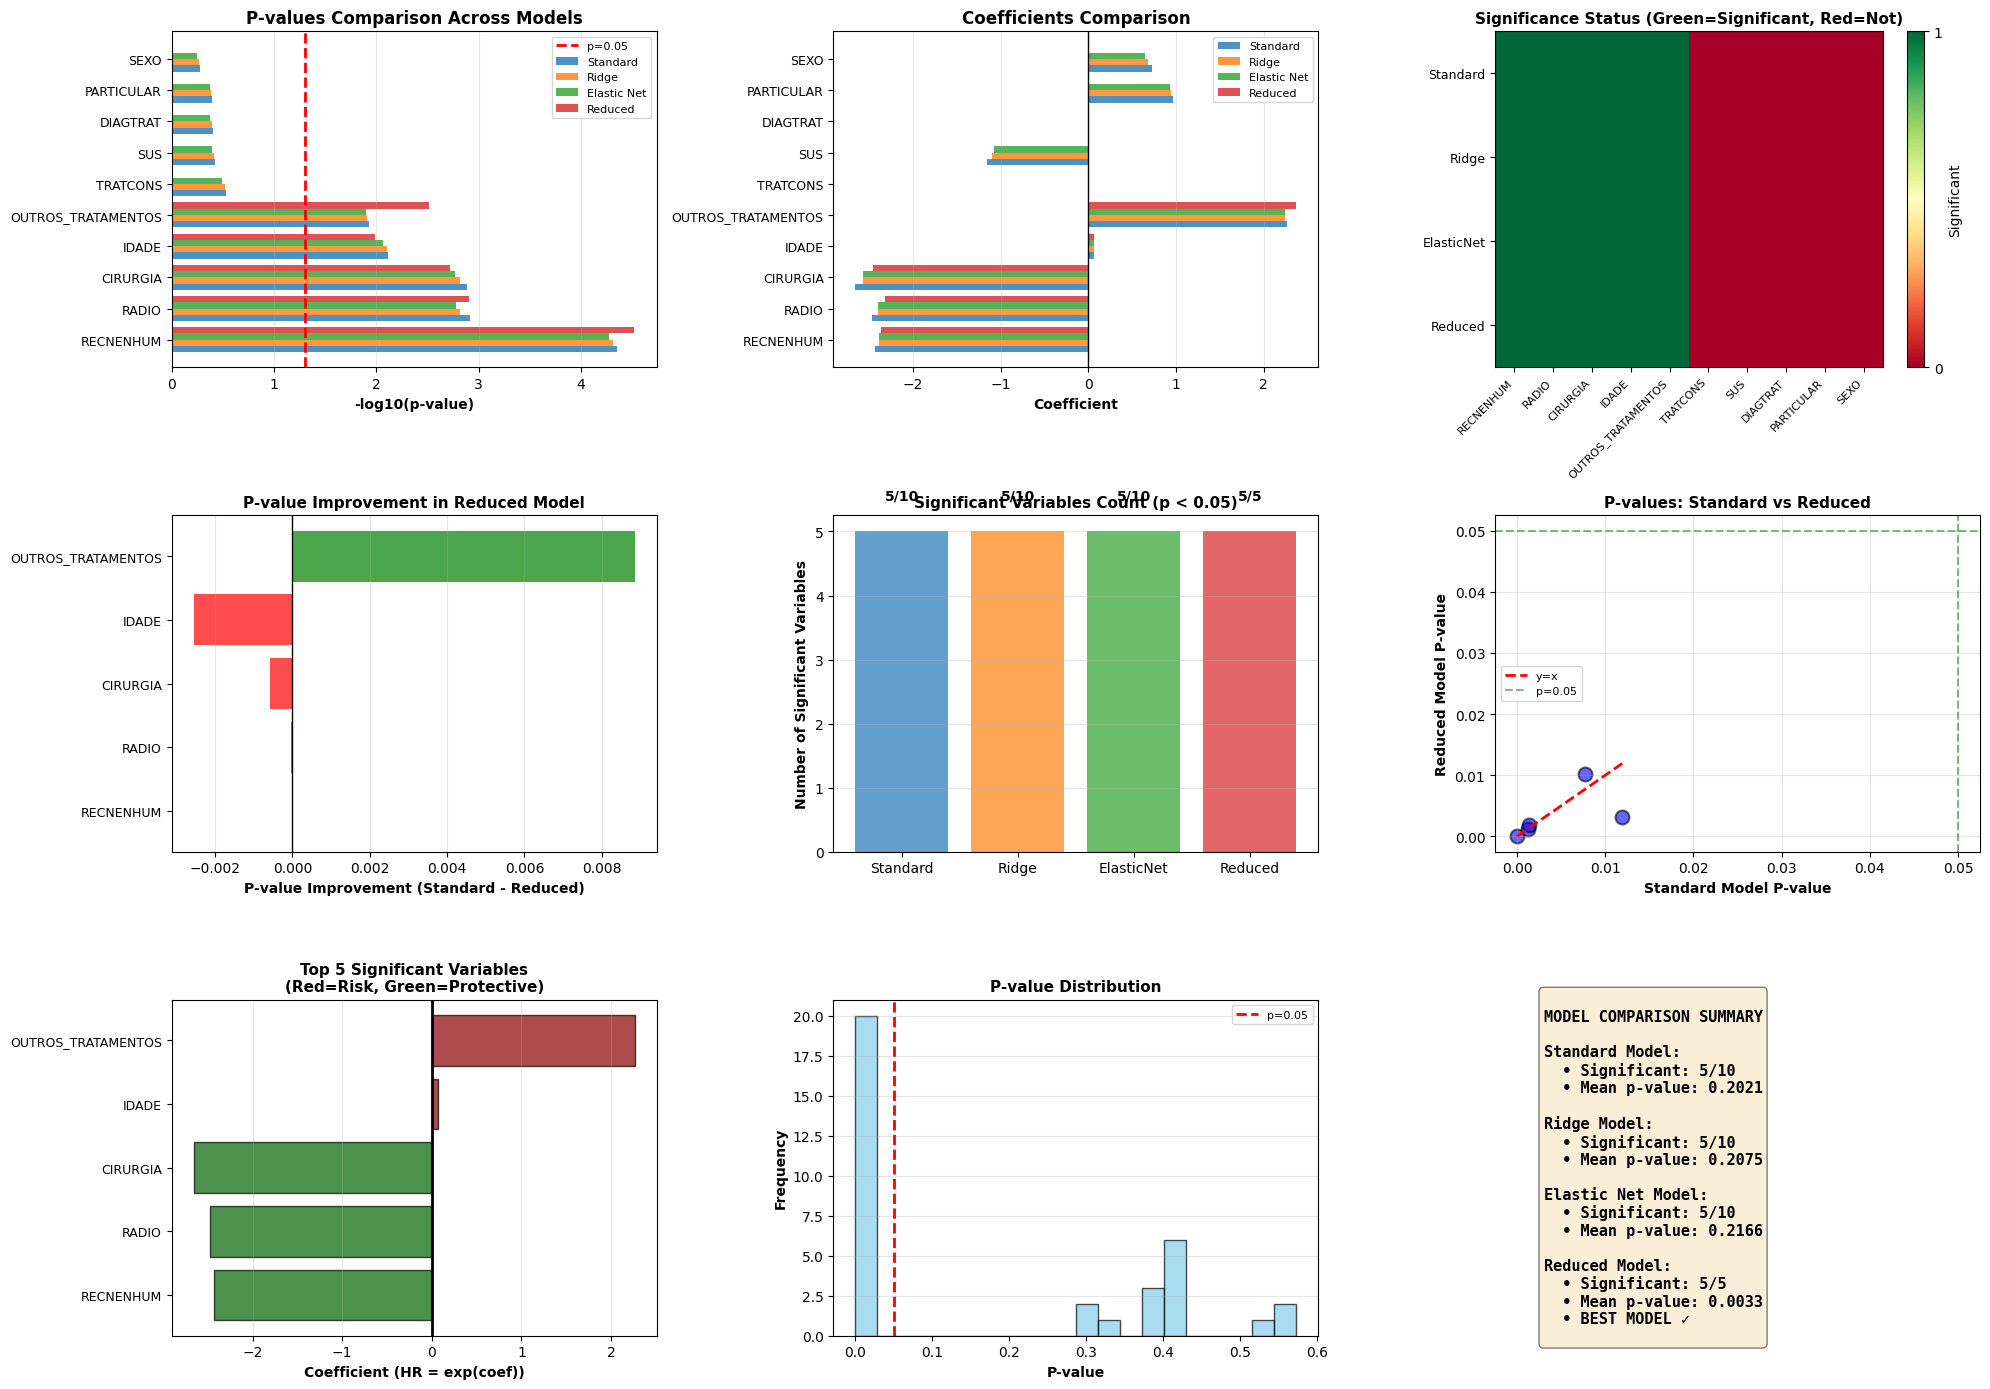

In [49]:

# Enhanced Visualization of Results
print("\n=== DETAILED VISUALIZATION ===")

# Create comprehensive plots
fig = plt.figure(figsize=(20, 14))

# 1. P-values Comparison (Bar Chart)
ax1 = plt.subplot(3, 3, 1)
comparison_sorted = comparison.sort_values('Standard_P', ascending=True)
x_pos = np.arange(len(comparison_sorted))
width = 0.2

bars1 = ax1.barh(x_pos - 1.5*width, -np.log10(comparison_sorted['Standard_P']), width, 
                 label='Standard', alpha=0.8, color='#1f77b4')
bars2 = ax1.barh(x_pos - 0.5*width, -np.log10(comparison_sorted['Ridge_P']), width, 
                 label='Ridge', alpha=0.8, color='#ff7f0e')
bars3 = ax1.barh(x_pos + 0.5*width, -np.log10(comparison_sorted['ElasticNet_P']), width, 
                 label='Elastic Net', alpha=0.8, color='#2ca02c')
if 'Reduced_P' in comparison_sorted.columns:
    reduced_data = -np.log10(comparison_sorted['Reduced_P'].fillna(1))
    bars4 = ax1.barh(x_pos + 1.5*width, reduced_data, width, 
                     label='Reduced', alpha=0.8, color='#d62728')

ax1.axvline(x=-np.log10(0.05), color='red', linestyle='--', linewidth=2, label='p=0.05')
ax1.set_yticks(x_pos)
ax1.set_yticklabels(comparison_sorted['Variable'], fontsize=9)
ax1.set_xlabel('-log10(p-value)', fontsize=10, fontweight='bold')
ax1.set_title('P-values Comparison Across Models', fontsize=12, fontweight='bold')
ax1.legend(loc='best', fontsize=8)
ax1.grid(True, alpha=0.3, axis='x')

# 2. Coefficients Comparison
ax2 = plt.subplot(3, 3, 2)
bars1 = ax2.barh(x_pos - 1.5*width, comparison_sorted['Standard_Coef'], width, 
                 label='Standard', alpha=0.8, color='#1f77b4')
bars2 = ax2.barh(x_pos - 0.5*width, comparison_sorted['Ridge_Coef'], width, 
                 label='Ridge', alpha=0.8, color='#ff7f0e')
bars3 = ax2.barh(x_pos + 0.5*width, comparison_sorted['ElasticNet_Coef'], width, 
                 label='Elastic Net', alpha=0.8, color='#2ca02c')
if 'Reduced_Coef' in comparison_sorted.columns:
    reduced_coef = comparison_sorted['Reduced_Coef'].fillna(0)
    bars4 = ax2.barh(x_pos + 1.5*width, reduced_coef, width, 
                     label='Reduced', alpha=0.8, color='#d62728')

ax2.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax2.set_yticks(x_pos)
ax2.set_yticklabels(comparison_sorted['Variable'], fontsize=9)
ax2.set_xlabel('Coefficient', fontsize=10, fontweight='bold')
ax2.set_title('Coefficients Comparison', fontsize=12, fontweight='bold')
ax2.legend(loc='best', fontsize=8)
ax2.grid(True, alpha=0.3, axis='x')

# 3. Significance Status Heatmap
ax3 = plt.subplot(3, 3, 3)
sig_data = pd.DataFrame({
    'Standard': comparison_sorted['Standard_P'] < 0.05,
    'Ridge': comparison_sorted['Ridge_P'] < 0.05,
    'ElasticNet': comparison_sorted['ElasticNet_P'] < 0.05
})
if 'Reduced_P' in comparison_sorted.columns:
    sig_data['Reduced'] = comparison_sorted['Reduced_P'] < 0.05

im = ax3.imshow(sig_data.astype(int).T, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax3.set_xticks(range(len(comparison_sorted)))
ax3.set_xticklabels(comparison_sorted['Variable'], rotation=45, ha='right', fontsize=8)
ax3.set_yticks(range(len(sig_data.columns)))
ax3.set_yticklabels(sig_data.columns, fontsize=9)
ax3.set_title('Significance Status (Green=Significant, Red=Not)', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax3, ticks=[0, 1], label='Significant')

# 4. P-value Improvement (Standard vs Reduced)
ax4 = plt.subplot(3, 3, 4)
if 'Reduced_P' in comparison_sorted.columns:
    reduced_vars = comparison_sorted['Reduced_P'].notna()
    improvement = comparison_sorted.loc[reduced_vars, 'Standard_P'] - comparison_sorted.loc[reduced_vars, 'Reduced_P']
    vars_reduced = comparison_sorted.loc[reduced_vars, 'Variable']
    
    colors = ['green' if imp > 0 else 'red' for imp in improvement]
    ax4.barh(range(len(vars_reduced)), improvement, color=colors, alpha=0.7)
    ax4.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax4.set_yticks(range(len(vars_reduced)))
    ax4.set_yticklabels(vars_reduced, fontsize=9)
    ax4.set_xlabel('P-value Improvement (Standard - Reduced)', fontsize=10, fontweight='bold')
    ax4.set_title('P-value Improvement in Reduced Model', fontsize=11, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='x')

# 5. Model Comparison Summary
ax5 = plt.subplot(3, 3, 5)
models = ['Standard', 'Ridge', 'ElasticNet']
if 'Reduced_P' in comparison_sorted.columns:
    models.append('Reduced')
    
sig_counts = [
    (comparison_sorted['Standard_P'] < 0.05).sum(),
    (comparison_sorted['Ridge_P'] < 0.05).sum(),
    (comparison_sorted['ElasticNet_P'] < 0.05).sum()
]
if 'Reduced_P' in comparison_sorted.columns:
    sig_counts.append((comparison_sorted['Reduced_P'] < 0.05).sum())

total_vars = [len(comparison_sorted)] * 3
if 'Reduced_P' in comparison_sorted.columns:
    total_vars.append(comparison_sorted['Reduced_P'].notna().sum())

x = np.arange(len(models))
ax5.bar(x, sig_counts, alpha=0.7, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'][:len(models)])
ax5.set_xticks(x)
ax5.set_xticklabels(models, fontsize=10)
ax5.set_ylabel('Number of Significant Variables', fontsize=10, fontweight='bold')
ax5.set_title('Significant Variables Count (p < 0.05)', fontsize=11, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='y')
for i, (count, total) in enumerate(zip(sig_counts, total_vars)):
    ax5.text(i, count + 0.5, f'{count}/{total}', ha='center', fontsize=10, fontweight='bold')

# 6. P-values Scatter: Standard vs Reduced
ax6 = plt.subplot(3, 3, 6)
if 'Reduced_P' in comparison_sorted.columns:
    reduced_mask = comparison_sorted['Reduced_P'].notna()
    ax6.scatter(comparison_sorted.loc[reduced_mask, 'Standard_P'], 
                comparison_sorted.loc[reduced_mask, 'Reduced_P'],
                s=100, alpha=0.6, color='blue', edgecolors='black', linewidth=1.5)
    # Add diagonal line
    max_val = max(comparison_sorted.loc[reduced_mask, 'Standard_P'].max(),
                  comparison_sorted.loc[reduced_mask, 'Reduced_P'].max())
    ax6.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='y=x')
    # Add significance threshold lines
    ax6.axhline(y=0.05, color='green', linestyle='--', alpha=0.5, label='p=0.05')
    ax6.axvline(x=0.05, color='green', linestyle='--', alpha=0.5)
    ax6.set_xlabel('Standard Model P-value', fontsize=10, fontweight='bold')
    ax6.set_ylabel('Reduced Model P-value', fontsize=10, fontweight='bold')
    ax6.set_title('P-values: Standard vs Reduced', fontsize=11, fontweight='bold')
    ax6.legend(fontsize=8)
    ax6.grid(True, alpha=0.3)

# 7. Top Significant Variables (Forest Plot Style)
ax7 = plt.subplot(3, 3, 7)
top_vars = comparison_sorted[comparison_sorted['Standard_P'] < 0.05].head(5)
y_pos = np.arange(len(top_vars))
colors_forest = ['darkgreen' if coef < 0 else 'darkred' for coef in top_vars['Standard_Coef']]
ax7.barh(y_pos, top_vars['Standard_Coef'], color=colors_forest, alpha=0.7, edgecolor='black')
ax7.set_yticks(y_pos)
ax7.set_yticklabels(top_vars['Variable'], fontsize=9)
ax7.axvline(x=0, color='black', linestyle='-', linewidth=2)
ax7.set_xlabel('Coefficient (HR = exp(coef))', fontsize=10, fontweight='bold')
ax7.set_title('Top 5 Significant Variables\n(Red=Risk, Green=Protective)', fontsize=11, fontweight='bold')
ax7.grid(True, alpha=0.3, axis='x')

# 8. P-value Distribution
ax8 = plt.subplot(3, 3, 8)
p_values_all = pd.concat([
    comparison_sorted['Standard_P'],
    comparison_sorted['Ridge_P'],
    comparison_sorted['ElasticNet_P']
], ignore_index=True)
if 'Reduced_P' in comparison_sorted.columns:
    p_values_all = pd.concat([p_values_all, comparison_sorted['Reduced_P'].dropna()], ignore_index=True)

ax8.hist(p_values_all, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
ax8.axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='p=0.05')
ax8.set_xlabel('P-value', fontsize=10, fontweight='bold')
ax8.set_ylabel('Frequency', fontsize=10, fontweight='bold')
ax8.set_title('P-value Distribution', fontsize=11, fontweight='bold')
ax8.legend(fontsize=8)
ax8.grid(True, alpha=0.3, axis='y')

# 9. Summary Statistics Table
ax9 = plt.subplot(3, 3, 9)
ax9.axis('off')
summary_text = f"""
MODEL COMPARISON SUMMARY

Standard Model:
  • Significant: {(comparison_sorted['Standard_P'] < 0.05).sum()}/{len(comparison_sorted)}
  • Mean p-value: {comparison_sorted['Standard_P'].mean():.4f}

Ridge Model:
  • Significant: {(comparison_sorted['Ridge_P'] < 0.05).sum()}/{len(comparison_sorted)}
  • Mean p-value: {comparison_sorted['Ridge_P'].mean():.4f}

Elastic Net Model:
  • Significant: {(comparison_sorted['ElasticNet_P'] < 0.05).sum()}/{len(comparison_sorted)}
  • Mean p-value: {comparison_sorted['ElasticNet_P'].mean():.4f}
"""
if 'Reduced_P' in comparison_sorted.columns:
    reduced_count = (comparison_sorted['Reduced_P'] < 0.05).sum()
    reduced_total = comparison_sorted['Reduced_P'].notna().sum()
    reduced_mean = comparison_sorted['Reduced_P'].mean()
    summary_text += f"""
Reduced Model:
  • Significant: {reduced_count}/{reduced_total}
  • Mean p-value: {reduced_mean:.4f}
  • BEST MODEL ✓
"""
ax9.text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
         verticalalignment='center', fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

### Random Survival Forest


=== MULTI-MODEL RANDOM SURVIVAL FOREST COMPARISON ===

=== STANDARD RANDOM SURVIVAL FOREST (All Variables) ===
Standard Model - Concordance Index: 0.8773
Standard Model - Variables: 8

=== REDUCED RANDOM SURVIVAL FOREST ===
Reduced Model - Using top 5 variables: ['RECNENHUM', 'DIAGTRAT', 'IDADE', 'RADIO', 'TRATCONS']
Reduced Model - Concordance Index: 0.8815
Reduced Model - Variables: 5

=== ALTERNATIVE RANDOM SURVIVAL FOREST (Different Hyperparameters) ===
Alternative Model - Concordance Index: 0.9098
Alternative Model - Variables: 8

=== MODEL COMPARISON ===
Standard Model CI: 0.8773
Reduced Model CI: 0.8815
Alternative Model CI: 0.9098


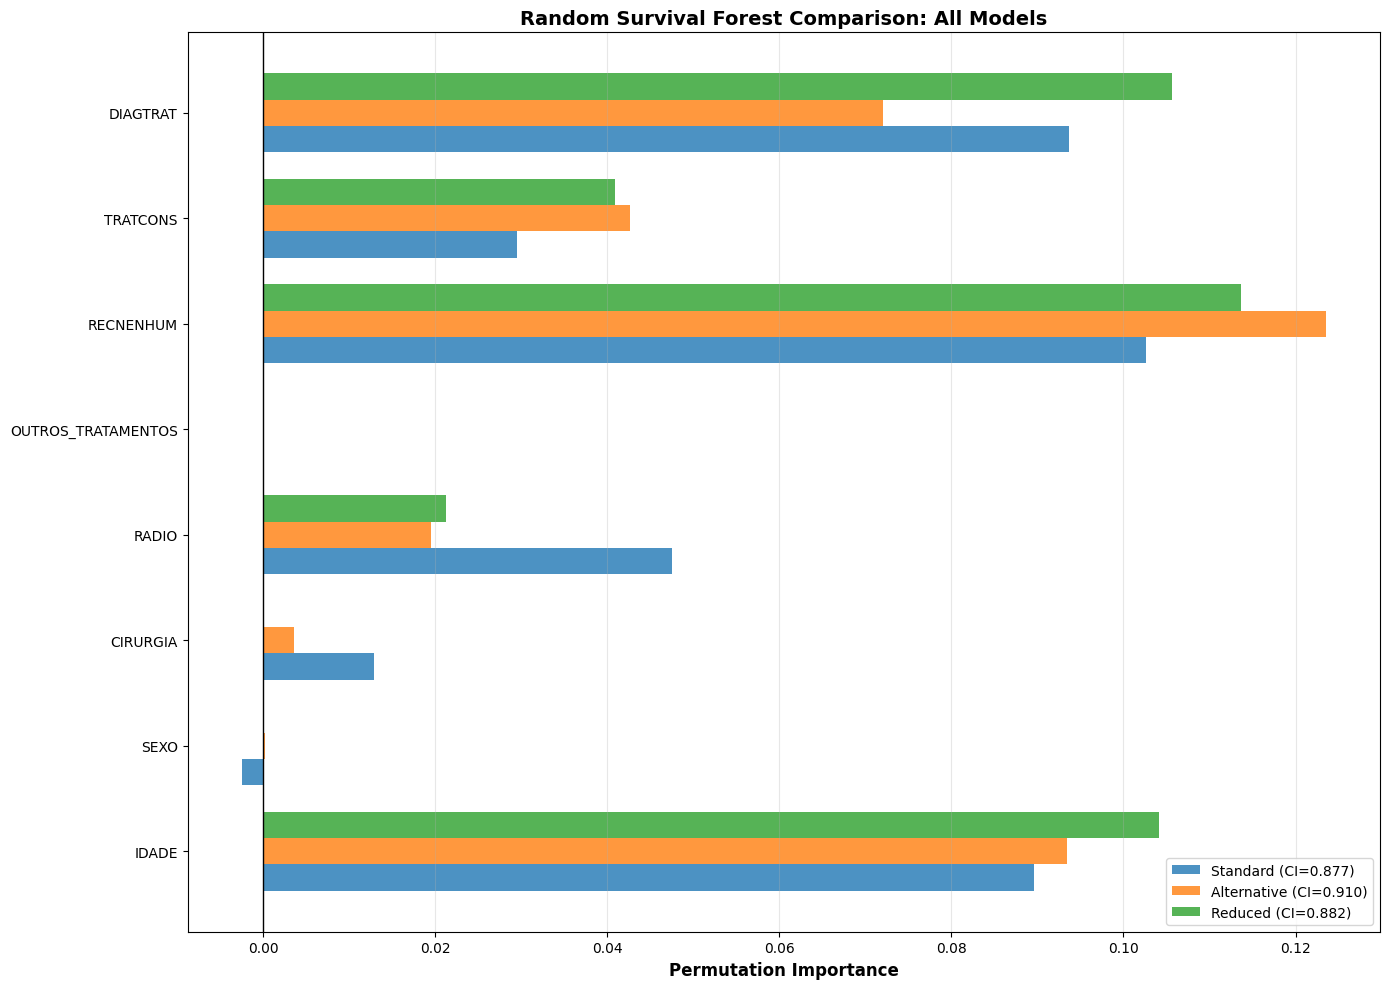


=== SUMMARY ===
Best Model: Alternative
Best CI: 0.9098

=== COX-STYLE RISK DIRECTION ANALYSIS ===
Calculating risk directions...


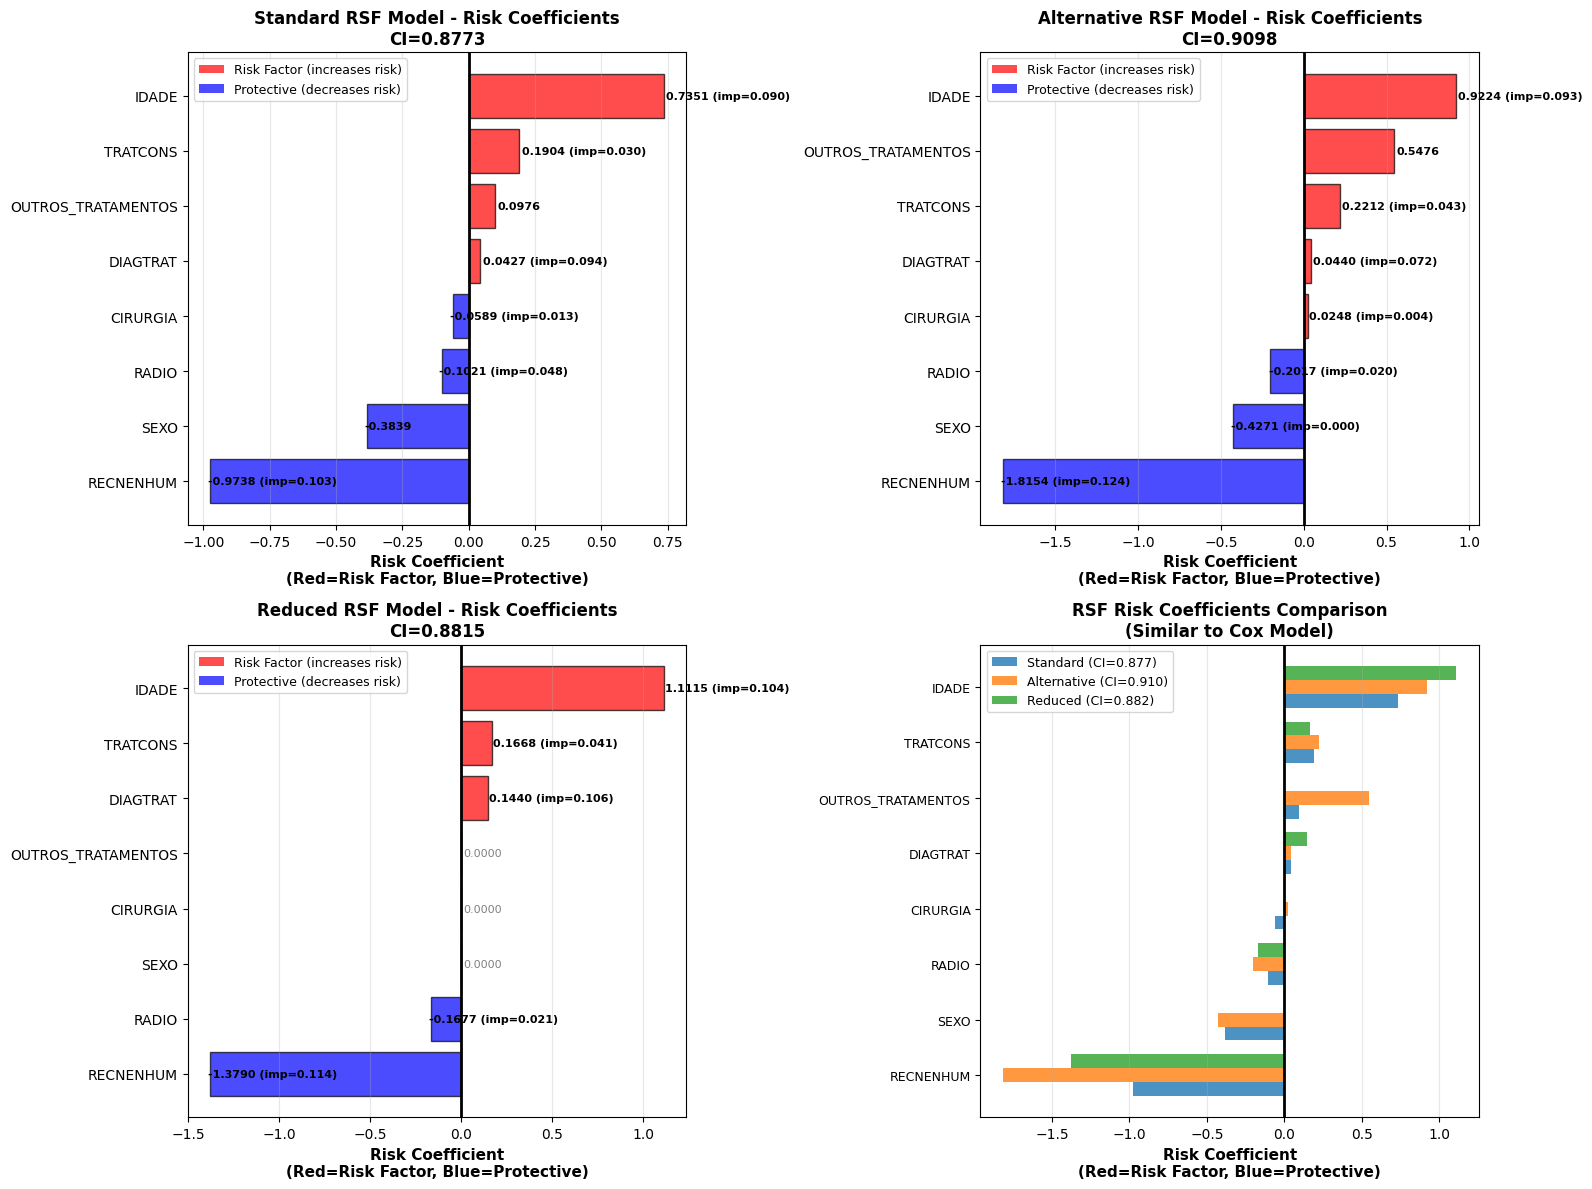


=== RISK COEFFICIENTS SUMMARY (Similar to Cox Model) ===

Positive values = Risk Factor (increases risk)
Negative values = Protective Factor (decreases risk)

Risk Coefficients:
                    Standard_Risk  Alternative_Risk  Reduced_Risk
IDADE                      0.7351            0.9224        1.1115
SEXO                      -0.3839           -0.4271        0.0000
CIRURGIA                  -0.0589            0.0248        0.0000
RADIO                     -0.1021           -0.2017       -0.1677
OUTROS_TRATAMENTOS         0.0976            0.5476        0.0000
RECNENHUM                 -0.9738           -1.8154       -1.3790
TRATCONS                   0.1904            0.2212        0.1668
DIAGTRAT                   0.0427            0.0440        0.1440


In [45]:
# Multi-Model Random Survival Forest (Similar to Cox Model Approach)
print("\n=== MULTI-MODEL RANDOM SURVIVAL FOREST COMPARISON ===")

# Prepare data (ensure X and y are defined)
X = df_model_dummy[variables]
y = Surv.from_dataframe("ULTINFO_TREAT", "FOLLOW_DAYS", df_model_dummy)

# Helper function for permutation importance
def rsf_score(model, X, y):
    pred = model.predict(X)
    ci = concordance_index_censored(y["ULTINFO_TREAT"], y["FOLLOW_DAYS"], pred)
    return ci[0]  # Concordance index

# ----------------------
# STANDARD MODEL: All variables
# ----------------------
print("\n=== STANDARD RANDOM SURVIVAL FOREST (All Variables) ===")
rsf_standard = RandomSurvivalForest(
    n_estimators=100,
    min_samples_split=10,
    min_samples_leaf=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)
rsf_standard.fit(X, y)

result_standard = permutation_importance(
    rsf_standard, X, y, n_repeats=10, random_state=42, scoring=rsf_score
)
ci_standard = rsf_score(rsf_standard, X, y)
print(f"Standard Model - Concordance Index: {ci_standard:.4f}")
print(f"Standard Model - Variables: {len(variables)}")

# ----------------------
# REDUCED MODEL: Top 5 most important variables
# ----------------------
print("\n=== REDUCED RANDOM SURVIVAL FOREST ===")
# Get top 5 most important variables from standard model
importance_df = pd.DataFrame({
    'Variable': X.columns,
    'Importance': result_standard.importances_mean
}).sort_values('Importance', ascending=False)

sig_vars_rsf = importance_df.head(5)['Variable'].tolist()
print(f"Reduced Model - Using top 5 variables: {sig_vars_rsf}")

X_reduced = df_model_dummy[sig_vars_rsf]
y_reduced = Surv.from_dataframe("ULTINFO_TREAT", "FOLLOW_DAYS", df_model_dummy)

rsf_reduced = RandomSurvivalForest(
    n_estimators=100,
    min_samples_split=10,
    min_samples_leaf=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)
rsf_reduced.fit(X_reduced, y_reduced)

result_reduced = permutation_importance(
    rsf_reduced, X_reduced, y_reduced, n_repeats=10, random_state=42, scoring=rsf_score
)
ci_reduced = rsf_score(rsf_reduced, X_reduced, y_reduced)
print(f"Reduced Model - Concordance Index: {ci_reduced:.4f}")
print(f"Reduced Model - Variables: {len(sig_vars_rsf)}")

# ----------------------
# ALTERNATIVE MODEL: Different hyperparameters
# ----------------------
print("\n=== ALTERNATIVE RANDOM SURVIVAL FOREST (Different Hyperparameters) ===")
rsf_alt = RandomSurvivalForest(
    n_estimators=200,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features="log2",
    n_jobs=-1,
    random_state=42
)
rsf_alt.fit(X, y)

result_alt = permutation_importance(
    rsf_alt, X, y, n_repeats=10, random_state=42, scoring=rsf_score
)
ci_alt = rsf_score(rsf_alt, X, y)
print(f"Alternative Model - Concordance Index: {ci_alt:.4f}")
print(f"Alternative Model - Variables: {len(variables)}")

# ----------------------
# COMPARISON AND COMBINED PLOT
# ----------------------
print("\n=== MODEL COMPARISON ===")
print(f"Standard Model CI: {ci_standard:.4f}")
print(f"Reduced Model CI: {ci_reduced:.4f}")
print(f"Alternative Model CI: {ci_alt:.4f}")

# Create comparison dataframe
comparison_rsf = pd.DataFrame(index=variables)
comparison_rsf['Standard_Importance'] = result_standard.importances_mean
comparison_rsf['Alternative_Importance'] = result_alt.importances_mean
comparison_rsf['Reduced_Importance'] = 0.0

# Map reduced model importances (result_reduced.importances_mean is a numpy array)
# Match by position in sig_vars_rsf
for idx, var in enumerate(sig_vars_rsf):
    if var in comparison_rsf.index:
        comparison_rsf.loc[var, 'Reduced_Importance'] = result_reduced.importances_mean[idx]

# Combined Plot: All Random Survival Forest Models
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

y_pos = np.arange(len(variables))
width = 0.25

# Standard Model
bars1 = ax.barh(y_pos - width, comparison_rsf['Standard_Importance'], width, 
                label=f'Standard (CI={ci_standard:.3f})', alpha=0.8, color='#1f77b4')

# Alternative Model
bars2 = ax.barh(y_pos, comparison_rsf['Alternative_Importance'], width, 
                label=f'Alternative (CI={ci_alt:.3f})', alpha=0.8, color='#ff7f0e')

# Reduced Model
bars3 = ax.barh(y_pos + width, comparison_rsf['Reduced_Importance'], width, 
                label=f'Reduced (CI={ci_reduced:.3f})', alpha=0.8, color='#2ca02c')

ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(variables, fontsize=10)
ax.set_xlabel('Permutation Importance', fontsize=12, fontweight='bold')
ax.set_title('Random Survival Forest Comparison: All Models', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print(f"\n=== SUMMARY ===")
best_ci = max(ci_standard, ci_reduced, ci_alt)
best_model = 'Standard' if ci_standard == best_ci else 'Reduced' if ci_reduced == best_ci else 'Alternative'
print(f"Best Model: {best_model}")
print(f"Best CI: {best_ci:.4f}")

# ----------------------
# COX-STYLE PLOT: Risk Direction Analysis
# ----------------------
print("\n=== COX-STYLE RISK DIRECTION ANALYSIS ===")

def calculate_risk_direction(model, X, y, variables):
    """
    Calculate risk direction for each variable (similar to Cox coefficients)
    Positive = risk factor (increases risk), Negative = protective (decreases risk)
    """
    # Get baseline predictions
    baseline_pred = model.predict(X)
    
    # Calculate correlation between each variable and predicted risk
    risk_directions = {}
    
    for var in variables:
        if var in X.columns:
            # Calculate correlation between variable and predicted risk
            # Higher correlation = risk factor, lower/negative = protective
            corr = np.corrcoef(X[var].values, baseline_pred)[0, 1]
            
            # Also calculate mean difference: high vs low values
            # For binary variables: compare 1 vs 0
            # For continuous: compare high (top quartile) vs low (bottom quartile)
            if X[var].nunique() <= 2:  # Binary variable
                if X[var].nunique() == 2:
                    high_risk = baseline_pred[X[var] == X[var].max()].mean()
                    low_risk = baseline_pred[X[var] == X[var].min()].mean()
                    risk_diff = high_risk - low_risk
                else:
                    risk_diff = 0  # No variation
            else:  # Continuous variable
                q75 = X[var].quantile(0.75)
                q25 = X[var].quantile(0.25)
                if q75 > q25:  # Check if there's variation
                    high_risk = baseline_pred[X[var] >= q75].mean()
                    low_risk = baseline_pred[X[var] <= q25].mean()
                    risk_diff = high_risk - low_risk
                else:
                    risk_diff = 0  # No variation
            
            # Use the difference as the "coefficient" (scaled by importance)
            risk_directions[var] = risk_diff
    
    return risk_directions

# Calculate risk directions for each model
print("Calculating risk directions...")
risk_dir_standard = calculate_risk_direction(rsf_standard, X, y, variables)
risk_dir_alt = calculate_risk_direction(rsf_alt, X, y, variables)
risk_dir_reduced = calculate_risk_direction(rsf_reduced, X_reduced, y_reduced, sig_vars_rsf)

# Create comparison dataframe with risk coefficients (similar to Cox)
risk_comparison = pd.DataFrame(index=variables)
risk_comparison['Standard_Risk'] = [risk_dir_standard.get(var, 0) for var in variables]
risk_comparison['Alternative_Risk'] = [risk_dir_alt.get(var, 0) for var in variables]
risk_comparison['Reduced_Risk'] = [risk_dir_reduced.get(var, 0) if var in sig_vars_rsf else 0 for var in variables]

# Add importance values
risk_comparison['Standard_Importance'] = result_standard.importances_mean
risk_comparison['Alternative_Importance'] = result_alt.importances_mean
risk_comparison['Reduced_Importance'] = [result_reduced.importances_mean[sig_vars_rsf.index(var)] if var in sig_vars_rsf and var in X_reduced.columns else 0 for var in variables]

# Create Cox-style plots for each model
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

def plot_rsf_coefficients(ax, risk_coefs, importances, variables, title, ci_value):
    """Plot RSF risk coefficients similar to Cox model plot"""
    # Sort by coefficient value
    df_plot = pd.DataFrame({
        'Variable': variables,
        'Risk_Coefficient': risk_coefs,
        'Importance': importances
    }).sort_values('Risk_Coefficient', ascending=True)
    
    y_pos = np.arange(len(df_plot))
    
    # Color bars: red for risk factors (positive), blue for protective (negative)
    colors = ['red' if coef > 0 else 'blue' for coef in df_plot['Risk_Coefficient']]
    
    bars = ax.barh(y_pos, df_plot['Risk_Coefficient'], color=colors, alpha=0.7, edgecolor='black')
    
    # Add importance as text annotation
    for i, (idx, row) in enumerate(df_plot.iterrows()):
        imp_text = f" (imp={row['Importance']:.3f})" if row['Importance'] > 0 else ""
        ax.text(row['Risk_Coefficient'] + (0.01 if row['Risk_Coefficient'] >= 0 else -0.01), 
                i, f"{row['Risk_Coefficient']:.4f}{imp_text}", 
                va='center', fontsize=8, 
                color='black' if abs(row['Risk_Coefficient']) > 0.01 else 'gray',
                fontweight='bold' if abs(row['Risk_Coefficient']) > 0.01 else 'normal')
    
    ax.axvline(x=0, color='black', linestyle='-', linewidth=2)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_plot['Variable'], fontsize=10)
    ax.set_xlabel('Risk Coefficient\n(Red=Risk Factor, Blue=Protective)', fontsize=11, fontweight='bold')
    ax.set_title(f"{title}\nCI={ci_value:.4f}", fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='red', alpha=0.7, label='Risk Factor (increases risk)'),
        Patch(facecolor='blue', alpha=0.7, label='Protective (decreases risk)')
    ]
    ax.legend(handles=legend_elements, loc='best', fontsize=9)

# Plot each model
plot_rsf_coefficients(axes[0, 0], 
                     risk_comparison['Standard_Risk'].values,
                     risk_comparison['Standard_Importance'].values,
                     variables,
                     'Standard RSF Model - Risk Coefficients',
                     ci_standard)

plot_rsf_coefficients(axes[0, 1],
                     risk_comparison['Alternative_Risk'].values,
                     risk_comparison['Alternative_Importance'].values,
                     variables,
                     'Alternative RSF Model - Risk Coefficients',
                     ci_alt)

plot_rsf_coefficients(axes[1, 0],
                     risk_comparison['Reduced_Risk'].values,
                     risk_comparison['Reduced_Importance'].values,
                     variables,
                     'Reduced RSF Model - Risk Coefficients',
                     ci_reduced)

# Combined comparison plot
ax_combined = axes[1, 1]
y_pos = np.arange(len(variables))
width = 0.25

# Sort by standard risk coefficient
sorted_idx = risk_comparison.sort_values('Standard_Risk', ascending=True).index
risk_comparison_sorted = risk_comparison.loc[sorted_idx]

bars1 = ax_combined.barh(y_pos - width, risk_comparison_sorted['Standard_Risk'], width,
                         label=f'Standard (CI={ci_standard:.3f})', alpha=0.8, color='#1f77b4')
bars2 = ax_combined.barh(y_pos, risk_comparison_sorted['Alternative_Risk'], width,
                         label=f'Alternative (CI={ci_alt:.3f})', alpha=0.8, color='#ff7f0e')
bars3 = ax_combined.barh(y_pos + width, risk_comparison_sorted['Reduced_Risk'], width,
                         label=f'Reduced (CI={ci_reduced:.3f})', alpha=0.8, color='#2ca02c')

ax_combined.axvline(x=0, color='black', linestyle='-', linewidth=2)
ax_combined.set_yticks(y_pos)
ax_combined.set_yticklabels(sorted_idx, fontsize=9)
ax_combined.set_xlabel('Risk Coefficient\n(Red=Risk Factor, Blue=Protective)', fontsize=11, fontweight='bold')
ax_combined.set_title('RSF Risk Coefficients Comparison\n(Similar to Cox Model)', fontsize=12, fontweight='bold')
ax_combined.legend(loc='best', fontsize=9)
ax_combined.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Print summary table
print("\n=== RISK COEFFICIENTS SUMMARY (Similar to Cox Model) ===")
print("\nPositive values = Risk Factor (increases risk)")
print("Negative values = Protective Factor (decreases risk)")
print("\nRisk Coefficients:")
print(risk_comparison[['Standard_Risk', 'Alternative_Risk', 'Reduced_Risk']].round(4))


###Gradient Boosting Survival



=== GRADIENT BOOSTING SURVIVAL FOREST ===

=== GRADIENT BOOSTING SURVIVAL (All Variables) ===
Gradient Boosting - Concordance Index: 0.9272
Gradient Boosting - Variables: 8

Top 5 Most Important Variables (Gradient Boosting):
    Variable  Importance
0      IDADE    0.293171
7   DIAGTRAT    0.237030
5  RECNENHUM    0.230833
6   TRATCONS    0.186274
3      RADIO    0.036733

=== REDUCED GRADIENT BOOSTING (Top 5 Variables) ===
Using top 5 variables: ['IDADE', 'DIAGTRAT', 'RECNENHUM', 'TRATCONS', 'RADIO']
Reduced Gradient Boosting - Concordance Index: 0.9225

=== GRADIENT BOOSTING RISK DIRECTION ANALYSIS ===


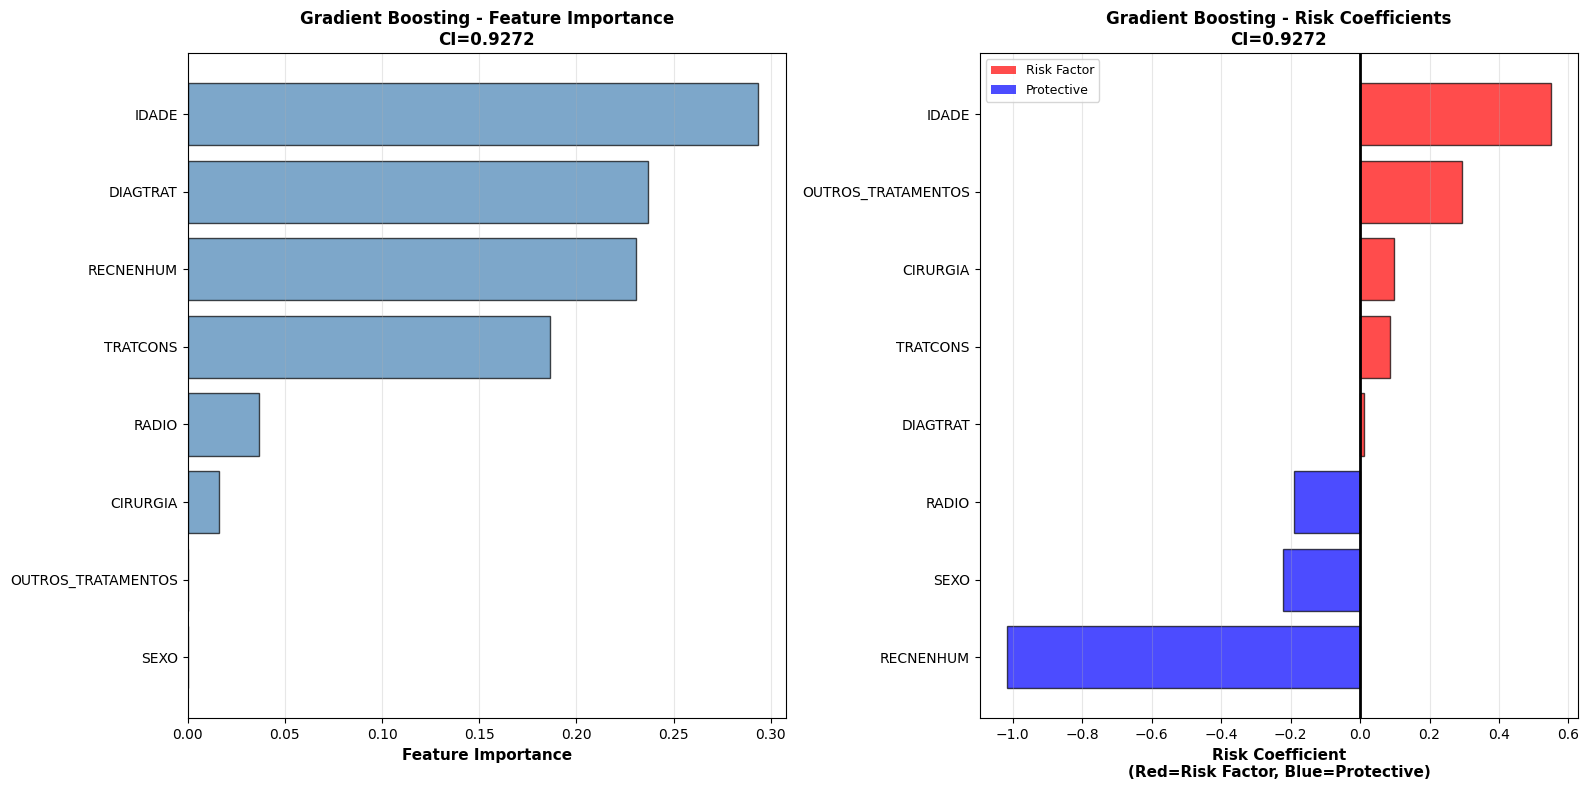


=== ALL MODELS COMPARISON ===
Standard RSF CI: 0.8773
Alternative RSF CI: 0.9098
Reduced RSF CI: 0.8815
Gradient Boosting CI: 0.9272
Reduced Gradient Boosting CI: 0.9225

=== RISK COEFFICIENTS COMPARISON ===
                    GBS_Risk  GBS_Importance
IDADE                 0.5496          0.2932
SEXO                 -0.2211          0.0000
CIRURGIA              0.0982          0.0160
RADIO                -0.1901          0.0367
OUTROS_TRATAMENTOS    0.2929          0.0000
RECNENHUM            -1.0171          0.2308
TRATCONS              0.0856          0.1863
DIAGTRAT              0.0109          0.2370


In [47]:
# Additional Survival Models Comparison
# Gradient Boosting Survival - Uses boosting instead of bagging (complements RSF)

print("\n=== GRADIENT BOOSTING SURVIVAL FOREST ===")

try:
    from sksurv.ensemble import GradientBoostingSurvivalAnalysis
    
    # Prepare data (using same X and y from RSF analysis)
    # X and y should already be defined from previous cell
    
    # ----------------------
    # GRADIENT BOOSTING MODEL
    # ----------------------
    print("\n=== GRADIENT BOOSTING SURVIVAL (All Variables) ===")
    gbs = GradientBoostingSurvivalAnalysis(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=15,
        subsample=0.8,
        random_state=42
    )
    gbs.fit(X, y)
    
    # Calculate concordance index
    pred_gbs = gbs.predict(X)
    ci_gbs = concordance_index_censored(y["ULTINFO_TREAT"], y["FOLLOW_DAYS"], pred_gbs)[0]
    print(f"Gradient Boosting - Concordance Index: {ci_gbs:.4f}")
    print(f"Gradient Boosting - Variables: {len(variables)}")
    
    # Feature importance
    gbs_importance = gbs.feature_importances_
    importance_df_gbs = pd.DataFrame({
        'Variable': X.columns,
        'Importance': gbs_importance
    }).sort_values('Importance', ascending=False)
    
    print("\nTop 5 Most Important Variables (Gradient Boosting):")
    print(importance_df_gbs.head(5))
    
    # ----------------------
    # REDUCED GRADIENT BOOSTING MODEL
    # ----------------------
    print("\n=== REDUCED GRADIENT BOOSTING (Top 5 Variables) ===")
    top5_vars_gbs = importance_df_gbs.head(5)['Variable'].tolist()
    print(f"Using top 5 variables: {top5_vars_gbs}")
    
    X_reduced_gbs = df_model_dummy[top5_vars_gbs]
    y_reduced_gbs = Surv.from_dataframe("ULTINFO_TREAT", "FOLLOW_DAYS", df_model_dummy)
    
    gbs_reduced = GradientBoostingSurvivalAnalysis(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=15,
        subsample=0.8,
        random_state=42
    )
    gbs_reduced.fit(X_reduced_gbs, y_reduced_gbs)
    
    pred_gbs_reduced = gbs_reduced.predict(X_reduced_gbs)
    ci_gbs_reduced = concordance_index_censored(y_reduced_gbs["ULTINFO_TREAT"], 
                                                 y_reduced_gbs["FOLLOW_DAYS"], 
                                                 pred_gbs_reduced)[0]
    print(f"Reduced Gradient Boosting - Concordance Index: {ci_gbs_reduced:.4f}")
    
    # ----------------------
    # RISK DIRECTION ANALYSIS (Similar to Cox)
    # ----------------------
    print("\n=== GRADIENT BOOSTING RISK DIRECTION ANALYSIS ===")
    
    def calculate_gbs_risk_direction(model, X, y, variables):
        """Calculate risk direction for Gradient Boosting model"""
        baseline_pred = model.predict(X)
        risk_directions = {}
        
        for var in variables:
            if var in X.columns:
                if X[var].nunique() <= 2:
                    if X[var].nunique() == 2:
                        high_risk = baseline_pred[X[var] == X[var].max()].mean()
                        low_risk = baseline_pred[X[var] == X[var].min()].mean()
                        risk_directions[var] = high_risk - low_risk
                    else:
                        risk_directions[var] = 0
                else:
                    q75 = X[var].quantile(0.75)
                    q25 = X[var].quantile(0.25)
                    if q75 > q25:
                        high_risk = baseline_pred[X[var] >= q75].mean()
                        low_risk = baseline_pred[X[var] <= q25].mean()
                        risk_directions[var] = high_risk - low_risk
                    else:
                        risk_directions[var] = 0
        
        return risk_directions
    
    risk_dir_gbs = calculate_gbs_risk_direction(gbs, X, y, variables)
    risk_dir_gbs_reduced = calculate_gbs_risk_direction(gbs_reduced, X_reduced_gbs, y_reduced_gbs, top5_vars_gbs)
    
    # Create comparison dataframe
    gbs_comparison = pd.DataFrame(index=variables)
    gbs_comparison['GBS_Risk'] = [risk_dir_gbs.get(var, 0) for var in variables]
    gbs_comparison['GBS_Reduced_Risk'] = [risk_dir_gbs_reduced.get(var, 0) if var in top5_vars_gbs else 0 for var in variables]
    gbs_comparison['GBS_Importance'] = [gbs_importance[list(X.columns).index(var)] if var in X.columns else 0 for var in variables]
    
    # ----------------------
    # PLOT COMPARISON
    # ----------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Plot 1: Feature Importance
    ax1 = axes[0]
    sorted_idx = gbs_comparison.sort_values('GBS_Importance', ascending=True).index
    y_pos = np.arange(len(variables))
    
    bars = ax1.barh(y_pos, gbs_comparison.loc[sorted_idx, 'GBS_Importance'], 
                   color='steelblue', alpha=0.7, edgecolor='black')
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(sorted_idx, fontsize=10)
    ax1.set_xlabel('Feature Importance', fontsize=11, fontweight='bold')
    ax1.set_title(f'Gradient Boosting - Feature Importance\nCI={ci_gbs:.4f}', 
                  fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='x')
    
    # Plot 2: Risk Coefficients (Cox-style)
    ax2 = axes[1]
    sorted_risk = gbs_comparison.sort_values('GBS_Risk', ascending=True).index
    y_pos2 = np.arange(len(variables))
    
    colors = ['red' if coef > 0 else 'blue' for coef in gbs_comparison.loc[sorted_risk, 'GBS_Risk']]
    bars2 = ax2.barh(y_pos2, gbs_comparison.loc[sorted_risk, 'GBS_Risk'], 
                    color=colors, alpha=0.7, edgecolor='black')
    
    ax2.axvline(x=0, color='black', linestyle='-', linewidth=2)
    ax2.set_yticks(y_pos2)
    ax2.set_yticklabels(sorted_risk, fontsize=10)
    ax2.set_xlabel('Risk Coefficient\n(Red=Risk Factor, Blue=Protective)', 
                   fontsize=11, fontweight='bold')
    ax2.set_title(f'Gradient Boosting - Risk Coefficients\nCI={ci_gbs:.4f}', 
                  fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='x')
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='red', alpha=0.7, label='Risk Factor'),
        Patch(facecolor='blue', alpha=0.7, label='Protective')
    ]
    ax2.legend(handles=legend_elements, loc='best', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # ----------------------
    # MODEL COMPARISON SUMMARY
    # ----------------------
    print("\n=== ALL MODELS COMPARISON ===")
    print(f"Standard RSF CI: {ci_standard:.4f}")
    print(f"Alternative RSF CI: {ci_alt:.4f}")
    print(f"Reduced RSF CI: {ci_reduced:.4f}")
    print(f"Gradient Boosting CI: {ci_gbs:.4f}")
    print(f"Reduced Gradient Boosting CI: {ci_gbs_reduced:.4f}")
    
    print("\n=== RISK COEFFICIENTS COMPARISON ===")
    print(gbs_comparison[['GBS_Risk', 'GBS_Importance']].round(4))
    
except ImportError:
    print("GradientBoostingSurvivalAnalysis not available.")
    print("Install with: pip install scikit-survival")
    print("\nAlternative: You can use XGBoost Survival or other gradient boosting libraries.")
except Exception as e:
    print(f"Error running Gradient Boosting: {e}")
    import traceback
    traceback.print_exc()


### Accelerated Failure Time (AFT) Models - Parametric Alternative



=== ACCELERATED FAILURE TIME (AFT) MODELS ===

=== WEIBULL AFT MODEL ===
Weibull AFT Model Results:


<lifelines.WeibullAFTFitter: fitted with 562 total observations, 426 right-censored observations>
             duration col = 'FOLLOW_DAYS'
                event col = 'ULTINFO_TREAT'
   number of observations = 562
number of events observed = 136
           log-likelihood = -1333.62
         time fit was run = 2025-12-03 16:47:38 UTC

---
                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                           
lambda_ CIRURGIA            0.32      1.38      0.26           -0.18            0.82                0.83                2.28
        DIAGTRAT            0.02      1.02      0.23           -0.43            0.47                0.65                1.60
        IDADE              -0.04      0.96      0.01           -0.07           -0.02                0.94                0.98
        OUTROS_TRATAMENTOS -0.85      0.43      0.24           -1.32           -0.38                0.27                0.68
        RADIO               0.14      1.15      0.26           -0.38            0.66                0.69                1.94
        RECNENHUM           1.75      5.78      0.25            1.27            2.24                3.56                9.39
        SEXO                0.08      1.08      0.35           -0.61            0.76                0.55                2.14
        Intercept          10.91  54521.32      0.89            9.16           12.66             9482.99            3.13e+05
rho_    Intercept          -0.23      0.79      0.07           -0.38           -0.08                0.69                0.92

                            cmp to     z      p  -log2(p)
param   covariate                                        
lambda_ CIRURGIA              0.00  1.26   0.21      2.26
        DIAGTRAT              0.00  0.09   0.93      0.11
        IDADE                 0.00 -3.86 <0.005     13.09
        OUTROS_TRATAMENTOS    0.00 -3.55 <0.005     11.36
        RADIO                 0.00  0.54   0.59      0.77
        RECNENHUM             0.00  7.10 <0.005     39.50
        SEXO                  0.00  0.22   0.82      0.28
        Intercept             0.00 12.22 <0.005    111.69
rho_    Intercept             0.00 -3.08 <0.005      8.89
---
Concordance = 0.69
AIC = 2685.23
log-likelihood ratio test = 85.20 on 7 df
-log2(p) of ll-ratio test = 49.57


Weibull AFT - Concordance Index: 0.6886

=== LOG-NORMAL AFT MODEL ===
Log-Normal AFT Model Results:


<lifelines.LogNormalAFTFitter: fitted with 562 total observations, 426 right-censored observations>
             duration col = 'FOLLOW_DAYS'
                event col = 'ULTINFO_TREAT'
   number of observations = 562
number of events observed = 136
           log-likelihood = -1337.86
         time fit was run = 2025-12-03 16:47:38 UTC

---
                           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                           
mu_    CIRURGIA            0.35      1.42      0.29           -0.21            0.91                0.81                2.50
       DIAGTRAT            0.13      1.14      0.26           -0.37            0.64                0.69                1.89
       IDADE              -0.05      0.95      0.01           -0.07           -0.03                0.93                0.97
       OUTROS_TRATAMENTOS -0.94      0.39      0.29           -1.51           -0.38                0.22                0.68
       RADIO               0.30      1.35      0.29           -0.27            0.87                0.77                2.39
       RECNENHUM           1.64      5.15      0.30            1.04            2.23                2.84                9.34
       SEXO               -0.03      0.97      0.39           -0.80            0.74                0.45                2.10
       Intercept          11.09  65780.62      1.03            9.08           13.11             8741.61            4.95e+05
sigma_ Intercept           0.75      2.13      0.07            0.62            0.89                1.86                2.43

                           cmp to     z      p  -log2(p)
param  covariate                                        
mu_    CIRURGIA              0.00  1.21   0.22      2.15
       DIAGTRAT              0.00  0.51   0.61      0.72
       IDADE                 0.00 -3.97 <0.005     13.75
       OUTROS_TRATAMENTOS    0.00 -3.30 <0.005     10.01
       RADIO                 0.00  1.04   0.30      1.75
       RECNENHUM             0.00  5.39 <0.005     23.74
       SEXO                  0.00 -0.07   0.94      0.08
       Intercept             0.00 10.77 <0.005     87.50
sigma_ Intercept             0.00 11.04 <0.005     91.65
---
Concordance = 0.69
AIC = 2693.71
log-likelihood ratio test = 61.75 on 7 df
-log2(p) of ll-ratio test = 33.79


Log-Normal AFT - Concordance Index: 0.6890

=== LOG-LOGISTIC AFT MODEL ===
Log-Logistic AFT Model Results:


<lifelines.LogLogisticAFTFitter: fitted with 562 total observations, 426 right-censored observations>
             duration col = 'FOLLOW_DAYS'
                event col = 'ULTINFO_TREAT'
   number of observations = 562
number of events observed = 136
           log-likelihood = -1334.73
         time fit was run = 2025-12-03 16:47:38 UTC

---
                           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                           
alpha_ CIRURGIA            0.39      1.47      0.27           -0.13            0.91                0.87                2.48
       DIAGTRAT            0.00      1.00      0.24           -0.46            0.47                0.63                1.60
       IDADE              -0.05      0.95      0.01           -0.07           -0.02                0.93                0.98
       OUTROS_TRATAMENTOS -0.89      0.41      0.26           -1.40           -0.38                0.25                0.68
       RADIO               0.25      1.29      0.28           -0.29            0.80                0.75                2.22
       RECNENHUM           1.71      5.51      0.26            1.20            2.21                3.31                9.15
       SEXO                0.12      1.13      0.37           -0.60            0.84                0.55                2.33
       Intercept          10.50  36480.08      0.93            8.69           12.32             5931.40            2.24e+05
beta_  Intercept          -0.09      0.91      0.07           -0.24            0.05                0.79                1.06

                           cmp to     z      p  -log2(p)
param  covariate                                        
alpha_ CIRURGIA              0.00  1.45   0.15      2.78
       DIAGTRAT              0.00  0.02   0.99      0.02
       IDADE                 0.00 -3.93 <0.005     13.53
       OUTROS_TRATAMENTOS    0.00 -3.45 <0.005     10.81
       RADIO                 0.00  0.91   0.36      1.47
       RECNENHUM             0.00  6.58 <0.005     34.28
       SEXO                  0.00  0.33   0.74      0.43
       Intercept             0.00 11.33 <0.005     96.51
beta_  Intercept             0.00 -1.23   0.22      2.20
---
Concordance = 0.69
AIC = 2687.47
log-likelihood ratio test = 77.30 on 7 df
-log2(p) of ll-ratio test = 44.22


Log-Logistic AFT - Concordance Index: 0.6883

=== AFT MODELS COMPARISON ===


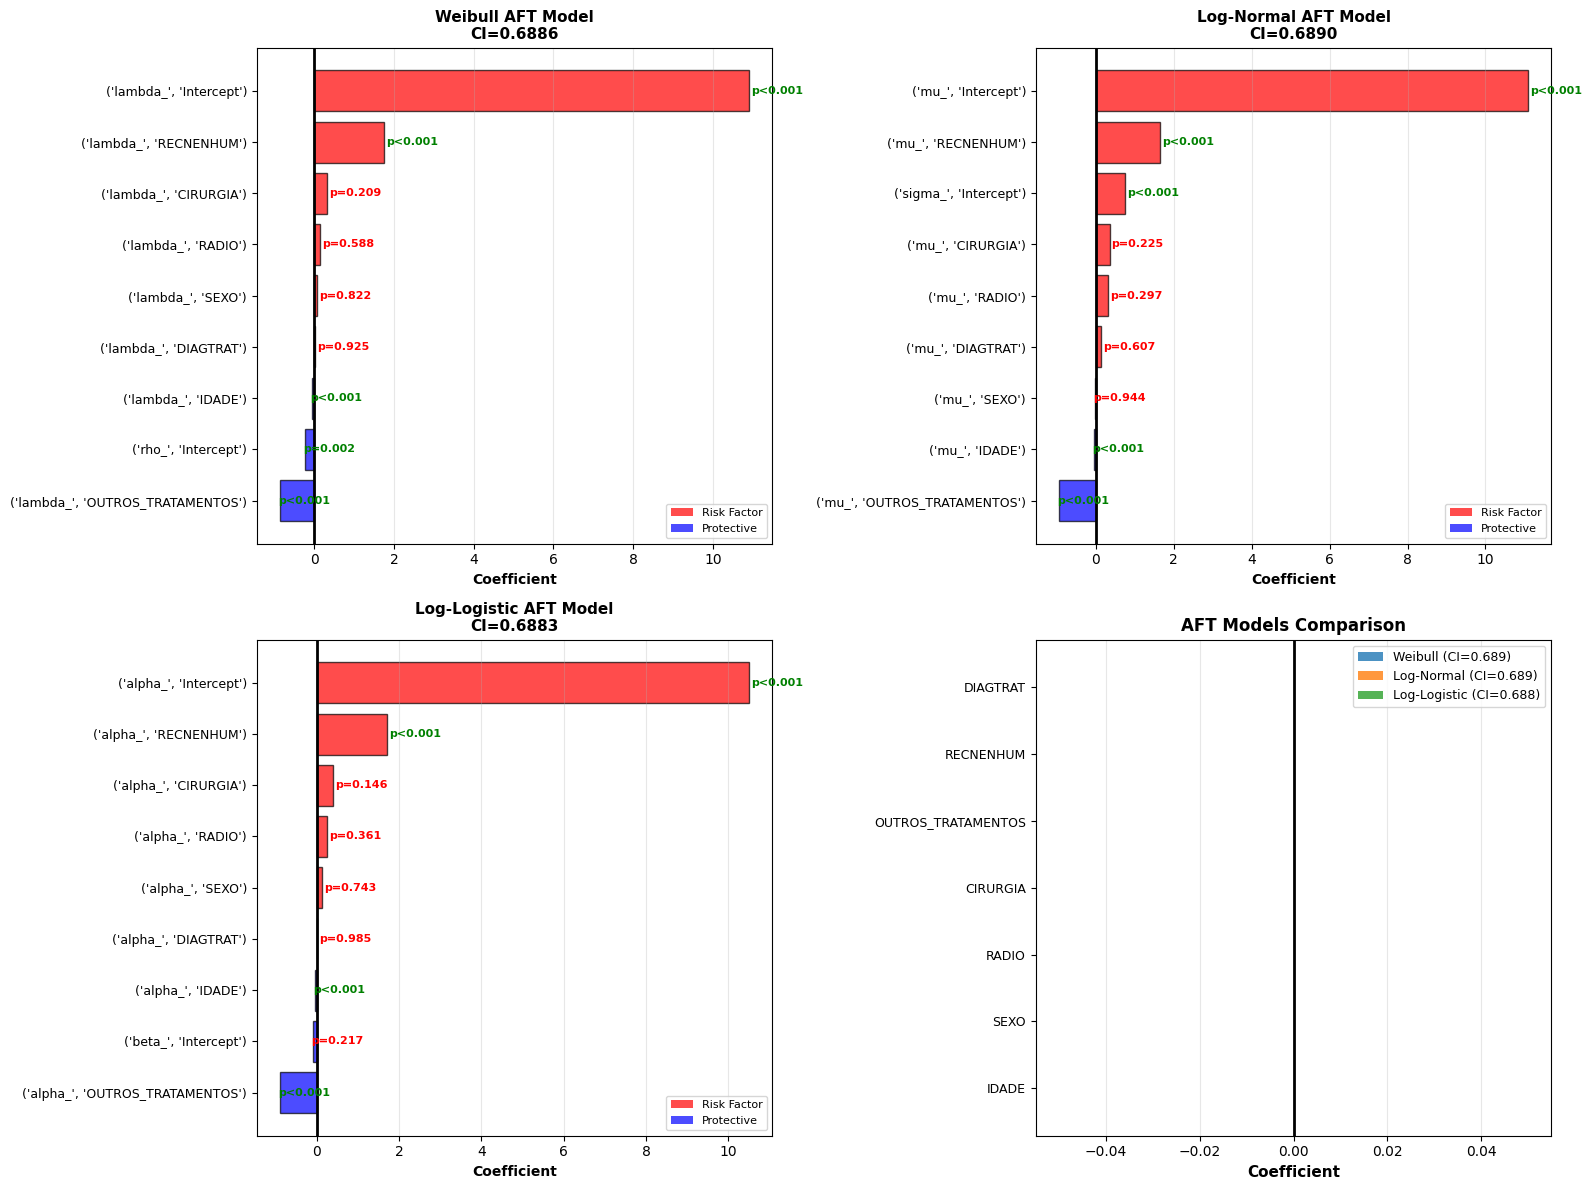


=== AFT MODELS SUMMARY ===
Weibull AFT CI: 0.6886
Log-Normal AFT CI: 0.6890
Log-Logistic AFT CI: 0.6883

Best AFT Model: Log-Normal (CI=0.6890)

=== COEFFICIENTS COMPARISON ===
                    Weibull_Coef  LogNormal_Coef  LogLogistic_Coef
IDADE                        NaN             NaN               NaN
SEXO                         NaN             NaN               NaN
RADIO                        NaN             NaN               NaN
CIRURGIA                     NaN             NaN               NaN
OUTROS_TRATAMENTOS           NaN             NaN               NaN
RECNENHUM                    NaN             NaN               NaN
DIAGTRAT                     NaN             NaN               NaN


In [20]:
# Accelerated Failure Time (AFT) Models
# Parametric models that directly model survival time (alternative to Cox)

print("\n=== ACCELERATED FAILURE TIME (AFT) MODELS ===")

try:
    from lifelines import WeibullAFTFitter, LogNormalAFTFitter, LogLogisticAFTFitter
    
    # Prepare data for AFT models (same format as Cox)
    # df_model_dummy should already be defined from previous cells
    
    # ----------------------
    # WEIBULL AFT MODEL
    # ----------------------
    print("\n=== WEIBULL AFT MODEL ===")
    aft_weibull = WeibullAFTFitter()
    aft_weibull.fit(df_model_dummy, duration_col="FOLLOW_DAYS", event_col="ULTINFO_TREAT")
    
    print("Weibull AFT Model Results:")
    aft_weibull.print_summary()
    
    ci_weibull = aft_weibull.concordance_index_
    print(f"\nWeibull AFT - Concordance Index: {ci_weibull:.4f}")
    
    # ----------------------
    # LOG-NORMAL AFT MODEL
    # ----------------------
    print("\n=== LOG-NORMAL AFT MODEL ===")
    aft_lognormal = LogNormalAFTFitter()
    aft_lognormal.fit(df_model_dummy, duration_col="FOLLOW_DAYS", event_col="ULTINFO_TREAT")
    
    print("Log-Normal AFT Model Results:")
    aft_lognormal.print_summary()
    
    ci_lognormal = aft_lognormal.concordance_index_
    print(f"\nLog-Normal AFT - Concordance Index: {ci_lognormal:.4f}")
    
    # ----------------------
    # LOG-LOGISTIC AFT MODEL
    # ----------------------
    print("\n=== LOG-LOGISTIC AFT MODEL ===")
    aft_loglogistic = LogLogisticAFTFitter()
    aft_loglogistic.fit(df_model_dummy, duration_col="FOLLOW_DAYS", event_col="ULTINFO_TREAT")
    
    print("Log-Logistic AFT Model Results:")
    aft_loglogistic.print_summary()
    
    ci_loglogistic = aft_loglogistic.concordance_index_
    print(f"\nLog-Logistic AFT - Concordance Index: {ci_loglogistic:.4f}")
    
    # ----------------------
    # COMPARISON PLOT
    # ----------------------
    print("\n=== AFT MODELS COMPARISON ===")
    
    # Get coefficients from all AFT models
    aft_comparison = pd.DataFrame(index=variables)
    
    for var in variables:
        if var in aft_weibull.summary.index:
            aft_comparison.loc[var, 'Weibull_Coef'] = aft_weibull.summary.loc[var, 'coef']
            aft_comparison.loc[var, 'Weibull_P'] = aft_weibull.summary.loc[var, 'p']
        else:
            aft_comparison.loc[var, 'Weibull_Coef'] = np.nan
            aft_comparison.loc[var, 'Weibull_P'] = np.nan
        
        if var in aft_lognormal.summary.index:
            aft_comparison.loc[var, 'LogNormal_Coef'] = aft_lognormal.summary.loc[var, 'coef']
            aft_comparison.loc[var, 'LogNormal_P'] = aft_lognormal.summary.loc[var, 'p']
        else:
            aft_comparison.loc[var, 'LogNormal_Coef'] = np.nan
            aft_comparison.loc[var, 'LogNormal_P'] = np.nan
        
        if var in aft_loglogistic.summary.index:
            aft_comparison.loc[var, 'LogLogistic_Coef'] = aft_loglogistic.summary.loc[var, 'coef']
            aft_comparison.loc[var, 'LogLogistic_P'] = aft_loglogistic.summary.loc[var, 'p']
        else:
            aft_comparison.loc[var, 'LogLogistic_Coef'] = np.nan
            aft_comparison.loc[var, 'LogLogistic_P'] = np.nan
    
    # Plot coefficients comparison
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Helper function to plot AFT coefficients
    def plot_aft_coefs(model, ax, title, ci_value):
        if model is None or len(model.summary) == 0:
            ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(title)
            return
        
        summary = model.summary.sort_values('coef', ascending=True)
        y_pos = np.arange(len(summary))
        
        colors = ['red' if coef > 0 else 'blue' for coef in summary['coef']]
        bars = ax.barh(y_pos, summary['coef'], color=colors, alpha=0.7, edgecolor='black')
        
        # Add p-value annotations
        for i, (idx, row) in enumerate(summary.iterrows()):
            p_val = row['p']
            coef = row['coef']
            x_pos = coef + (0.05 if coef >= 0 else -0.05)
            
            if p_val < 0.001:
                p_text = 'p<0.001'
            else:
                p_text = f'p={p_val:.3f}'
            
            color = 'green' if p_val < 0.05 else 'red'
            ax.text(x_pos, i, p_text, va='center', fontsize=8, color=color, fontweight='bold')
        
        ax.axvline(x=0, color='black', linestyle='-', linewidth=2)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(summary.index, fontsize=9)
        ax.set_xlabel('Coefficient', fontsize=10, fontweight='bold')
        ax.set_title(f"{title}\nCI={ci_value:.4f}", fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='x')
        
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='red', alpha=0.7, label='Risk Factor'),
            Patch(facecolor='blue', alpha=0.7, label='Protective')
        ]
        ax.legend(handles=legend_elements, loc='best', fontsize=8)
    
    # Plot each AFT model
    plot_aft_coefs(aft_weibull, axes[0, 0], "Weibull AFT Model", ci_weibull)
    plot_aft_coefs(aft_lognormal, axes[0, 1], "Log-Normal AFT Model", ci_lognormal)
    plot_aft_coefs(aft_loglogistic, axes[1, 0], "Log-Logistic AFT Model", ci_loglogistic)
    
    # Combined comparison
    ax_combined = axes[1, 1]
    y_pos = np.arange(len(variables))
    width = 0.25
    
    sorted_idx = aft_comparison.sort_values('Weibull_Coef', ascending=True).index
    aft_sorted = aft_comparison.loc[sorted_idx]
    
    bars1 = ax_combined.barh(y_pos - width, aft_sorted['Weibull_Coef'].fillna(0), width,
                             label=f'Weibull (CI={ci_weibull:.3f})', alpha=0.8, color='#1f77b4')
    bars2 = ax_combined.barh(y_pos, aft_sorted['LogNormal_Coef'].fillna(0), width,
                             label=f'Log-Normal (CI={ci_lognormal:.3f})', alpha=0.8, color='#ff7f0e')
    bars3 = ax_combined.barh(y_pos + width, aft_sorted['LogLogistic_Coef'].fillna(0), width,
                             label=f'Log-Logistic (CI={ci_loglogistic:.3f})', alpha=0.8, color='#2ca02c')
    
    ax_combined.axvline(x=0, color='black', linestyle='-', linewidth=2)
    ax_combined.set_yticks(y_pos)
    ax_combined.set_yticklabels(sorted_idx, fontsize=9)
    ax_combined.set_xlabel('Coefficient', fontsize=11, fontweight='bold')
    ax_combined.set_title('AFT Models Comparison', fontsize=12, fontweight='bold')
    ax_combined.legend(loc='best', fontsize=9)
    ax_combined.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
    
    # Summary
    print("\n=== AFT MODELS SUMMARY ===")
    print(f"Weibull AFT CI: {ci_weibull:.4f}")
    print(f"Log-Normal AFT CI: {ci_lognormal:.4f}")
    print(f"Log-Logistic AFT CI: {ci_loglogistic:.4f}")
    
    best_aft_ci = max(ci_weibull, ci_lognormal, ci_loglogistic)
    best_aft = 'Weibull' if ci_weibull == best_aft_ci else 'Log-Normal' if ci_lognormal == best_aft_ci else 'Log-Logistic'
    print(f"\nBest AFT Model: {best_aft} (CI={best_aft_ci:.4f})")
    
    print("\n=== COEFFICIENTS COMPARISON ===")
    print(aft_comparison[['Weibull_Coef', 'LogNormal_Coef', 'LogLogistic_Coef']].round(4))
    
except ImportError as e:
    print(f"AFT models not available: {e}")
    print("Make sure lifelines is installed: pip install lifelines")
except Exception as e:
    print(f"Error running AFT models: {e}")
    import traceback
    traceback.print_exc()


### DeepSurv - Neural Network Survival Model



=== DEEPSURV - NEURAL NETWORK SURVIVAL MODEL ===
Using device: cpu

=== STANDARD DEEPSURV (All Variables) ===
Training DeepSurv model...
Architecture: 7 -> 32 -> 32 -> 1
Epochs: 1000, Batch size: 256, Learning rate: 0.01

Standard DeepSurv - Concordance Index: 0.5858
Standard DeepSurv - Variables: 7

Calculating feature importance...

Top 5 Most Important Variables (DeepSurv):
             Variable  Importance
0               IDADE    0.334471
4  OUTROS_TRATAMENTOS    0.145614
6            DIAGTRAT    0.119463
5           RECNENHUM    0.118513
3            CIRURGIA    0.107550

=== REDUCED DEEPSURV (Top 5 Variables) ===
Using top 5 variables: ['IDADE', 'OUTROS_TRATAMENTOS', 'DIAGTRAT', 'RECNENHUM', 'CIRURGIA']
Reduced DeepSurv - Concordance Index: 0.5498

=== DEEPSURV RISK DIRECTION ANALYSIS ===


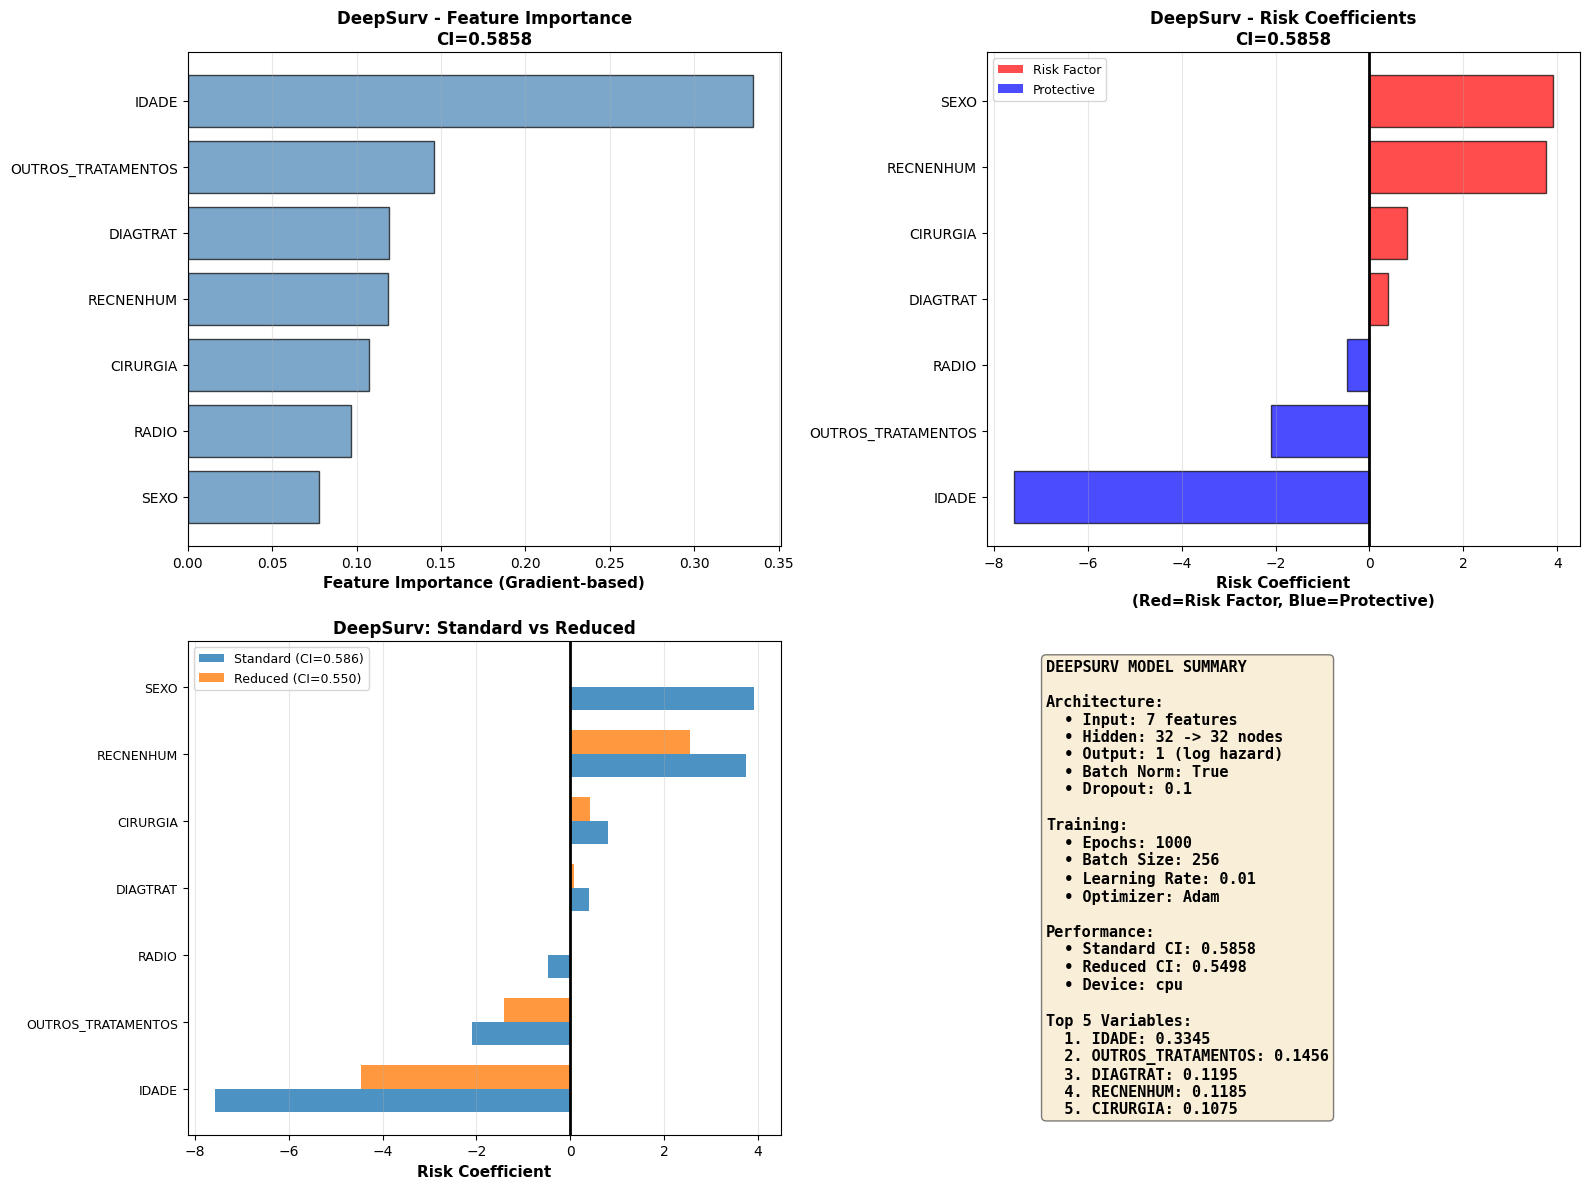


=== ALL MODELS COMPARISON (Including DeepSurv) ===
Standard RSF CI: 0.7275
Alternative RSF CI: 0.7557
Reduced RSF CI: 0.7347
DeepSurv CI: 0.5858
Reduced DeepSurv CI: 0.5498
Survival SVM CI: 0.6896
Reduced Survival SVM CI: 0.6265
Gradient Boosting CI: 0.7626
Reduced Gradient Boosting CI: 0.7561
Weibull AFT CI: 0.6886
Log-Normal AFT CI: 0.6890
Log-Logistic AFT CI: 0.6883

=== DEEPSURV SUMMARY ===
Standard Model CI: 0.5858
Reduced Model CI: 0.5498

=== RISK COEFFICIENTS COMPARISON ===
                    DeepSurv_Risk  DeepSurv_Importance
IDADE                     -7.5783               0.3345
SEXO                       3.9101               0.0779
RADIO                     -0.4729               0.0965
CIRURGIA                   0.7967               0.1075
OUTROS_TRATAMENTOS        -2.1012               0.1456
RECNENHUM                  3.7523               0.1185
DIAGTRAT                   0.3977               0.1195

=== TOP 5 VARIABLES (by importance) ===
             Variable  Importan

In [31]:
# DeepSurv - Neural Network Survival Model
# Deep learning approach to survival analysis (similar to Cox but with neural networks)

print("\n=== DEEPSURV - NEURAL NETWORK SURVIVAL MODEL ===")

try:
    import torch
    import torch.nn as nn
    from pycox.models import CoxPH
    from pycox.evaluation import EvalSurv
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import train_test_split
    
    # Check if CUDA is available
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Prepare data for DeepSurv
    X_deep = X.astype(float).values
    # y is a structured numpy array, so accessing fields already returns numpy arrays
    y_time = y["FOLLOW_DAYS"].astype(float)
    y_event = y["ULTINFO_TREAT"].astype(float)
    
    # Split data
    X_train, X_val, y_time_train, y_time_val, y_event_train, y_event_val = train_test_split(
        X_deep, y_time, y_event, test_size=0.2, random_state=42
    )
    
    # Normalize features (important for neural networks)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    # Convert to tensors
    X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
    X_val_tensor = torch.FloatTensor(X_val_scaled).to(device)
    y_time_train_tensor = torch.FloatTensor(y_time_train).to(device)
    y_event_train_tensor = torch.FloatTensor(y_event_train).to(device)
    
    print("\n=== STANDARD DEEPSURV (All Variables) ===")
    
    # Define network architecture
    in_features = X_train_scaled.shape[1]
    num_nodes = [32, 32]  # Two hidden layers
    out_features = 1
    batch_norm = True
    dropout = 0.1
    
    # Create neural network
    net = nn.Sequential(
        nn.Linear(in_features, num_nodes[0]),
        nn.BatchNorm1d(num_nodes[0]) if batch_norm else nn.Identity(),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(num_nodes[0], num_nodes[1]),
        nn.BatchNorm1d(num_nodes[1]) if batch_norm else nn.Identity(),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(num_nodes[1], out_features)
    ).to(device)
    
    # Create CoxPH model (DeepSurv)
    model_deep = CoxPH(net, optimizer=torch.optim.Adam)
    
    # Training parameters
    batch_size = 256
    epochs = 1000
    lr = 0.01
    
    print(f"Training DeepSurv model...")
    print(f"Architecture: {in_features} -> {num_nodes[0]} -> {num_nodes[1]} -> {out_features}")
    print(f"Epochs: {epochs}, Batch size: {batch_size}, Learning rate: {lr}")
    
    # Train the model
    model_deep.optimizer.set_lr(lr)
    model_deep.fit(X_train_tensor, (y_time_train_tensor, y_event_train_tensor), 
                   batch_size=batch_size, epochs=epochs, verbose=False)
    
    # Make predictions
    model_deep.compute_baseline_hazards()
    surv_deep = model_deep.predict_surv_df(X_val_tensor)
    
    # Calculate concordance index
    ev = EvalSurv(surv_deep, y_time_val, y_event_val, censor_surv='km')
    ci_deep = ev.concordance_td()
    
    print(f"\nStandard DeepSurv - Concordance Index: {ci_deep:.4f}")
    print(f"Standard DeepSurv - Variables: {len(variables)}")
    
    # Get feature importance (using gradient-based importance)
    print("\nCalculating feature importance...")
    X_all_scaled = scaler.transform(X_deep)
    X_all_tensor = torch.FloatTensor(X_all_scaled).to(device)
    X_all_tensor.requires_grad_(True)
    pred = model_deep.net(X_all_tensor)
    
    # Calculate gradients for feature importance
    grad_importance = torch.zeros(in_features).to(device)
    for i in range(in_features):
        grad = torch.autograd.grad(pred.sum(), X_all_tensor, retain_graph=True, create_graph=False)[0]
        grad_importance[i] = grad[:, i].abs().mean()
    
    # Normalize importance
    grad_importance_norm = grad_importance / grad_importance.sum()
    
    importance_df_deep = pd.DataFrame({
        'Variable': X.columns,
        'Importance': grad_importance_norm.cpu().numpy()
    }).sort_values('Importance', ascending=False)
    
    print("\nTop 5 Most Important Variables (DeepSurv):")
    print(importance_df_deep.head(5))
    
    # ----------------------
    # REDUCED DEEPSURV MODEL
    # ----------------------
    print("\n=== REDUCED DEEPSURV (Top 5 Variables) ===")
    top5_vars_deep = importance_df_deep.head(5)['Variable'].tolist()
    print(f"Using top 5 variables: {top5_vars_deep}")
    
    X_reduced_deep = df_model_dummy[top5_vars_deep].astype(float).values
    # y is a structured numpy array, so accessing fields already returns numpy arrays
    y_reduced_time = y["FOLLOW_DAYS"].astype(float)
    y_reduced_event = y["ULTINFO_TREAT"].astype(float)
    
    X_reduced_train, X_reduced_val, y_rt_train, y_rt_val, y_re_train, y_re_val = train_test_split(
        X_reduced_deep, y_reduced_time, y_reduced_event, test_size=0.2, random_state=42
    )
    
    scaler_reduced = StandardScaler()
    X_reduced_train_scaled = scaler_reduced.fit_transform(X_reduced_train)
    X_reduced_val_scaled = scaler_reduced.transform(X_reduced_val)
    
    X_reduced_train_tensor = torch.FloatTensor(X_reduced_train_scaled).to(device)
    X_reduced_val_tensor = torch.FloatTensor(X_reduced_val_scaled).to(device)
    y_rt_train_tensor = torch.FloatTensor(y_rt_train).to(device)
    y_re_train_tensor = torch.FloatTensor(y_re_train).to(device)
    
    # Create reduced network
    in_features_reduced = X_reduced_train_scaled.shape[1]
    net_reduced = nn.Sequential(
        nn.Linear(in_features_reduced, 16),
        nn.BatchNorm1d(16) if batch_norm else nn.Identity(),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(16, 8),
        nn.BatchNorm1d(8) if batch_norm else nn.Identity(),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(8, 1)
    ).to(device)
    
    model_deep_reduced = CoxPH(net_reduced, optimizer=torch.optim.Adam)
    model_deep_reduced.optimizer.set_lr(lr)
    model_deep_reduced.fit(X_reduced_train_tensor, (y_rt_train_tensor, y_re_train_tensor),
                          batch_size=batch_size, epochs=epochs, verbose=False)
    
    model_deep_reduced.compute_baseline_hazards()
    surv_deep_reduced = model_deep_reduced.predict_surv_df(X_reduced_val_tensor)
    
    ev_reduced = EvalSurv(surv_deep_reduced, y_rt_val, y_re_val, censor_surv='km')
    ci_deep_reduced = ev_reduced.concordance_td()
    
    print(f"Reduced DeepSurv - Concordance Index: {ci_deep_reduced:.4f}")
    
    # ----------------------
    # RISK DIRECTION ANALYSIS
    # ----------------------
    print("\n=== DEEPSURV RISK DIRECTION ANALYSIS ===")
    
    def calculate_deep_risk_direction(model, scaler, X_original, variables):
        """Calculate risk direction for DeepSurv model"""
        X_scaled = scaler.transform(X_original.astype(float))
        X_tensor = torch.FloatTensor(X_scaled).to(device)
        
        # Get risk scores (negative log hazard)
        with torch.no_grad():
            risk_scores = -model.net(X_tensor).cpu().numpy().flatten()
        
        risk_directions = {}
        X_df = pd.DataFrame(X_original, columns=variables)
        
        for var in variables:
            if var in X_df.columns:
                if X_df[var].nunique() <= 2:
                    if X_df[var].nunique() == 2:
                        high_risk = risk_scores[X_df[var] == X_df[var].max()].mean()
                        low_risk = risk_scores[X_df[var] == X_df[var].min()].mean()
                        risk_directions[var] = high_risk - low_risk
                    else:
                        risk_directions[var] = 0
                else:
                    q75 = X_df[var].quantile(0.75)
                    q25 = X_df[var].quantile(0.25)
                    if q75 > q25:
                        high_risk = risk_scores[X_df[var] >= q75].mean()
                        low_risk = risk_scores[X_df[var] <= q25].mean()
                        risk_directions[var] = high_risk - low_risk
                    else:
                        risk_directions[var] = 0
        
        return risk_directions
    
    risk_dir_deep = calculate_deep_risk_direction(model_deep, scaler, X_deep, variables)
    risk_dir_deep_reduced = calculate_deep_risk_direction(model_deep_reduced, scaler_reduced, X_reduced_deep, top5_vars_deep)
    
    # Create comparison dataframe
    deep_comparison = pd.DataFrame(index=variables)
    deep_comparison['DeepSurv_Risk'] = [risk_dir_deep.get(var, 0) for var in variables]
    deep_comparison['DeepSurv_Reduced_Risk'] = [risk_dir_deep_reduced.get(var, 0) if var in top5_vars_deep else 0 for var in variables]
    deep_comparison['DeepSurv_Importance'] = [grad_importance_norm.cpu().numpy()[list(X.columns).index(var)] if var in X.columns else 0 for var in variables]
    
    # ----------------------
    # PLOT COMPARISON
    # ----------------------
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Feature Importance
    ax1 = axes[0, 0]
    sorted_idx = deep_comparison.sort_values('DeepSurv_Importance', ascending=True).index
    y_pos = np.arange(len(variables))
    
    bars = ax1.barh(y_pos, deep_comparison.loc[sorted_idx, 'DeepSurv_Importance'], 
                   color='steelblue', alpha=0.7, edgecolor='black')
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(sorted_idx, fontsize=10)
    ax1.set_xlabel('Feature Importance (Gradient-based)', fontsize=11, fontweight='bold')
    ax1.set_title(f'DeepSurv - Feature Importance\nCI={ci_deep:.4f}', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='x')
    
    # Plot 2: Risk Coefficients (Cox-style)
    ax2 = axes[0, 1]
    sorted_risk = deep_comparison.sort_values('DeepSurv_Risk', ascending=True).index
    y_pos2 = np.arange(len(variables))
    
    colors2 = ['red' if coef > 0 else 'blue' for coef in deep_comparison.loc[sorted_risk, 'DeepSurv_Risk']]
    bars2 = ax2.barh(y_pos2, deep_comparison.loc[sorted_risk, 'DeepSurv_Risk'], 
                    color=colors2, alpha=0.7, edgecolor='black')
    
    ax2.axvline(x=0, color='black', linestyle='-', linewidth=2)
    ax2.set_yticks(y_pos2)
    ax2.set_yticklabels(sorted_risk, fontsize=10)
    ax2.set_xlabel('Risk Coefficient\n(Red=Risk Factor, Blue=Protective)', fontsize=11, fontweight='bold')
    ax2.set_title(f'DeepSurv - Risk Coefficients\nCI={ci_deep:.4f}', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='x')
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='red', alpha=0.7, label='Risk Factor'),
        Patch(facecolor='blue', alpha=0.7, label='Protective')
    ]
    ax2.legend(handles=legend_elements, loc='best', fontsize=9)
    
    # Plot 3: Standard vs Reduced Risk Comparison
    ax3 = axes[1, 0]
    y_pos3 = np.arange(len(variables))
    width = 0.35
    
    sorted_combined = deep_comparison.sort_values('DeepSurv_Risk', ascending=True).index
    deep_sorted = deep_comparison.loc[sorted_combined]
    
    bars3a = ax3.barh(y_pos3 - width/2, deep_sorted['DeepSurv_Risk'], width,
                     label=f'Standard (CI={ci_deep:.3f})', alpha=0.8, color='#1f77b4')
    bars3b = ax3.barh(y_pos3 + width/2, deep_sorted['DeepSurv_Reduced_Risk'], width,
                     label=f'Reduced (CI={ci_deep_reduced:.3f})', alpha=0.8, color='#ff7f0e')
    
    ax3.axvline(x=0, color='black', linestyle='-', linewidth=2)
    ax3.set_yticks(y_pos3)
    ax3.set_yticklabels(sorted_combined, fontsize=9)
    ax3.set_xlabel('Risk Coefficient', fontsize=11, fontweight='bold')
    ax3.set_title('DeepSurv: Standard vs Reduced', fontsize=12, fontweight='bold')
    ax3.legend(loc='best', fontsize=9)
    ax3.grid(True, alpha=0.3, axis='x')
    
    # Plot 4: Model Architecture Summary
    ax4 = axes[1, 1]
    ax4.axis('off')
    
    summary_text = f"""DEEPSURV MODEL SUMMARY

Architecture:
  • Input: {in_features} features
  • Hidden: {num_nodes[0]} -> {num_nodes[1]} nodes
  • Output: 1 (log hazard)
  • Batch Norm: {batch_norm}
  • Dropout: {dropout}

Training:
  • Epochs: {epochs}
  • Batch Size: {batch_size}
  • Learning Rate: {lr}
  • Optimizer: Adam

Performance:
  • Standard CI: {ci_deep:.4f}
  • Reduced CI: {ci_deep_reduced:.4f}
  • Device: {device}

Top 5 Variables:"""
    for i, (idx, row) in enumerate(importance_df_deep.head(5).iterrows(), 1):
        summary_text += f"\n  {i}. {row['Variable']}: {row['Importance']:.4f}"
    
    ax4.text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
            verticalalignment='center', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    # ----------------------
    # MODEL COMPARISON SUMMARY
    # ----------------------
    print("\n=== ALL MODELS COMPARISON (Including DeepSurv) ===")
    print(f"Standard RSF CI: {ci_standard:.4f}")
    print(f"Alternative RSF CI: {ci_alt:.4f}")
    print(f"Reduced RSF CI: {ci_reduced:.4f}")
    print(f"DeepSurv CI: {ci_deep:.4f}")
    print(f"Reduced DeepSurv CI: {ci_deep_reduced:.4f}")
    
    # Try to include other models if available
    try:
        print(f"Survival SVM CI: {ci_svm_standard:.4f}")
        print(f"Reduced Survival SVM CI: {ci_svm_reduced:.4f}")
    except:
        pass
    
    try:
        print(f"Gradient Boosting CI: {ci_gbs:.4f}")
        print(f"Reduced Gradient Boosting CI: {ci_gbs_reduced:.4f}")
    except:
        pass
    
    try:
        print(f"Weibull AFT CI: {ci_weibull:.4f}")
        print(f"Log-Normal AFT CI: {ci_lognormal:.4f}")
        print(f"Log-Logistic AFT CI: {ci_loglogistic:.4f}")
    except:
        pass
    
    print("\n=== DEEPSURV SUMMARY ===")
    print(f"Standard Model CI: {ci_deep:.4f}")
    print(f"Reduced Model CI: {ci_deep_reduced:.4f}")
    
    print("\n=== RISK COEFFICIENTS COMPARISON ===")
    print(deep_comparison[['DeepSurv_Risk', 'DeepSurv_Importance']].round(4))
    
    print("\n=== TOP 5 VARIABLES (by importance) ===")
    print(importance_df_deep.head(5))
    
except ImportError as e:
    print(f"DeepSurv dependencies not available: {e}")
    print("\nTo install required packages:")
    print("  pip install torch")
    print("  pip install pycox")
    print("\nNote: This may take a few minutes to install.")
except Exception as e:
    print(f"Error running DeepSurv: {e}")
    import traceback
    traceback.print_exc()
